In [178]:
library(ggplot2)
library(gridExtra)
library(plotly)
library(reshape2)
library(tidyverse)
library(FactoMineR) 
library(factoextra)
library(corrplot)
library(fastDummies)
library(dplyr)
library(stringr)
library(mclust)

Warning message:
"le package 'mclust' a été compilé avec la version R 4.5.3"
Package 'mclust' version 6.1.2
Type 'citation("mclust")' for citing this R package in publications.


Attachement du package : 'mclust'


L'objet suivant est masqué depuis 'package:dplyr':

    count


L'objet suivant est masqué depuis 'package:purrr':

    map




In [2]:
data<-read.csv("new_games.csv",header = TRUE)

In [3]:
summary(data)

     AppID             Name           Release.date       Estimated.owners  
 Min.   :     10   Length:122611      Length:122611      Length:122611     
 1st Qu.:1063175   Class :character   Class :character   Class :character  
 Median :1907380   Mode  :character   Mode  :character   Mode  :character  
 Mean   :1985386                                                           
 3rd Qu.:2869560                                                           
 Max.   :4264350                                                           
                                                                           
    Peak.CCU          Required.age         Price             Discount     
 Min.   :0.000e+00   Min.   : 0.0000   Min.   :   0.000   Min.   :  0.00  
 1st Qu.:0.000e+00   1st Qu.: 0.0000   1st Qu.:   0.550   1st Qu.:  0.00  
 Median :0.000e+00   Median : 0.0000   Median :   2.240   Median :  0.00  
 Mean   :5.459e+01   Mean   : 0.1676   Mean   :   4.765   Mean   : 18.35  
 3rd Qu.:0.000e+0

# Conversion des variables lues en tant que quantitatives en qualitatives

In [4]:
data[,"Estimated.owners"]=as.factor(data[,"Estimated.owners"])
data[,"Required.age"]=as.factor(data[,"Required.age"])
data[,"Windows"]=as.factor(data[,"Windows"])
data[,"Mac"]=as.factor(data[,"Mac"])
data[,"Linux"]=as.factor(data[,"Linux"])


summary(data)

     AppID             Name           Release.date      
 Min.   :     10   Length:122611      Length:122611     
 1st Qu.:1063175   Class :character   Class :character  
 Median :1907380   Mode  :character   Mode  :character  
 Mean   :1985386                                        
 3rd Qu.:2869560                                        
 Max.   :4264350                                        
                                                        
        Estimated.owners    Peak.CCU          Required.age   
 0 - 20000      :75404   Min.   :0.000e+00   0      :121339  
 0 - 0          :21641   1st Qu.:0.000e+00   17     :   828  
 20000 - 50000  :11396   Median :0.000e+00   13     :   175  
 50000 - 100000 : 5355   Mean   :5.459e+01   18     :   164  
 100000 - 200000: 3454   3rd Qu.:0.000e+00   16     :    32  
 200000 - 500000: 2853   Max.   :1.014e+06   10     :    26  
 (Other)        : 2508                       (Other):    47  
     Price             Discount        DLC.count

In [5]:
genres_uniques <- data$Genres %>%
  str_split(",") %>%          # Sépare les chaînes au niveau des virgules
  unlist() %>%                # Transforme la liste de listes en un seul vecteur
  str_trim() %>%              # Enlève les espaces inutiles (ex: " Indie" -> "Indie")
  unique()                    # Garde chaque genre une seule fois

# 2. Afficher le nombre total
length(genres_uniques)

# 3. Afficher la liste pour vérifier
print(genres_uniques)

[1] 34

 [1] ""                      "Adventure"             "Casual"               
 [4] "Indie"                 "Simulation"            "Action"               
 [7] "Early Access"          "Strategy"              "RPG"                  
[10] "Racing"                "Free To Play"          "Sports"               
[13] "Audio Production"      "Massively Multiplayer" "Animation & Modeling" 
[16] "Video Production"      "Violent"               "Gore"                 
[19] "Sexual Content"        "Nudity"                "Education"            
[22] "Design & Illustration" "Game Development"      "Utilities"            
[25] "Web Publishing"        "Accounting"            "Photo Editing"        
[28] "Software Training"     "Movie"                 "Documentary"          
[31] "Episodic"              "Short"                 "Tutorial"             
[34] "360 Video"            


In [6]:
categories_uniques <- data$Categories %>%
  str_split(",") %>%          # Sépare les chaînes au niveau des virgules
  unlist() %>%                # Transforme la liste de listes en un seul vecteur
  str_trim() %>%              # Enlève les espaces inutiles (ex: " Indie" -> "Indie")
  unique()                    # Garde chaque genre une seule fois

# 2. Afficher le nombre total
length(categories_uniques)

# 3. Afficher la liste pour vérifier
print(categories_uniques)

[1] 59

 [1] ""                             "Single-player"               
 [3] "Steam Trading Cards"          "Steam Cloud"                 
 [5] "Family Sharing"               "Steam Achievements"          
 [7] "VR Only"                      "Steam Leaderboards"          
 [9] "Tracked Controller Support"   "Steam Workshop"              
[11] "Full controller support"      "Steam Timeline"              
[13] "Multi-player"                 "PvP"                         
[15] "Online PvP"                   "Includes level editor"       
[17] "Partial Controller Support"   "Remote Play Together"        
[19] "Shared/Split Screen PvP"      "Co-op"                       
[21] "Shared/Split Screen Co-op"    "Shared/Split Screen"         
[23] "Online Co-op"                 "Cross-Platform Multiplayer"  
[25] "Remote Play on TV"            "In-App Purchases"            
[27] "Stats"                        "Custom Volume Controls"      
[29] "Adjustable Difficulty"        "Keyboard Only Option"    

In [7]:
tags_uniques <- data$Tags %>%
  str_split(",") %>%          # Sépare les chaînes au niveau des virgules
  unlist() %>%                # Transforme la liste de listes en un seul vecteur
  str_trim() %>%              # Enlève les espaces inutiles (ex: " Indie" -> "Indie")
  unique()                    # Garde chaque genre une seule fois

# 2. Afficher le nombre total
length(tags_uniques)

# 3. Afficher la liste pour vérifier
print(tags_uniques)

[1] 453

  [1] ""                                  "Adventure"                        
  [3] "Visual Novel"                      "Anime"                            
  [5] "Cute"                              "Casual"                           
  [7] "Card Game"                         "Solitaire"                        
  [9] "Puzzle"                            "Hidden Object"                    
 [11] "2D"                                "Colorful"                         
 [13] "Stylized"                          "Logic"                            
 [15] "Mystery"                           "Atmospheric"                      
 [17] "Family Friendly"                   "PvE"                              
 [19] "Tutorial"                          "Singleplayer"                     
 [21] "Tabletop"                          "Simulation"                       
 [23] "Strategy"                          "RTS"                              
 [25] "Wargame"                           "Grand Strategy"      

#  Suppresion de variables inutiles à l'exploration des données

In [8]:
data1 <- data %>% select(-c(AppID, About.the.game, Reviews,Movies,Header.image,Support.email,Support.url,Notes,Metacritic.url,Screenshots,Score.rank,Website))

In [9]:
head(data1)

,Name,Release.date,Estimated.owners,Peak.CCU,Required.age,Price,Discount,DLC.count,Supported.languages,Full.audio.languages,⋯,Recommendations,Average.playtime.forever,Average.playtime.two.weeks,Median.playtime.forever,Median.playtime.two.weeks,Developers,Publishers,Categories,Genres,Tags
,<chr>,<chr>,<fct>,<int>,<fct>,<dbl>,<int>,<int>,<chr>,<chr>,⋯,<int>,<int>,<int>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>
1,Black Dragon Mage Playtest,"Aug 1, 2023",0 - 0,0,0,0.00,0,0,[],[],⋯,0,0,0,0,0,,,,,
2,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0 - 20000,0,0,5.24,65,0,['English'],[],⋯,231,8,0,8,0,minori,MangaGamer,"Single-player,Steam Trading Cards,Steam Cloud,Family Sharing",Adventure,"Adventure,Visual Novel,Anime,Cute"
3,Mystery Solitaire The Black Raven,"May 6, 2019",0 - 20000,0,0,4.99,0,0,"['English', 'French', 'German', 'Russian']",[],⋯,0,0,0,0,0,Somer Games,8floor,"Single-player,Family Sharing",Casual,"Casual,Card Game,Solitaire,Puzzle,Hidden Object,2D,Colorful,Stylized,Logic,Mystery,Atmospheric,Family Friendly,PvE,Tutorial,Singleplayer,Tabletop"
4,버튜버 파라노이아 - Vtuber Paranoia,"Oct 31, 2024",0 - 20000,1,0,8.99,0,1,['Korean'],['Korean'],⋯,0,0,0,0,0,유진게임즈,유진게임즈,"Single-player,Steam Achievements,Family Sharing","Casual,Indie,Simulation",
5,Maze Quest VR,"Apr 24, 2025",0 - 20000,0,0,4.99,0,0,['English'],['English'],⋯,0,0,0,0,0,Reality Expanded LLC,Reality Expanded LLC,"Single-player,VR Only,Steam Leaderboards,Family Sharing","Action,Early Access",
6,Agony VR,"Apr 5, 2023",0 - 20000,0,0,13.99,0,0,"['English', 'French', 'Italian', 'German', 'Spanish - Spain', 'Polish', 'Portuguese - Portugal', 'Russian', 'Turkish']","['English', 'Turkish']",⋯,0,0,0,0,0,Ignibit,"Ignibit,Madmind Studio","Single-player,Tracked Controller Support,VR Only,Family Sharing","Action,Adventure",


 # Analyse de la qualités des individus (les jeux vidéos): filtrage

In [10]:
dat_filtered <- data1 %>%
  mutate(
    # 1. Fusion des LANGUES (Supported + Audio)
    temp_langs = paste(Supported.languages, Full.audio.languages, sep = ","),
    Language= temp_langs %>%
      str_remove_all("[\\[\\]'\" ]") %>%
      str_replace_all("(?i)na|nan|null", "") %>%
      str_replace_all(",+", ",") %>%
      str_remove("^,") %>%
      str_remove(",$")
       ) %>%
    select(-temp_langs)

In [11]:
data2 = dat_filtered %>% select(-c(Supported.languages,Full.audio.languages))
summary(data2)

     Name           Release.date              Estimated.owners
 Length:122611      Length:122611      0 - 20000      :75404  
 Class :character   Class :character   0 - 0          :21641  
 Mode  :character   Mode  :character   20000 - 50000  :11396  
                                       50000 - 100000 : 5355  
                                       100000 - 200000: 3454  
                                       200000 - 500000: 2853  
                                       (Other)        : 2508  
    Peak.CCU          Required.age        Price             Discount     
 Min.   :0.000e+00   0      :121339   Min.   :   0.000   Min.   :  0.00  
 1st Qu.:0.000e+00   17     :   828   1st Qu.:   0.550   1st Qu.:  0.00  
 Median :0.000e+00   13     :   175   Median :   2.240   Median :  0.00  
 Mean   :5.459e+01   18     :   164   Mean   :   4.765   Mean   : 18.35  
 3rd Qu.:0.000e+00   16     :    32   3rd Qu.:   5.240   3rd Qu.: 40.00  
 Max.   :1.014e+06   10     :    26   Max.   : 999.9

In [12]:
data_filtered <- data2 %>%
  filter(
    (Tags != "" ) |
    (Genres != "" ) |
    (Categories != "" ) |
    ( Language != "" )
  )


## Traitement des doublons (jeux qui ont le même nom)

In [13]:
data3 <- data_filtered %>%
  # 1. On trie par nom, puis par Peak.CCU du plus grand au plus petit
  # Comme ça, la ligne avec le plus gros score arrive en premier pour chaque jeu
  arrange(Name, Developers, Publishers, desc(Peak.CCU)) %>%
  
  # 2. On ne garde que la première occurrence pour chaque combinaison identique
  # R va garder la 1ère ligne rencontrée (donc celle avec le CCU max grâce au tri)
  distinct(Name, Developers, Publishers, .keep_all = TRUE)

In [14]:
nbr_suppr <- nrow(data_filtered) - nrow(data3)

print(paste("Nous avons supprimé", nbr_suppr, "individus."))

[1] "Nous avons supprimé 116 individus."


# Etude sur variables

## Variables quantitatives

In [15]:
data3[, "LPositive"] <- log(data3[, "Positive"]+1)

data3[, "LNegative"] <- log(data3[, "Negative"]+1)
data3[, "LRecommendations"] <- log(data3[, "Recommendations"]+1)
data3[,"LPeak.CCU"] <- log(data3[, "Peak.CCU"]+1)
data3[,"LDLC.count"] <- log(data3[, "DLC.count"]+1)
data3[,"LPrice"] <- log(data3[, "Price"]+1)

In [16]:
#data4 <- data3 %>% select(-c(Positive,Negative,Recommendations,Peak.CCU,DLC.count))

In [17]:
data5 <- data3 %>%
  mutate(LanguageCount = case_when(
      Language == "" ~ 0, # Cas où c'est vide
    TRUE ~ str_count(Language, ",") + 1              
  ))

In [18]:
data5[, "LAverage.playtime.forever"] <- log(data5[, "Average.playtime.forever"]+1)

data5[, "LMedian.playtime.forever"] <- log(data5[, "Median.playtime.forever"]+1)
data5[,"LLanguageCount"] <- log(data5[, "LanguageCount"]+1)

In [19]:
data5 <- data5 %>% select(-c(Average.playtime.forever,Median.playtime.forever,Price,LanguageCount,Peak.CCU,Positive,Negative,Recommendations,DLC.count))
summary(data5)

     Name           Release.date              Estimated.owners  Required.age   
 Length:114513      Length:114513      0 - 20000      :75337   0      :113288  
 Class :character   Class :character   0 - 0          :13649   17     :   782  
 Mode  :character   Mode  :character   20000 - 50000  :11395   13     :   175  
                                       50000 - 100000 : 5349   18     :   164  
                                       100000 - 200000: 3450   16     :    31  
                                       200000 - 500000: 2845   10     :    26  
                                       (Other)        : 2488   (Other):    47  
    Discount       Windows          Mac          Linux       Metacritic.score
 Min.   :  0.00   False:    44   False:93260   False:98841   Min.   : 0.000  
 1st Qu.:  0.00   True :114469   True :21253   True :15672   1st Qu.: 0.000  
 Median :  0.00                                              Median : 0.000  
 Mean   : 19.62                                 

In [20]:
data_rename <- data5 %>%
  mutate(Estimated.owners = fct_recode(Estimated.owners,
    "0"           = "0 - 0",
    "0-20K"       = "0 - 20000",
    "20K-50K"     = "20000 - 50000",
    "50K-100K"    = "50000 - 100000",
    "100K-200K"   = "100000 - 200000",
    "200K-500K"   = "200000 - 500000",
    "500K-1M"     = "500000 - 1000000",
    "1M-2M"       = "1000000 - 2000000",
    "2M-5M"       = "2000000 - 5000000",
    "5M-10M"      = "5000000 - 10000000",
    "10M-20M"     = "10000000 - 20000000",
    "20M-50M"     = "20000000 - 50000000",
    "50M-100M"    = "50000000 - 100000000",
    "100M-200M"   = "100000000 - 200000000"
  ))

ordre_logique <- c(
  "0", "0-20K", "20K-50K", "50K-100K", "100K-200K", 
  "200K-500K", "500K-1M", "1M-2M", "2M-5M", "5M-10M", 
  "10M-20M", "20M-50M", "50M-100M", "100M-200M"
)

data_ready <- data_rename %>%
  mutate(Estimated.owners = fct_relevel(Estimated.owners, ordre_logique))

In [21]:
data_ready$Release.date <- sub(".*, ", "", data_ready$Release.date)
head(data_ready$Release.date)

[1] "2023" "2016" "2020" "2018" "2018" "2024"

In [22]:
data_ready$Release.date = as.factor(data_ready$Release.date)

In [23]:
#On regroupe aussi les jeux qui sont sortis en 2025 et 2026 et les jeux avant 2014
col=as.character(1997:2013)
data_ready <- data_ready %>%
  mutate(Release.date = fct_collapse(as.factor(Release.date),
    "1997-2013" =col,
    "2025-2026"= as.character(2025:2026)                                 
  ))

head(data_ready$Release.date)

[1] 2023 2016 2020 2018 2018 2024
13 Levels: 1997-2013 2014 2015 2016 2017 2018 2019 2020 2021 2022 2023 ... 2025-2026

In [24]:
summary(data_ready)

     Name              Release.date    Estimated.owners  Required.age   
 Length:114513      2025-2026:21812   0-20K    :75337   0      :113288  
 Class :character   2024     :18104   0        :13649   17     :   782  
 Mode  :character   2023     :13337   20K-50K  :11395   13     :   175  
                    2022     :11403   50K-100K : 5349   18     :   164  
                    2021     :10441   100K-200K: 3450   16     :    31  
                    2020     : 8746   200K-500K: 2845   10     :    26  
                    (Other)  :30670   (Other)  : 2488   (Other):    47  
    Discount       Windows          Mac          Linux       Metacritic.score
 Min.   :  0.00   False:    44   False:93260   False:98841   Min.   : 0.000  
 1st Qu.:  0.00   True :114469   True :21253   True :15672   1st Qu.: 0.000  
 Median :  0.00                                              Median : 0.000  
 Mean   : 19.62                                              Mean   : 2.703  
 3rd Qu.: 45.00           

# Etude des jeux avec le plus de succès : TOP 13

On commence par étudier à la main les similitudes entre les jeux les plus populaires c'est-à-dire les jeux avec le plus d'utilisateurs.

In [151]:
#Nobre de jeux par tranche d'utilisateurs
table(data_ready$Estimated.owners)


        0     0-20K   20K-50K  50K-100K 100K-200K 200K-500K   500K-1M     1M-2M 
    13649     75337     11395      5349      3450      2845      1150       720 
    2M-5M    5M-10M   10M-20M   20M-50M  50M-100M 100M-200M 
      400       124        50        31         9         4 

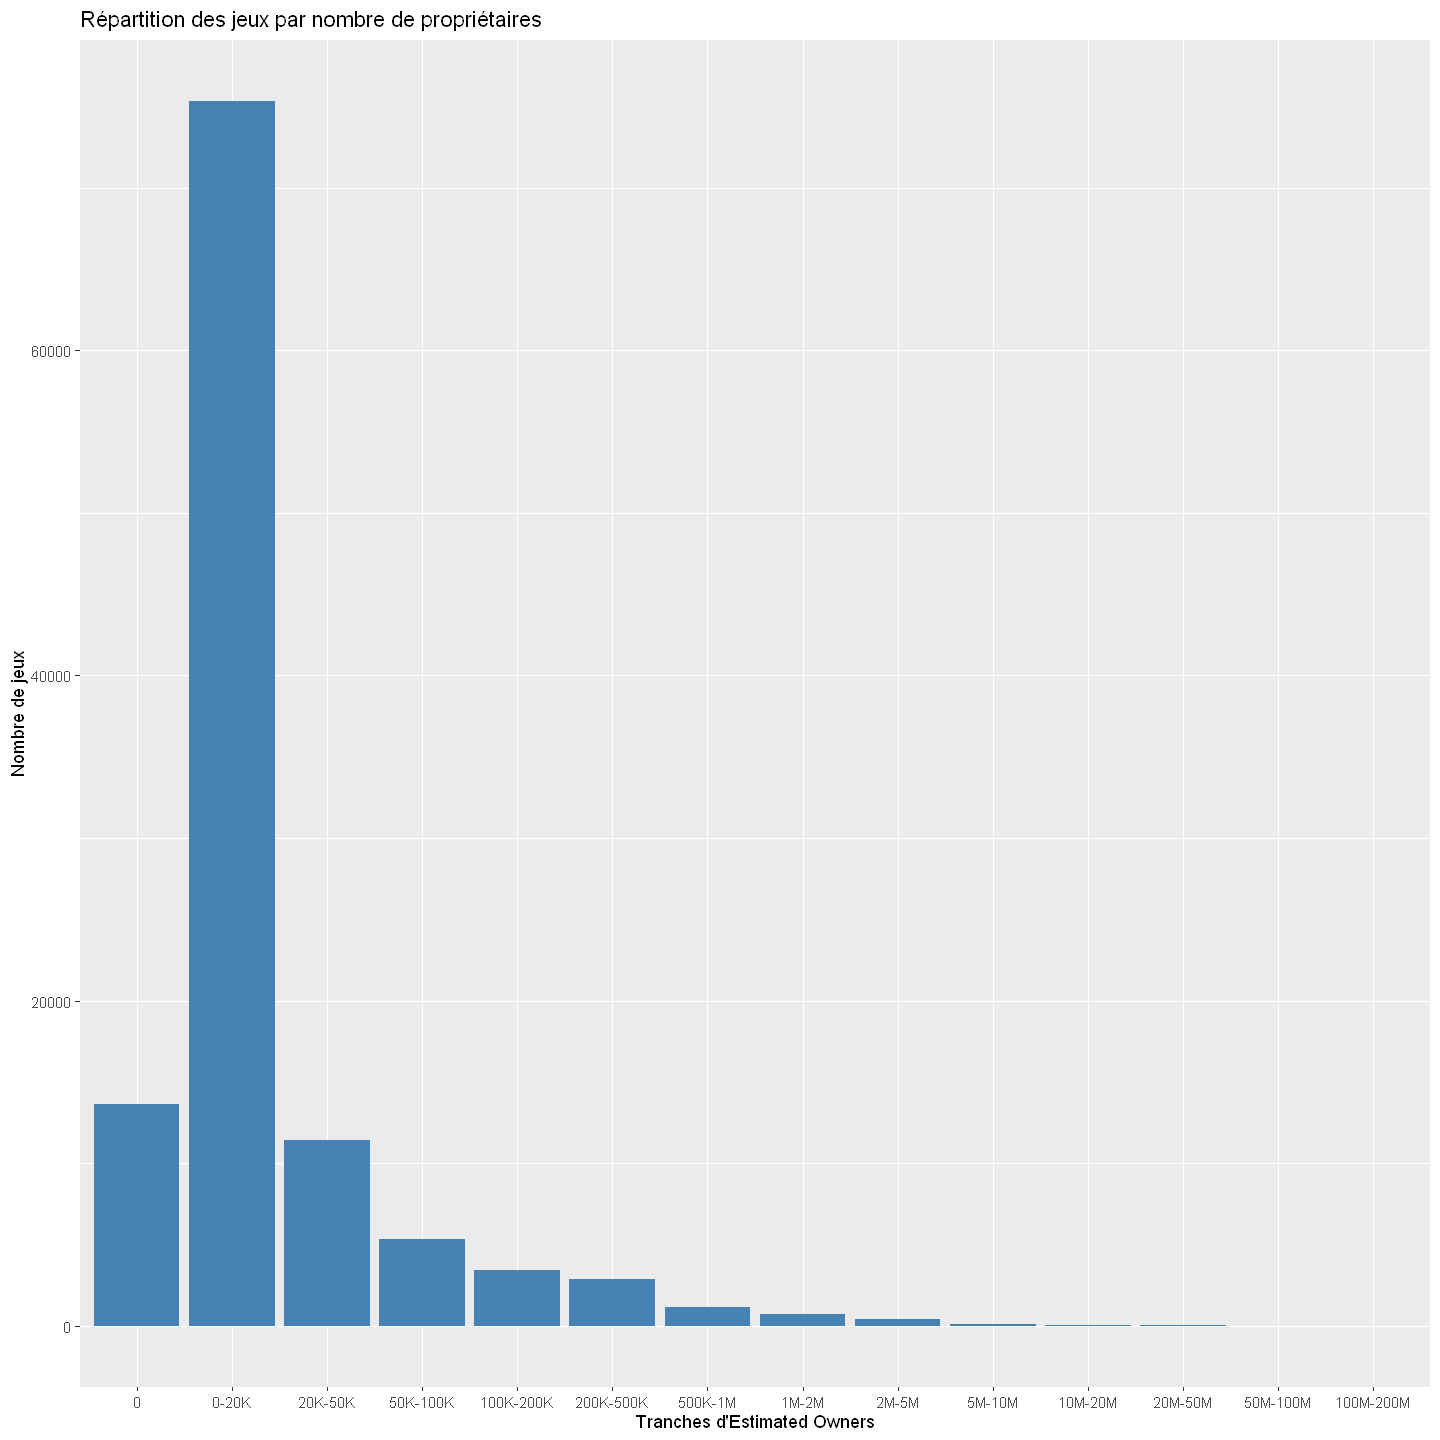

In [152]:
ggplot(data_ready, aes(x = Estimated.owners)) +
  geom_bar(fill = "steelblue") +
  labs(title = "Répartition des jeux par nombre de propriétaires",
       x = "Tranches d'Estimated Owners",
       y = "Nombre de jeux")

On choisit pour l'instant d'analyser les caractéristiques des jeux avec plus de 50 millions d'utilisateurs soit 13 jeux d'après la table.

In [219]:
popular = data_ready %>% filter(Estimated.owners %in% c("50M-100M", "100M-200M")) %>% arrange(desc(Estimated.owners))

In [154]:
print(popular)

                        Name Release.date Estimated.owners Required.age
1              Apex Legends™         2020        100M-200M            0
2           Counter-Strike 2    1997-2013        100M-200M            0
3                     Dota 2    1997-2013        100M-200M            0
4        PUBG: BATTLEGROUNDS         2017        100M-200M           13
5         Black Myth: Wukong         2024         50M-100M           13
6              Call of Duty®         2022         50M-100M           17
7  Grand Theft Auto V Legacy         2015         50M-100M           17
8              Left 4 Dead 2    1997-2013         50M-100M            0
9                   Lost Ark         2022         50M-100M           17
10       New World: Aeternum         2021         50M-100M            0
11                  Palworld         2024         50M-100M            0
12           Team Fortress 2    1997-2013         50M-100M            0
13                  Unturned         2017         50M-100M      

On ne peut tirer des analyses que sur certaines variables:
- Le prix: Les 4 jeux avec plus de 100M d'utilisateurs sont gratuits, pour les jeux entre 50M et 100M il y a tout de même près de la moitié des jeux payant
- Les jeux sont tous présents sur windows (la plupart des jeux le sont même les moins populaires)
- Linux : 6 jeux sur 13 le supportent. C'est un taux très élevé par rapport à la moyenne du reste (13% pour tous les jeux contre 46% pour les jeux populaires), ce qui montre que ces jeux cherchent à être accessibles partout.
- Les métracritics scores sont élevées (plus de 88) mais 8/13 jeux ne sont pas notés. Metacritic ne note que les jeux qui ont reçu suffisamment de critiques de la part de la presse spécialisée au moment de leur sortie. Peut-être que certains jeux très populaires ont bâti leur succès sur le bouche-à-oreille et les évaluations joueurs plutôt que sur la presse traditionnelle.
- On retrouve beaucoup de AAA publishers : Electronic Arts, Valve, KRAFTON Inc.,Activision
- Tous les jeux ont le genre "action", beaucoup ont "free to play", "adventure"...
- Nb de langues quand même assez élevé pour les 4 premiers mais pas forcément pour les autres ( exemple 1 seule langue pour le dernier)

Pour y voir clair, on va comparer les moyennes des variables quatitatives entre le TOP 13 et le data set global.

In [221]:
summary(popular)

     Name              Release.date  Estimated.owners  Required.age
 Length:13          1997-2013:4     50M-100M :9       0      :8    
 Class :character   2017     :2     100M-200M:4       17     :3    
 Mode  :character   2022     :2     0        :0       13     :2    
                    2024     :2     0-20K    :0       1      :0    
                    2015     :1     20K-50K  :0       3      :0    
                    2020     :1     50K-100K :0       6      :0    
                    (Other)  :1     (Other)  :0       (Other):0    
    Discount       Windows      Mac       Linux   Metacritic.score   User.score
 Min.   : 0.000   False: 0   False:11   False:8   Min.   : 0       Min.   :0   
 1st Qu.: 0.000   True :13   True : 2   True :5   1st Qu.: 0       1st Qu.:0   
 Median : 0.000                                   Median : 0       Median :0   
 Mean   : 5.385                                   Mean   :35       Mean   :0   
 3rd Qu.: 0.000                                   3rd Qu

In [223]:
# 1. Liste des variables quantitatives à comparer (celles de ta photo)
vars_to_compare <- c("LPositive", "LNegative", "LRecommendations", "LPeak.CCU", 
                     "LDLC.count", "LPrice", "LAverage.playtime.forever", 
                     "LMedian.playtime.forever", "LLanguageCount","Discount","Metacritic.score","User.score",
                     "Achievements","Average.playtime.two.weeks","Median.playtime.two.weeks")

# 2. Calcul des moyennes pour data_ready
mean_ready <- data_ready %>%
  summarise(across(all_of(vars_to_compare), \(x) mean(x, na.rm = TRUE))) %>%
  pivot_longer(everything(), names_to = "Variable", values_to = "Moyenne_Ready")

# 3. Calcul des moyennes pour popular
mean_popular <- popular %>%
  summarise(across(all_of(vars_to_compare), \(x) mean(x, na.rm = TRUE))) %>%
  pivot_longer(everything(), names_to = "Variable", values_to = "Moyenne_Popular")

# 4. Fusion des deux et calcul de la différence en %
tableau_comparatif <- left_join(mean_ready, mean_popular, by = "Variable") %>%
  mutate(Augmentation_Pct = round(((Moyenne_Popular - Moyenne_Ready) / Moyenne_Ready) * 100, 2))

# Affichage du tableau
print(tableau_comparatif)

# A tibble: 15 × 4
   Variable                   Moyenne_Ready Moyenne_Popular Augmentation_Pct
   <chr>                              <dbl>           <dbl>            <dbl>
 1 LPositive                         2.42            13.6              462. 
 2 LNegative                         1.58            11.9              652. 
 3 LRecommendations                  1.17            12.1              935. 
 4 LPeak.CCU                         0.356           10.9             2958. 
 5 LDLC.count                        0.158            0.918            480. 
 6 LPrice                            1.31             0.959            -26.7
 7 LAverage.playtime.forever         1.20             9.22             670. 
 8 LMedian.playtime.forever          1.17             7.50             542. 
 9 LLanguageCount                    1.46             2.84              93.6
10 Discount                         19.6              5.38             -72.6
11 Metacritic.score                  2.70            35  

- Nombre de Langues (LanguageCount) : Le Top 13 affiche une moyenne de 20 langues contre 7,5 pour l'ensemble du dataset. Cela montre qu'un succès massif passe souvent par une stratégie de localisation mondiale agressive.

- Systèmes d'Exploitation : Alors que moins de 14% des jeux Steam supportent Linux dans l'ensemble du dataset (15 672 sur 114 513), près de 38% (5 sur 13) des titres les plus populaires le font. L'universalité technique semble être un prérequis du succès.

- Temps de jeu des deux dernières semaines (Average.playtime.two.weeks) : La moyenne est de 826 minutes (soit près de 14 heures par quinzaine) pour les jeux populaires, contre une moyenne globale de seulement 14,7 minutes. Cela souligne que les jeux populaires sont des "aspirateurs de temps" qui occupent les joueurs de manière continue.

- DLC (DLC.count) : Le Top 13 propose en moyenne 4,6 DLC par jeu, contre 0,55 globalement. Même les jeux gratuits du top (comme Apex Legends ou Dota 2) utilisent ces contenus additionnels pour enrichir l'expérience et monétiser l'audience.

- Recommandations (Recommendations) : C'est l'écart le plus vertigineux. Une moyenne de 862 000 recommandations pour le Top 13 contre seulement 954 pour la moyenne générale. Le succès sur Steam s'auto-alimente : plus un jeu est recommandé, plus il est visible, plus il attire d'utilisateurs.

- Scores Critiques (Metacritic.score) : Bien que beaucoup ne soient pas notés, la moyenne du Top 13 est de 35 (incluant les zéros) contre 2,7 globalement. Si l'on ne regarde que les jeux notés, le Top 13 se situe toujours dans l'excellence (>88).

In [170]:
top_13_genres <- popular %>%
  separate_rows(Genres, sep = ",") %>%
  mutate(Genres = str_trim(Genres)) %>%
  count(Genres, sort = TRUE)

top_13_genres

Genres,n
<chr>,<int>
Action,13
Adventure,8
Free To Play,7
RPG,4
Massively Multiplayer,3
Indie,2
Casual,1
Early Access,1
Strategy,1


In [171]:
top_13_categories <- popular %>%
  separate_rows(Categories, sep = ",") %>%
  mutate(Categories = str_trim(Categories)) %>%
  count(Categories, sort = TRUE)

head(top_13_categories,10)

Categories,n
<chr>,<int>
Multi-player,12
Steam Achievements,10
Co-op,9
Camera Comfort,8
Custom Volume Controls,8
In-App Purchases,8
Online Co-op,8
Online PvP,8
Playable without Timed Input,8


In [172]:
top_13_langue <- popular %>%
  separate_rows(Language, sep = ",") %>%
  mutate(Language = str_trim(Language)) %>%
  count(Language, sort = TRUE)
head(top_13_langue,10)

Language,n
<chr>,<int>
English,23
Spanish-Spain,17
French,15
German,15
SimplifiedChinese,14
Italian,13
Portuguese-Brazil,13
Spanish-Latimerica,13
Japanese,12


# CA

On va maintenant essayer de mettre en évidence la relation entre Estimated.owners et Genres à travers une CA. Pour ce faire il faut d'abord séparer et bien encoder les genres.

In [35]:
data_prep <- data_ready %>%
  select(Genres, Estimated.owners) %>%
  separate_rows(Genres, sep = ",") %>%
  mutate(Genres = trimws(Genres)) %>% #On enlève les espaces devant ou après mot
  filter(Genres != "") # On enlève les genres vides pour que le tableau de crée pas un genre ""

# Tableau de contingence
data_ca <- table(data_prep$Genres, data_prep$Estimated.owners)

In [36]:
head(data_ca,15)

                       
                            0 0-20K 20K-50K 50K-100K 100K-200K 200K-500K
  360 Video                 0     1       0        0         0         0
  Accounting                6    18       1        3         2         0
  Action                 4907 30032    4703     2252      1482      1338
  Adventure              4778 29338    5022     2322      1496      1141
  Animation & Modeling     67   342      26       13        12         7
  Audio Production         23   170      15        4         8         3
  Casual                 6596 35254    4350     1786      1049       740
  Design & Illustration    51   446      30       16        19         9
  Documentary               0     1       0        0         0         0
  Early Access           1350  7921     889      411       238       159
  Education                59   352      27        6         8         5
  Episodic                  0     1       0        0         0         0
  Free To Play           63

In [37]:
print(rowSums(data_ca))

            360 Video            Accounting                Action 
                    1                    30                 46155 
            Adventure  Animation & Modeling      Audio Production 
                45104                   477                   225 
               Casual Design & Illustration           Documentary 
                50192                   580                     1 
         Early Access             Education              Episodic 
                11091                   461                     1 
         Free To Play      Game Development                  Gore 
                12160                   320                   256 
                Indie Massively Multiplayer                 Movie 
                80610                  2525                     2 
               Nudity         Photo Editing                Racing 
                   94                   180                  4077 
                  RPG        Sexual Content                 Sh

Pb: Certains genres sont sous représentés comme 360 Video, Documentary,Episodic,Short,Movie, Tutorial qui n'apparaissentqu'une fois ou Accounting que 30 fois. Cela va poser problème poure l'interprétaion de la CA puisque celle-ci repose sur distance du Chi-deux qui accorde un poids très important aux petits effectifs. On va quand même réaliser la CA et voir ce que cela donne puis on décidera peut-être de ne pas étudier certains genres sous représentés. Une autre idée serait de regrouper les genres en sous effectifs mais cela n'a pas de sens niveau interprétation.

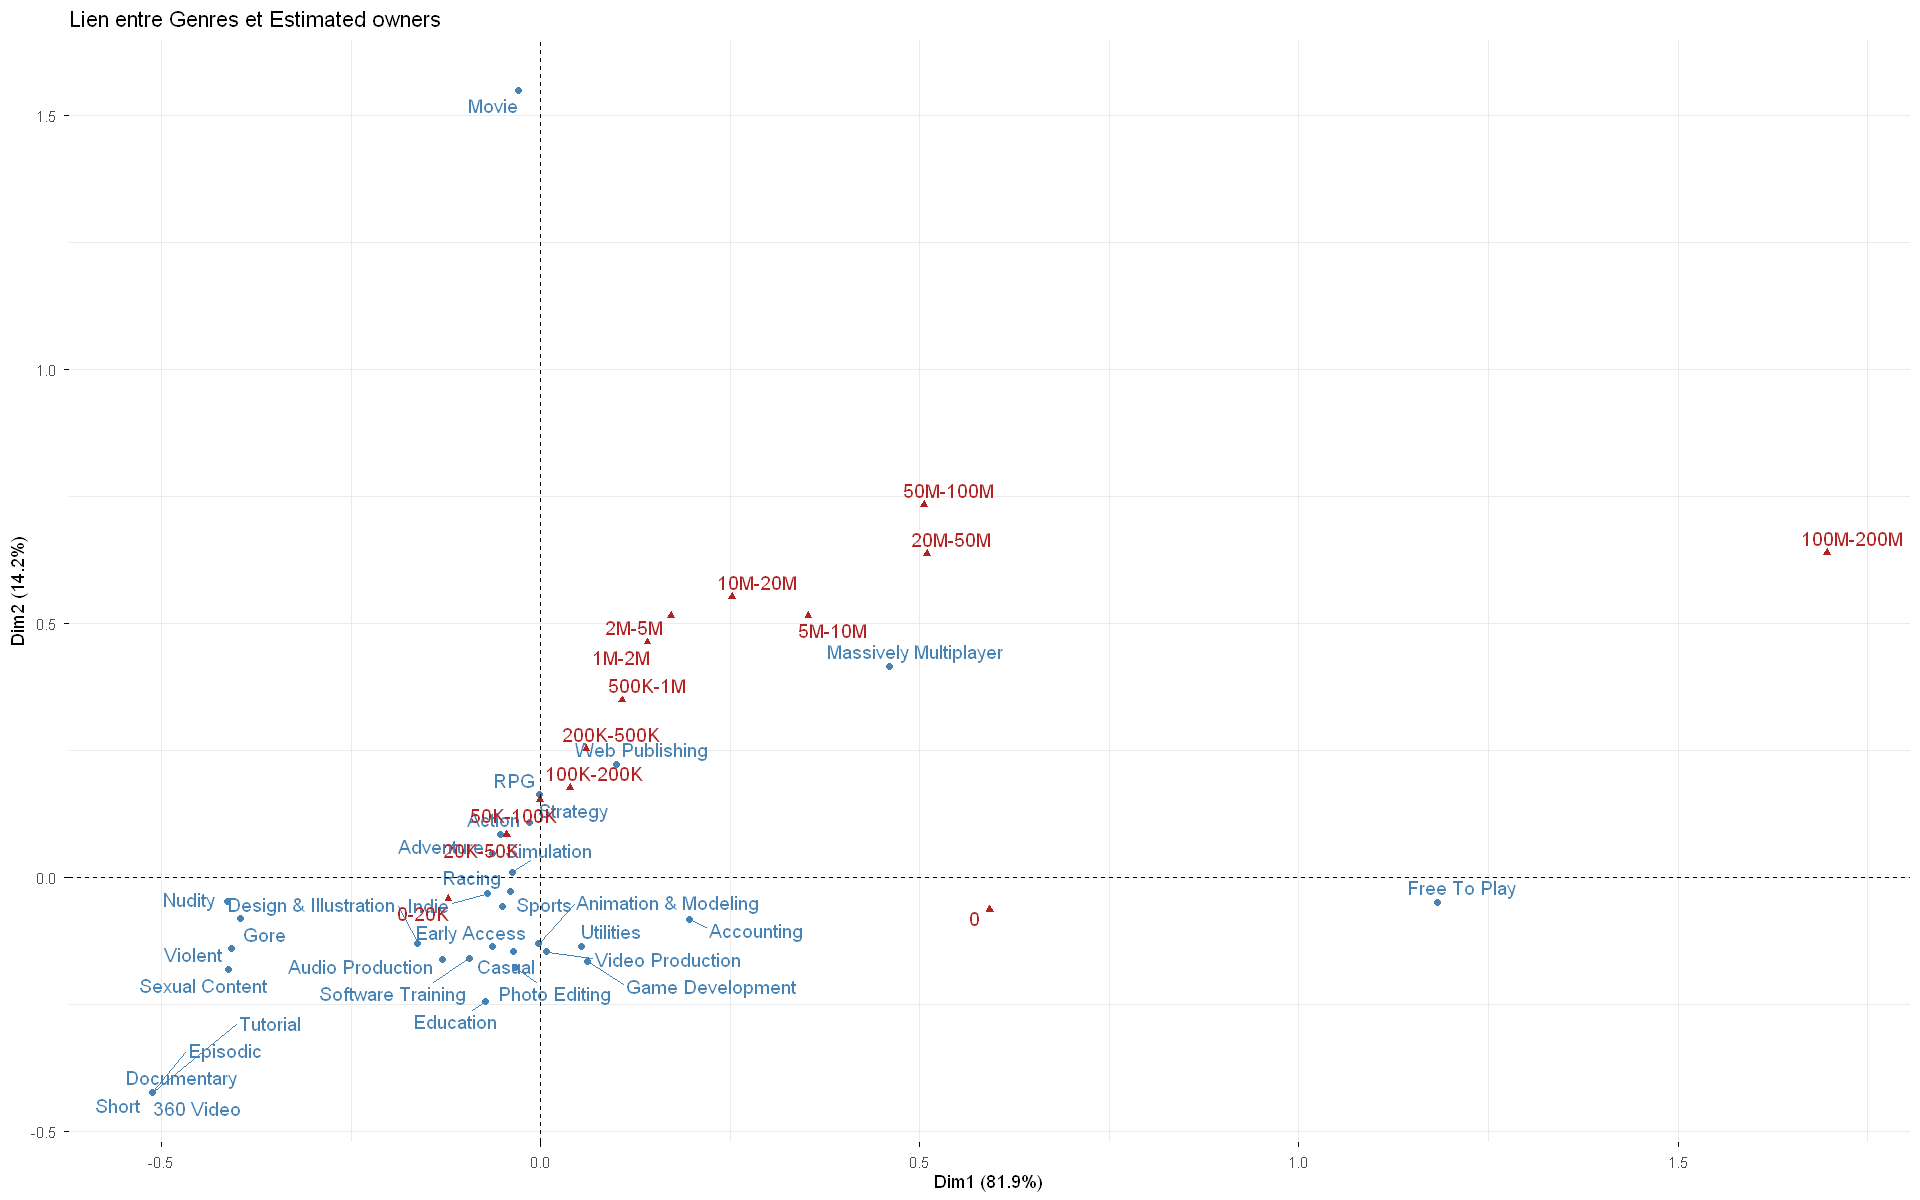

In [41]:
ca <- CA(data_ca, graph = FALSE)
options(repr.plot.width = 16, repr.plot.height =10)
fviz_ca_biplot(ca, 
               repel = TRUE, 
               col.row = "steelblue", 
               col.col = "firebrick", 
               title = "Lien entre Genres et Estimated owners")

In [42]:
ca$eig

,eigenvalue,percentage of variance,cumulative percentage of variance
dim 1,5.647575e-02,81.931010174,81.93101
dim 2,9.814248e-03,14.237813332,96.16882
dim 3,1.562981e-03,2.267461834,98.43629
dim 4,4.066147e-04,0.589887703,99.02617
dim 5,2.268262e-04,0.329063262,99.35524
dim 6,1.581882e-04,0.229488126,99.58472
dim 7,1.096235e-04,0.159034010,99.74376
dim 8,6.882480e-05,0.099846130,99.84360
dim 9,5.598926e-05,0.081225234,99.92483
dim 10,2.289534e-05,0.033214930,99.95804


**Qualité de représentation**

In [43]:
ca$row$cos2

,Dim 1,Dim 2,Dim 3,Dim 4,Dim 5
360 Video,4.828938e-01,0.33209977,0.1668397430,1.092521e-02,9.513126e-05
Accounting,1.648320e-01,0.02994439,0.0306914181,1.233664e-01,5.691181e-05
Action,2.283875e-01,0.58219113,0.1376603309,1.783944e-02,1.032270e-02
Adventure,5.453780e-01,0.30847802,0.0969405690,3.353408e-02,6.610021e-06
Animation & Modeling,9.288126e-05,0.32119930,0.5132239381,2.919843e-03,1.178717e-03
Audio Production,2.344873e-01,0.37031029,0.1282263449,1.653762e-02,1.345531e-01
Casual,5.604018e-02,0.93556494,0.0044353176,3.309041e-03,8.136641e-05
Design & Illustration,3.271071e-01,0.21073966,0.3026595894,3.024501e-02,4.529885e-04
Documentary,4.828938e-01,0.33209977,0.1668397430,1.092521e-02,9.513126e-05
Early Access,1.615671e-01,0.75964285,0.0489542118,1.290650e-04,1.312640e-02


Quel est le genre le mieux représenté par l'axe 1 ?

In [44]:
i = 1
idx = which.max(ca$row$cos2[,i])

print(paste("The genre",row.names(data_ca)[idx], "is best represented by axis", i))

[1] "The genre Free To Play is best represented by axis 1"


On affiche la qualité de représentation des genres sur l'espace CA (dim 1-2) ainsi que des tranches d'utilisateurs.

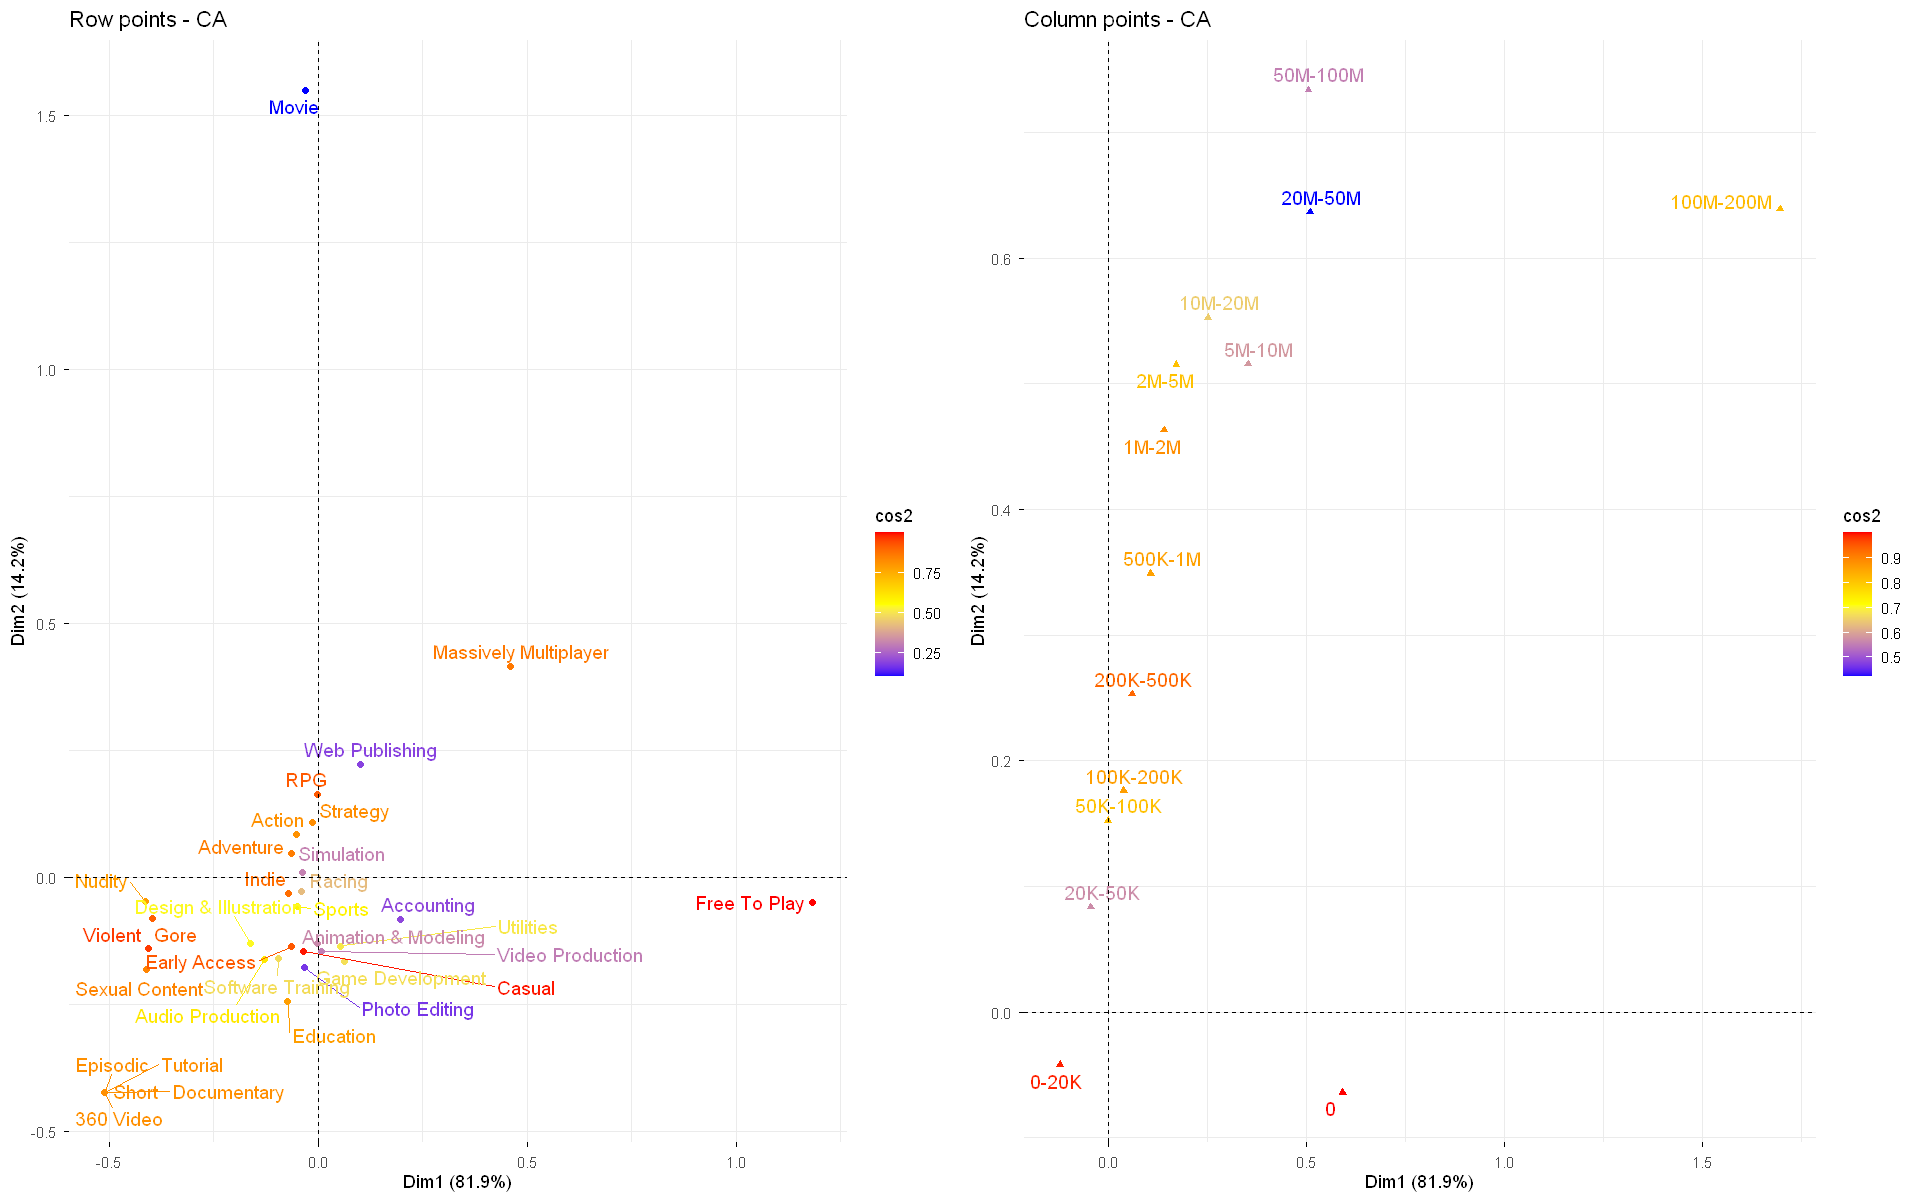

In [45]:
grid.arrange(fviz_ca_row(ca, col.row = "cos2",gradient.cols = c("blue", "yellow", "red"), repel = TRUE),fviz_ca_col(ca, col.col = "cos2",gradient.cols = c("blue", "yellow", "red"), repel = TRUE), ncol=2)

**Contribution aux axes**

Particulièrement utile ici car on a des différences d'effectifs importantes.

Contribution des genres :

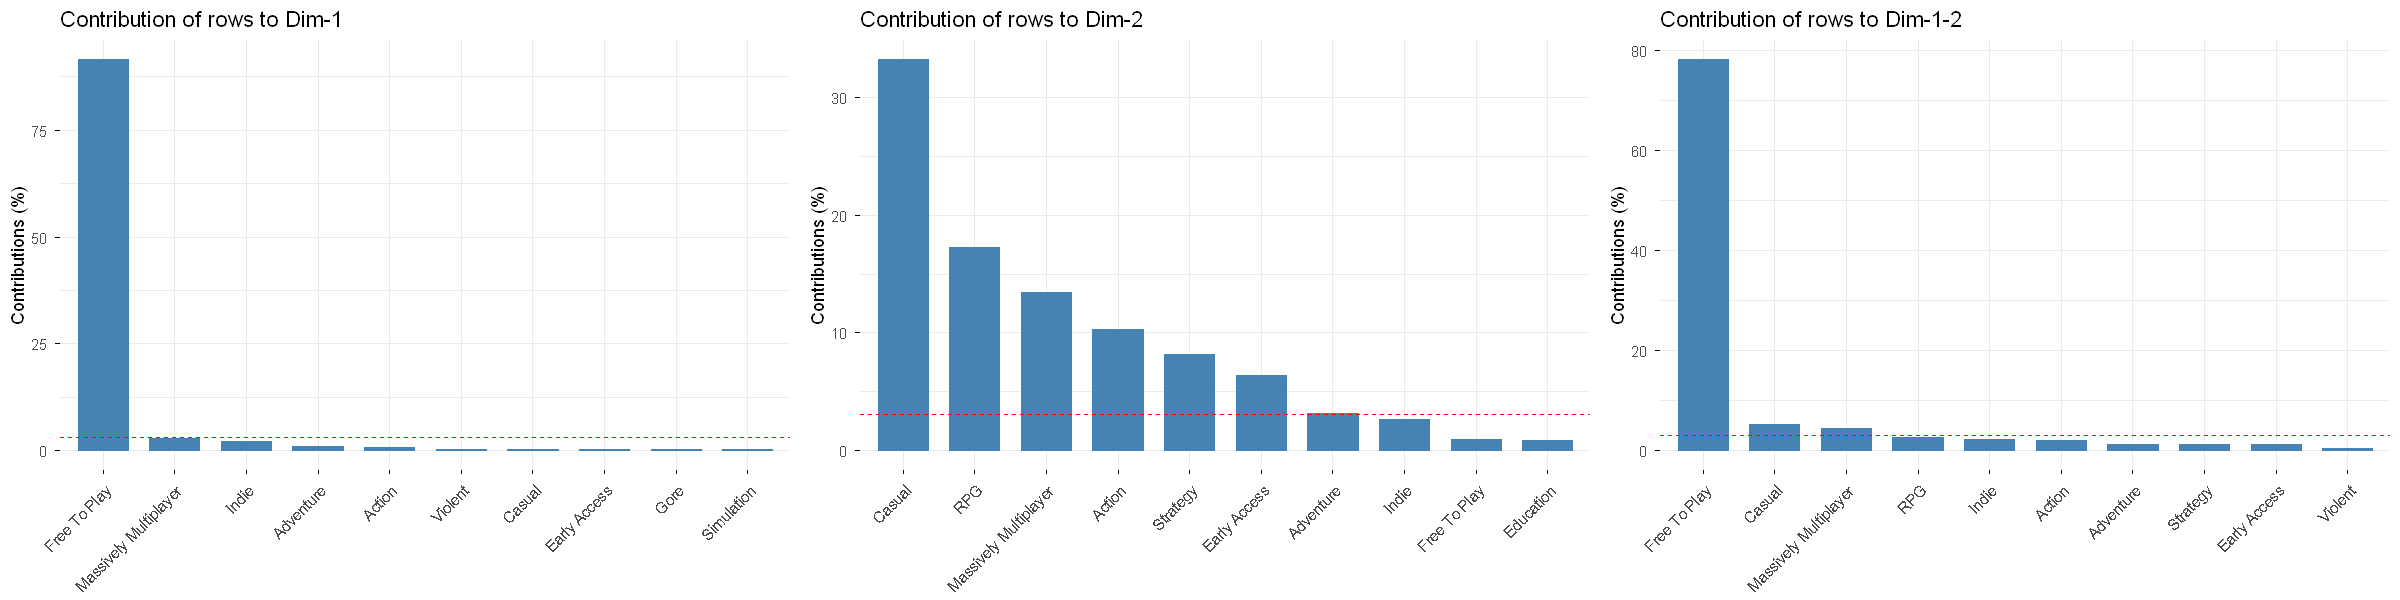

In [50]:
options(repr.plot.width = 20, repr.plot.height =5)
grid.arrange(fviz_contrib(ca, choice = "row", axes = 1, top = 10),fviz_contrib(ca, choice = "row", axes = 2, top = 10),fviz_contrib(ca, choice = "row", axes = 1:2, top = 10),ncol=3)

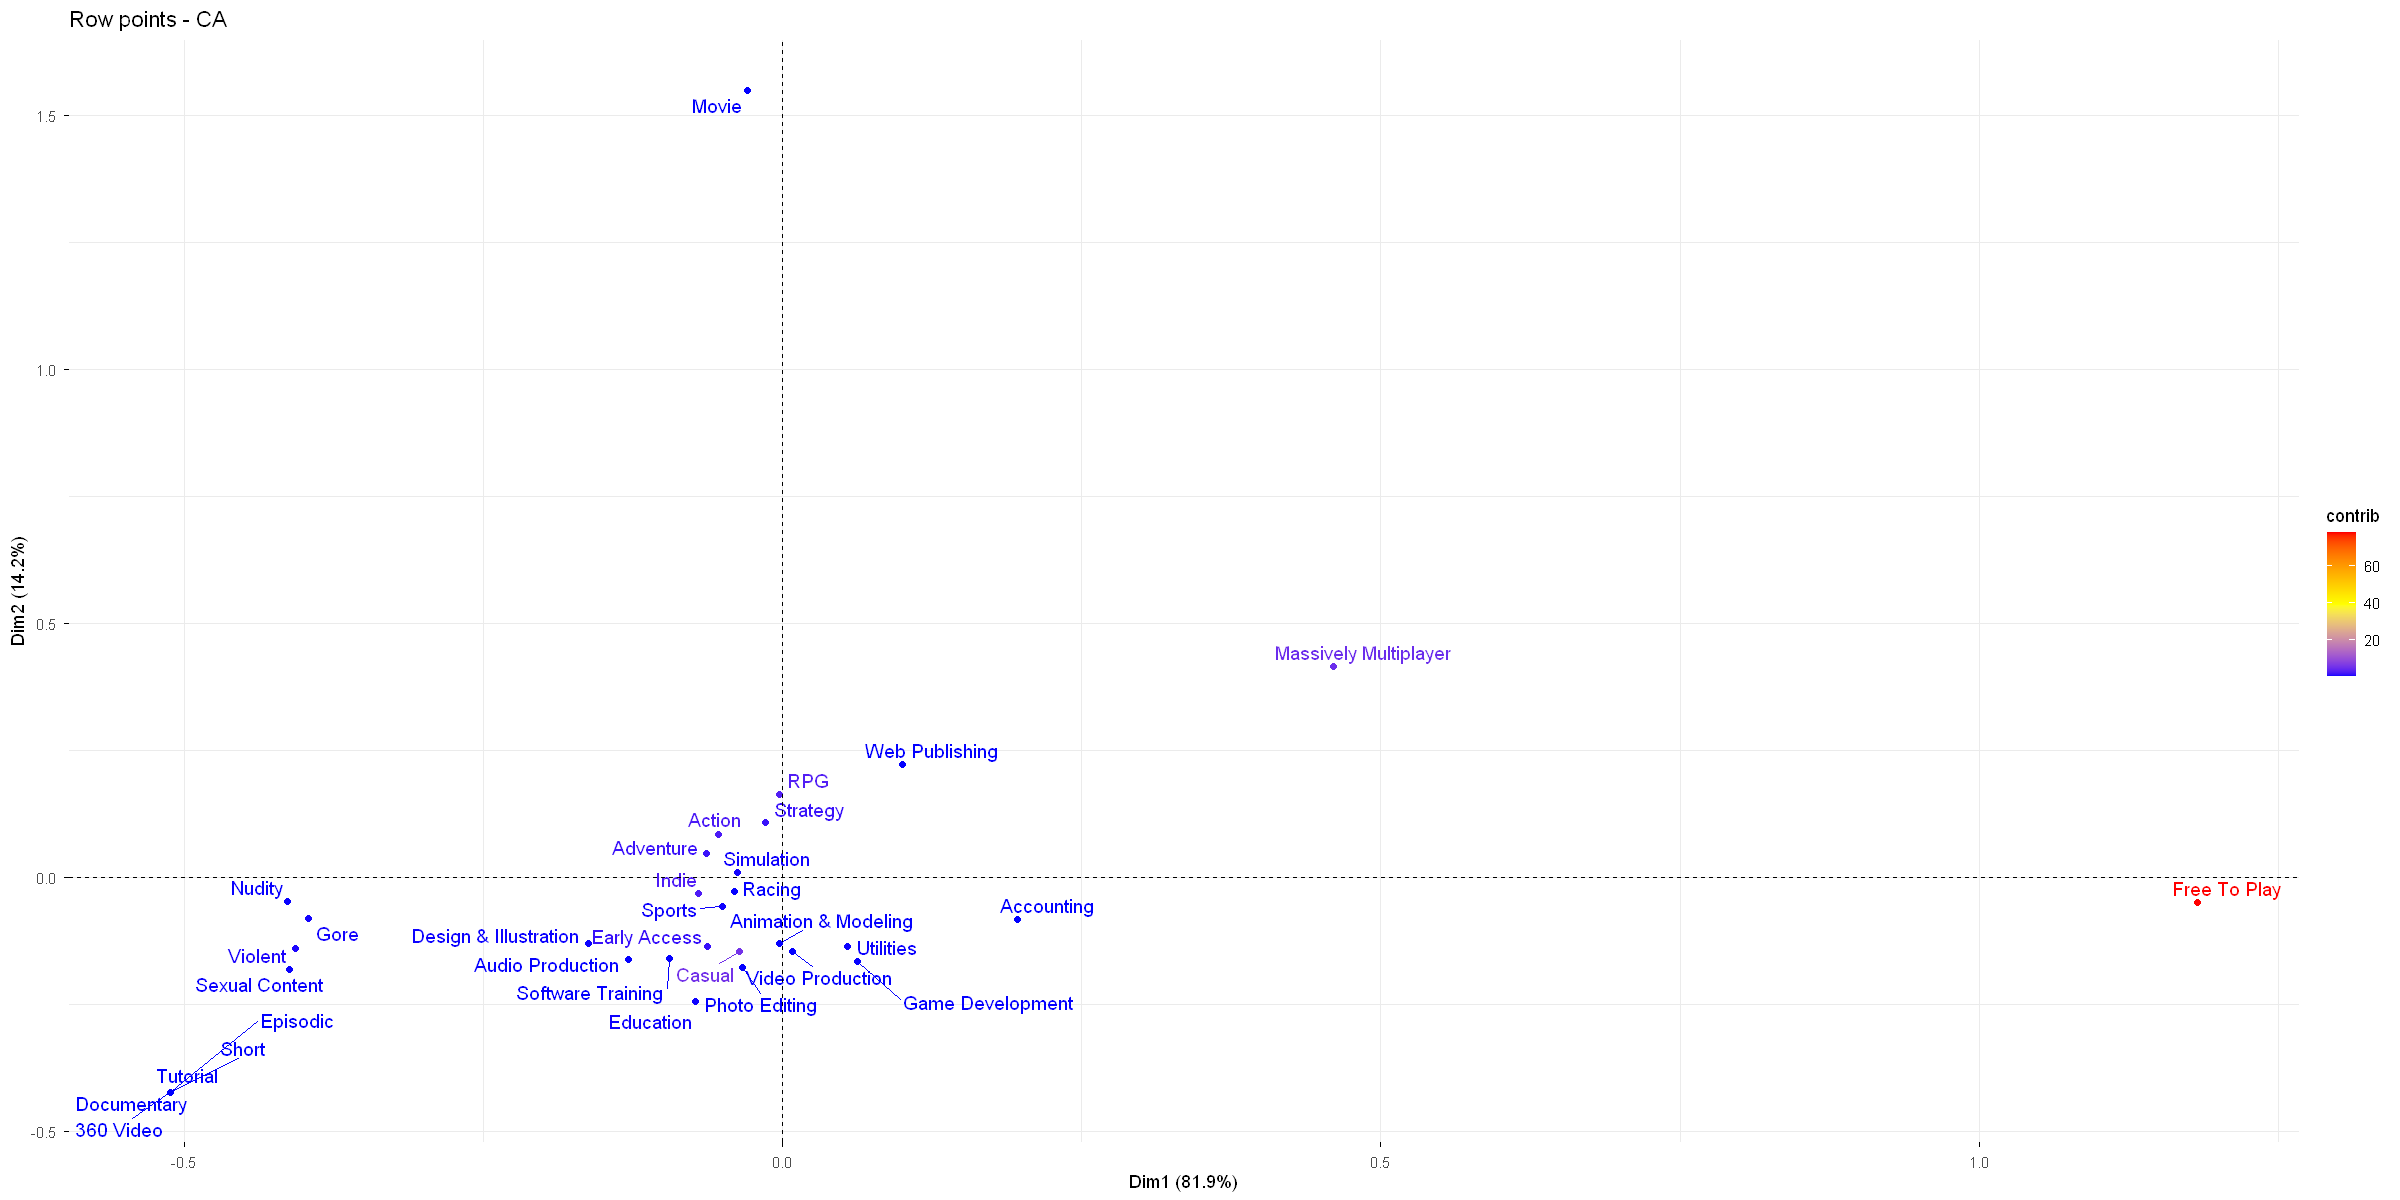

In [51]:
options(repr.plot.width = 20, repr.plot.height =10)
fviz_ca_row(ca, col.row = "contrib",
             gradient.cols = c("blue", "yellow", "red"), 
             repel = TRUE)

Contribution des tranches d'utilisateurs:

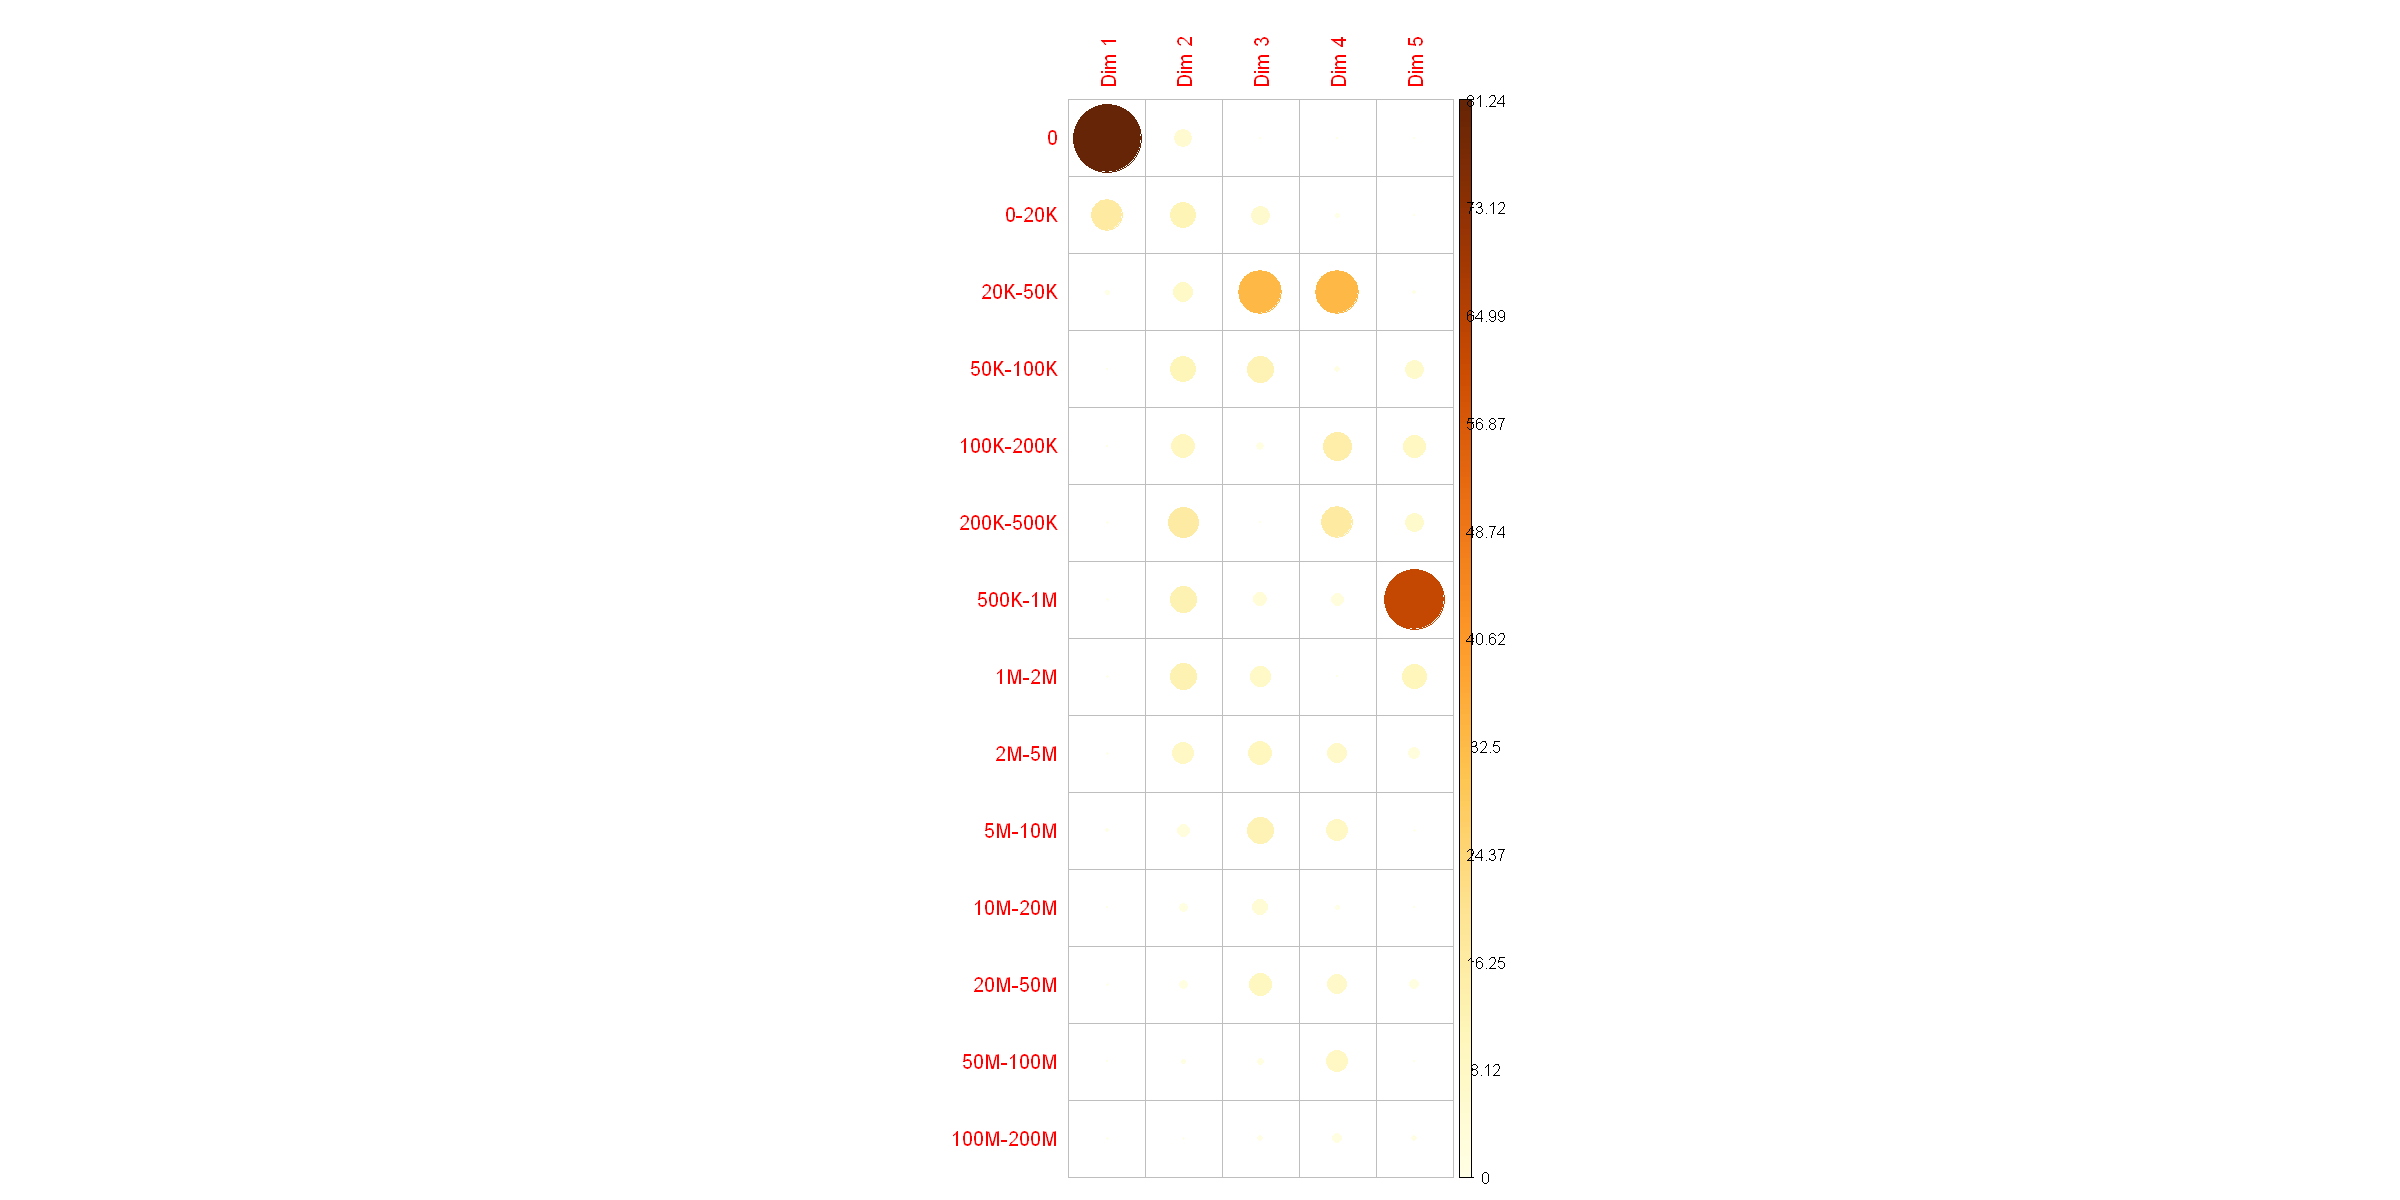

In [52]:
corrplot(ca$col$contrib, is.corr=FALSE)

Le genre Free To Play contribue à lui seul à l'axe 1 et donc presque seul au plan 1-2. Cela pose un problème d'interprétation. **Passer Free to play en variable supplémentaire ??**

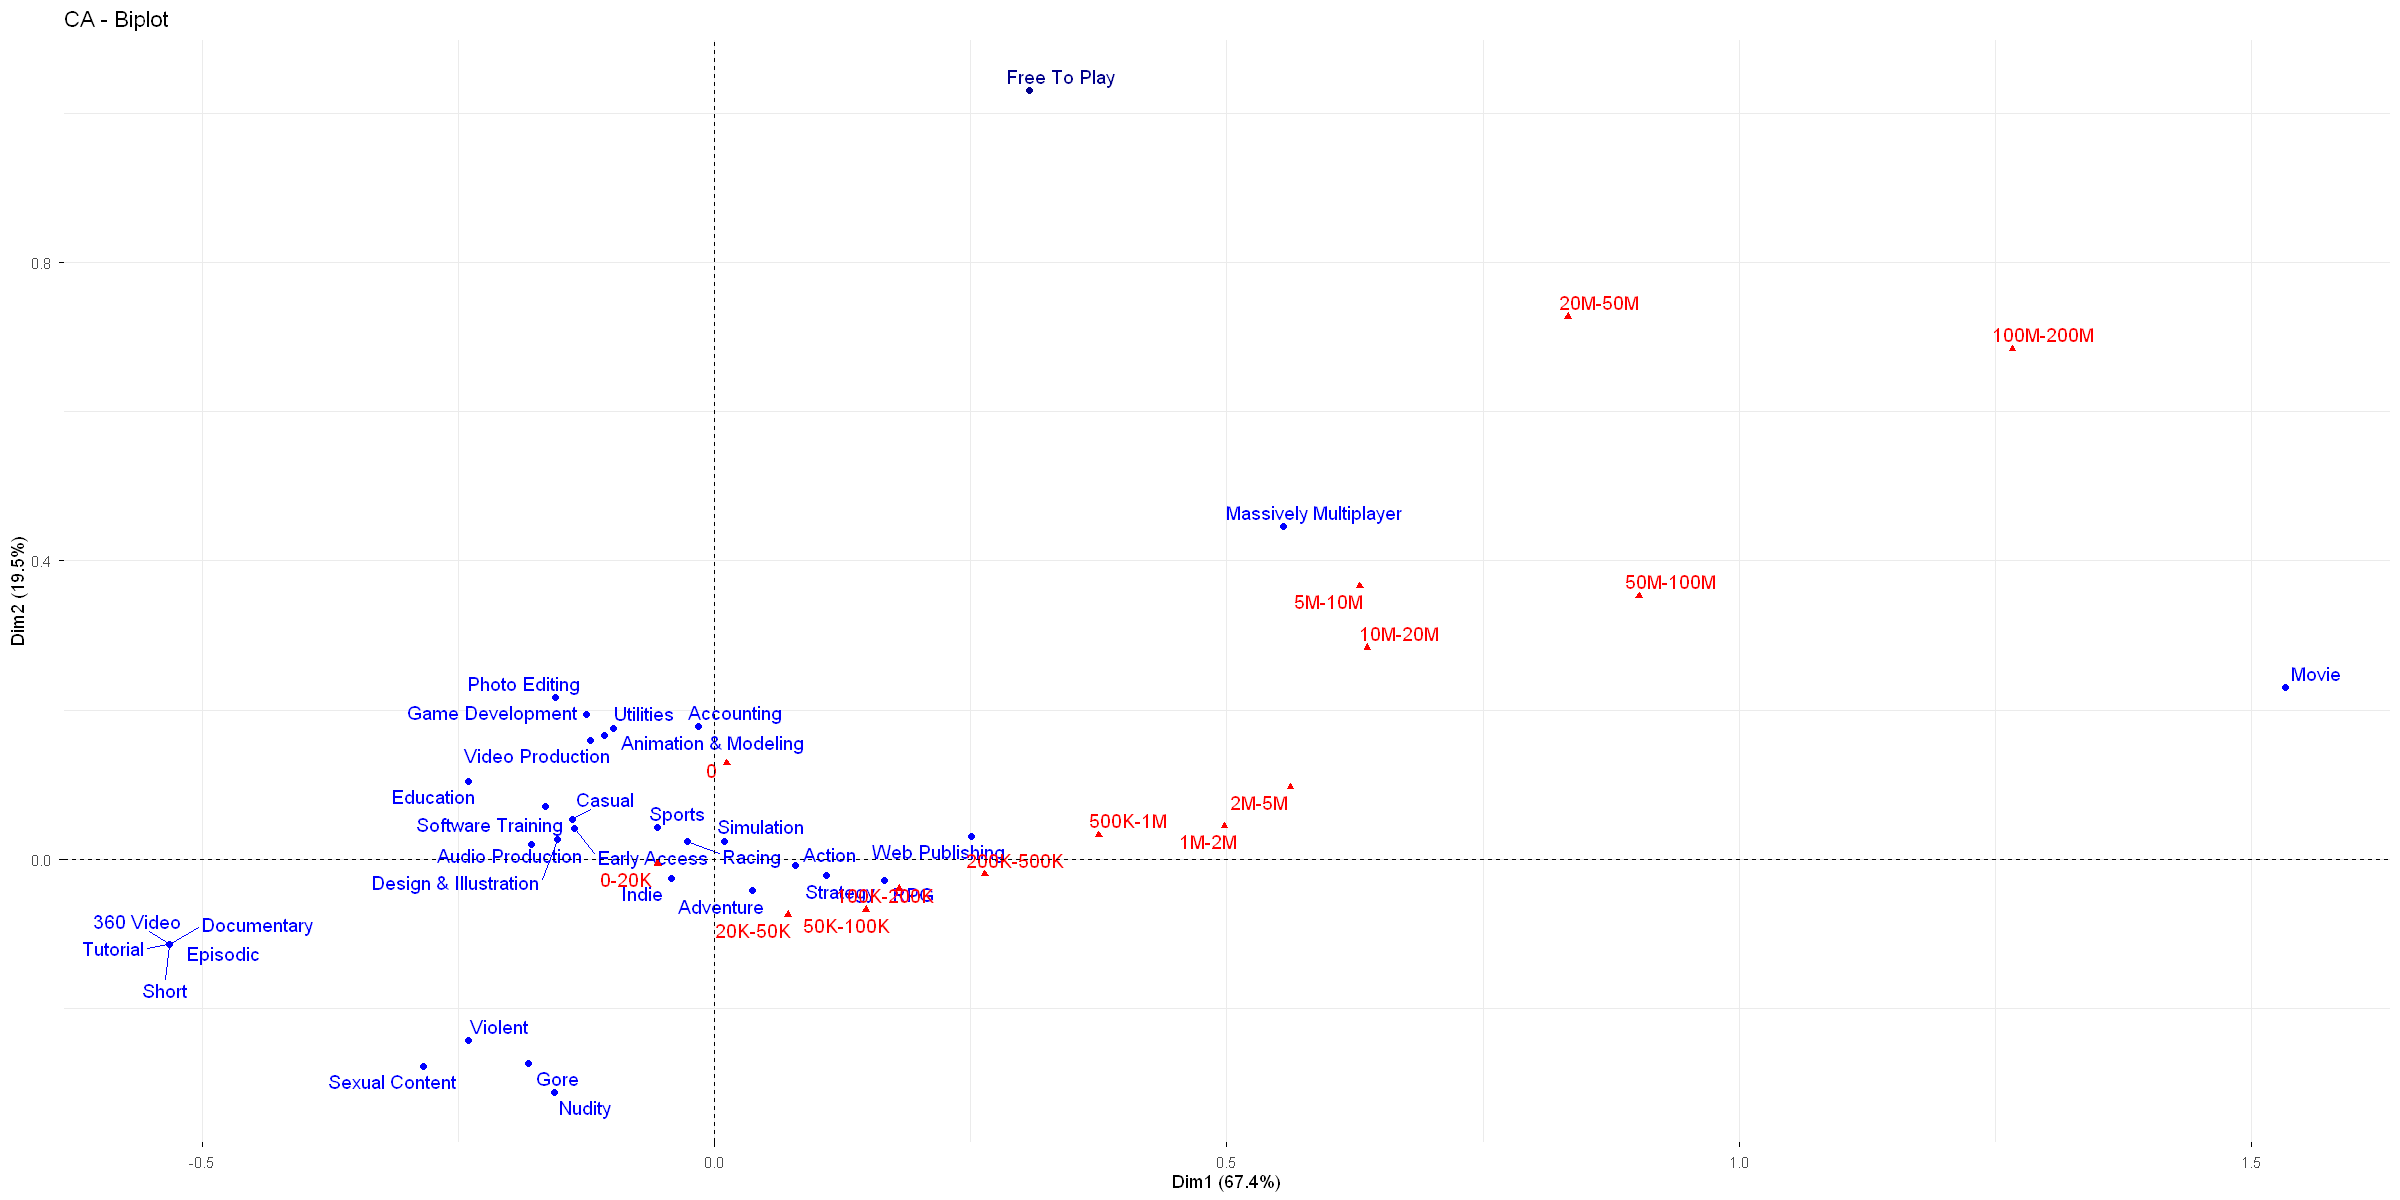

In [53]:
index_ftp <- which(rownames(data_ca) == "Free To Play")

res.ca_sans_ftp <- CA(data_ca, 
                      row.sup = index_ftp, 
                      graph = FALSE)

fviz_ca_biplot(res.ca_sans_ftp, repel = TRUE)

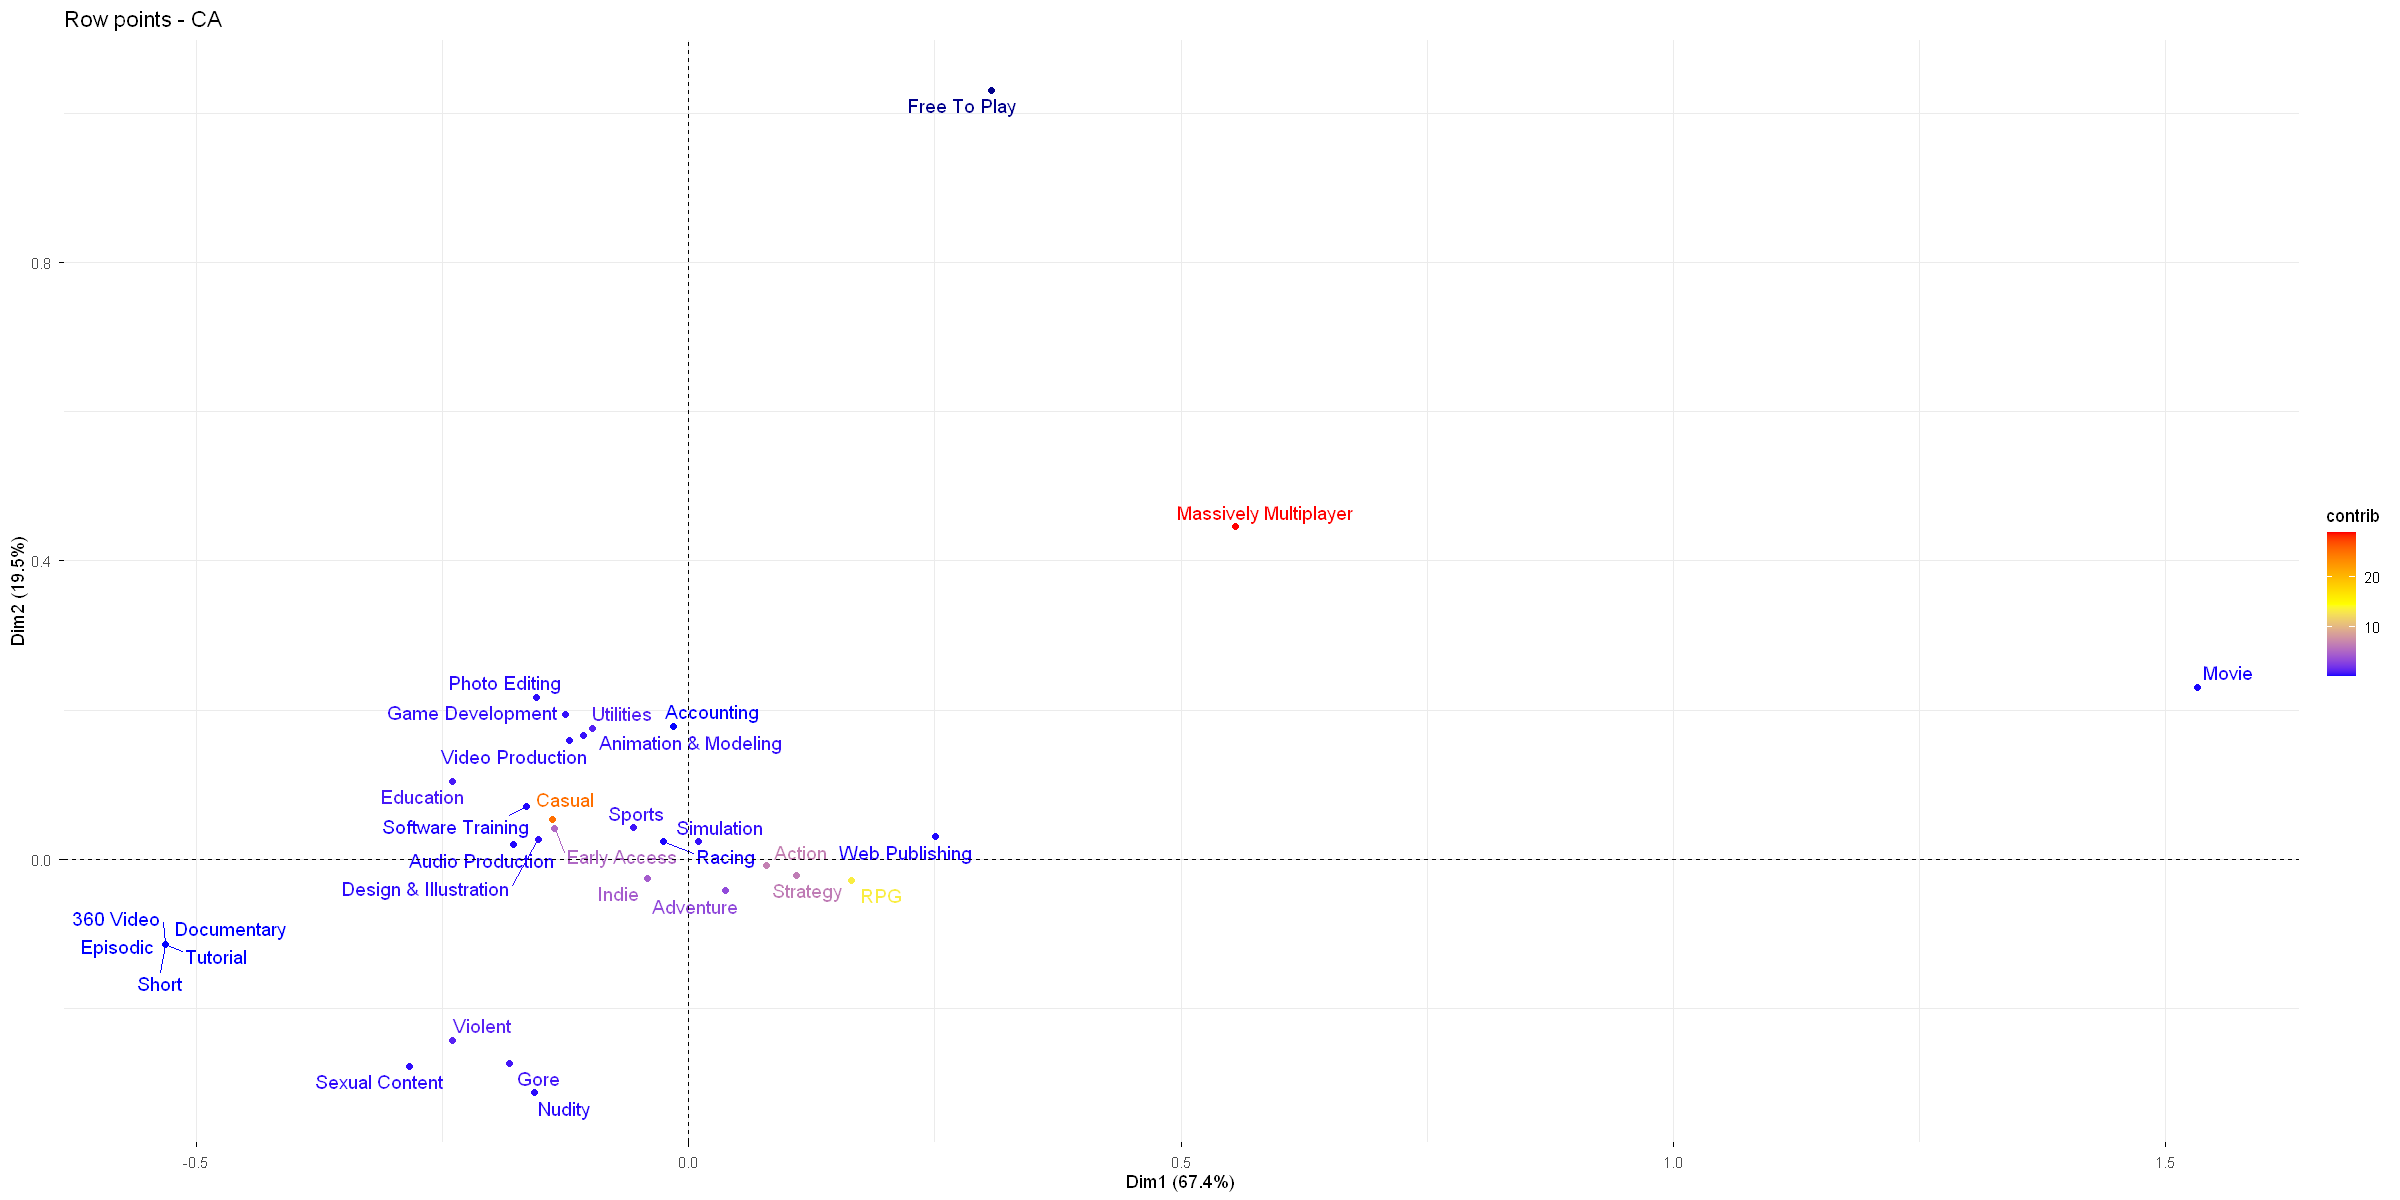

In [54]:
fviz_ca_row(res.ca_sans_ftp, col.row = "contrib",
             gradient.cols = c("blue", "yellow", "red"), 
             repel = TRUE)

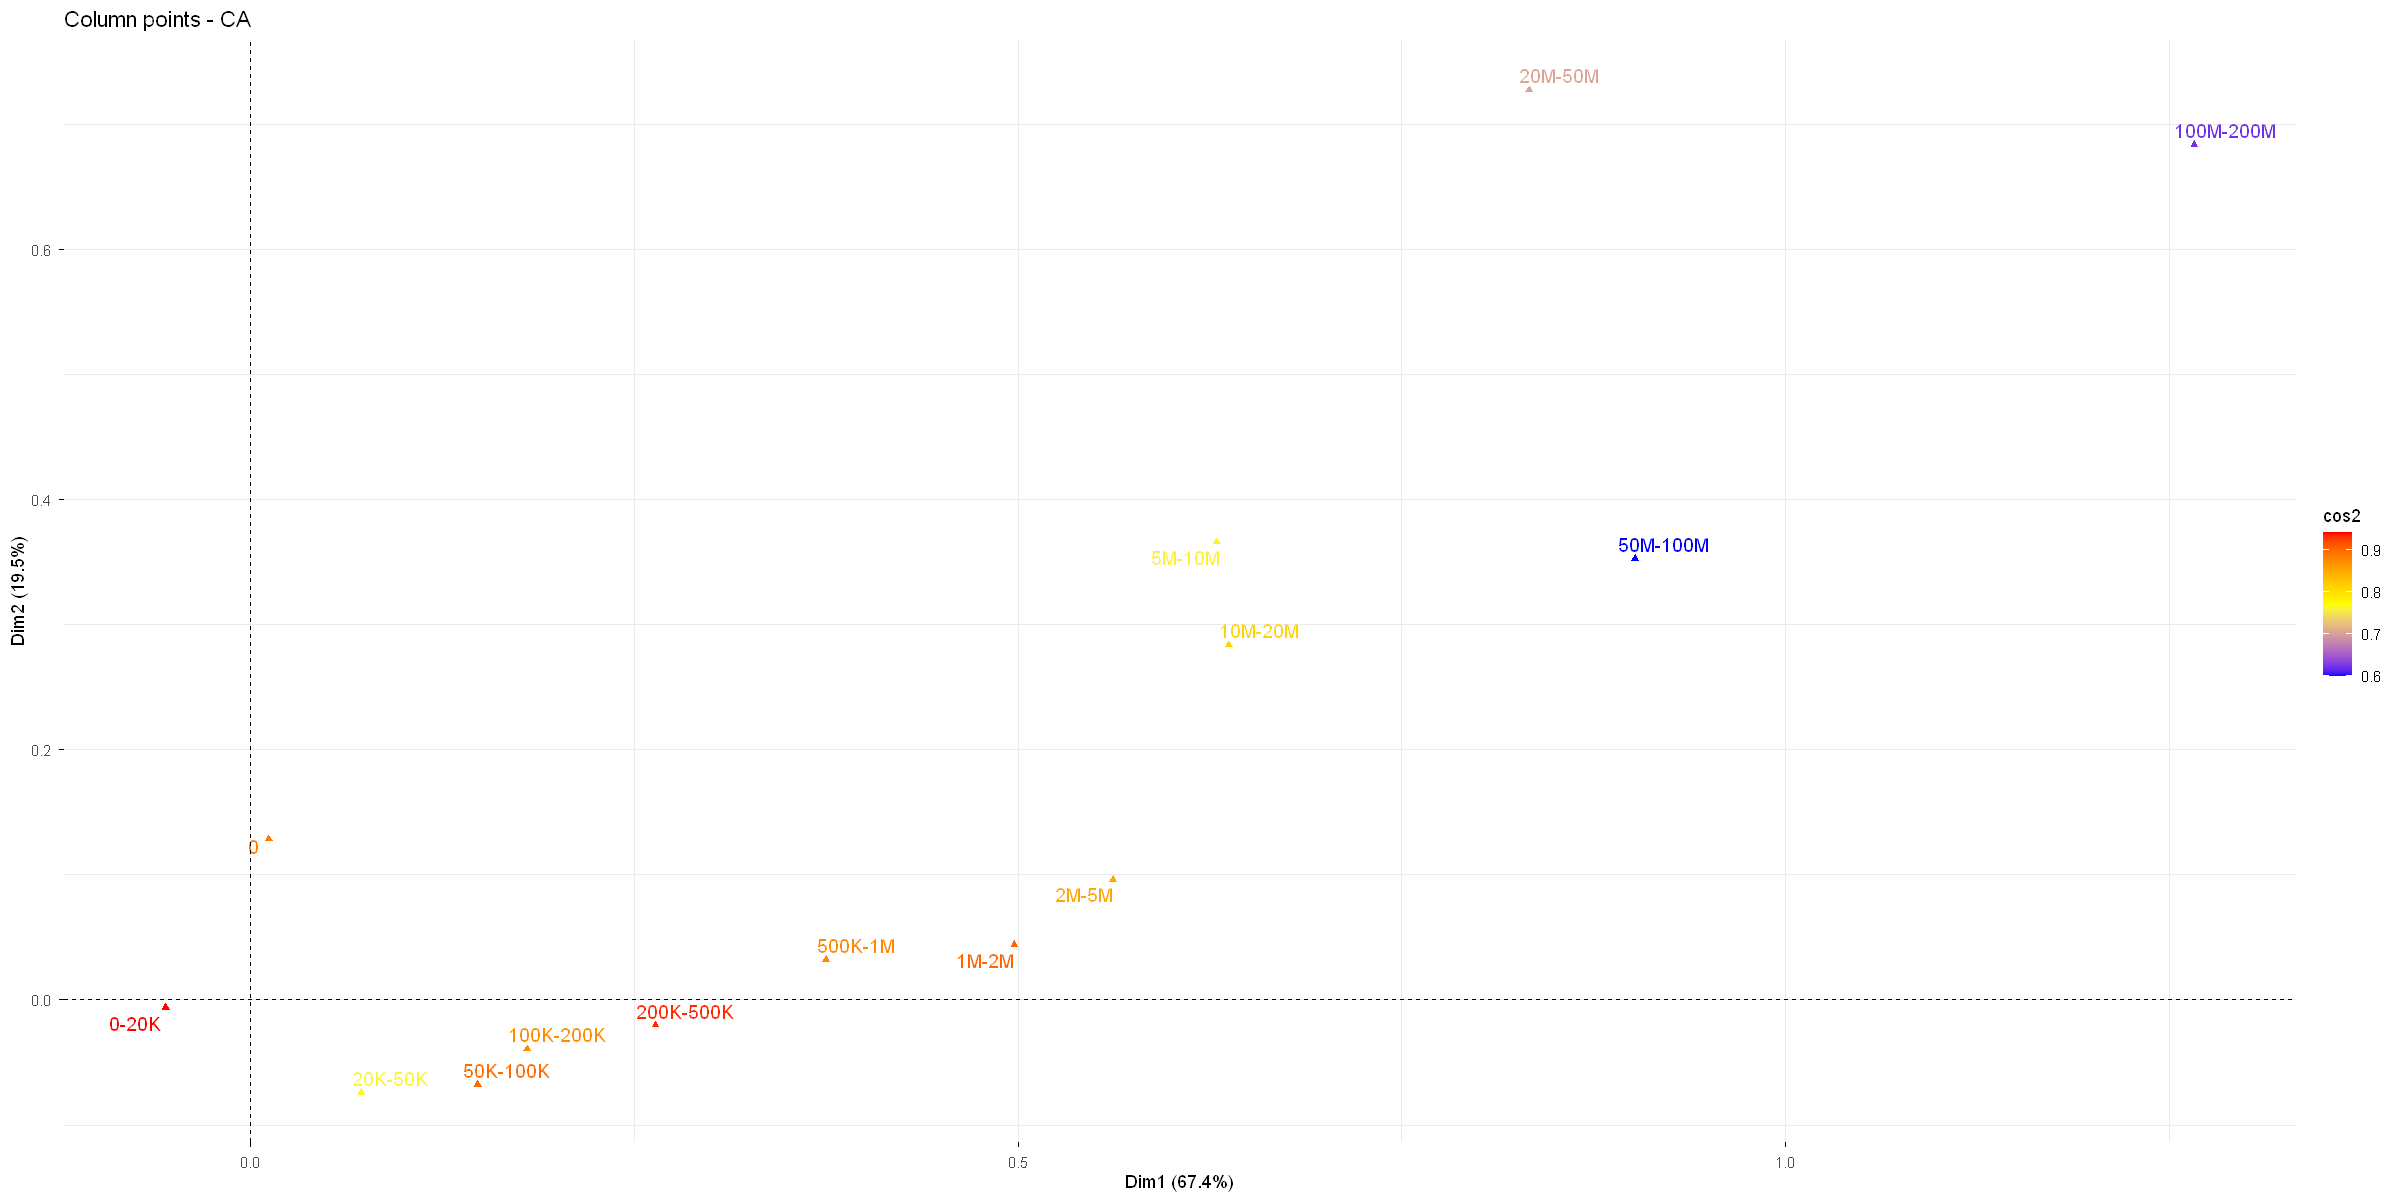

In [55]:
fviz_ca_col(res.ca_sans_ftp, col.col = "cos2",
             gradient.cols = c("blue", "yellow", "red"), 
             repel = TRUE)

# Relation entre prix, popularité, genres et nombre de langues: MFA

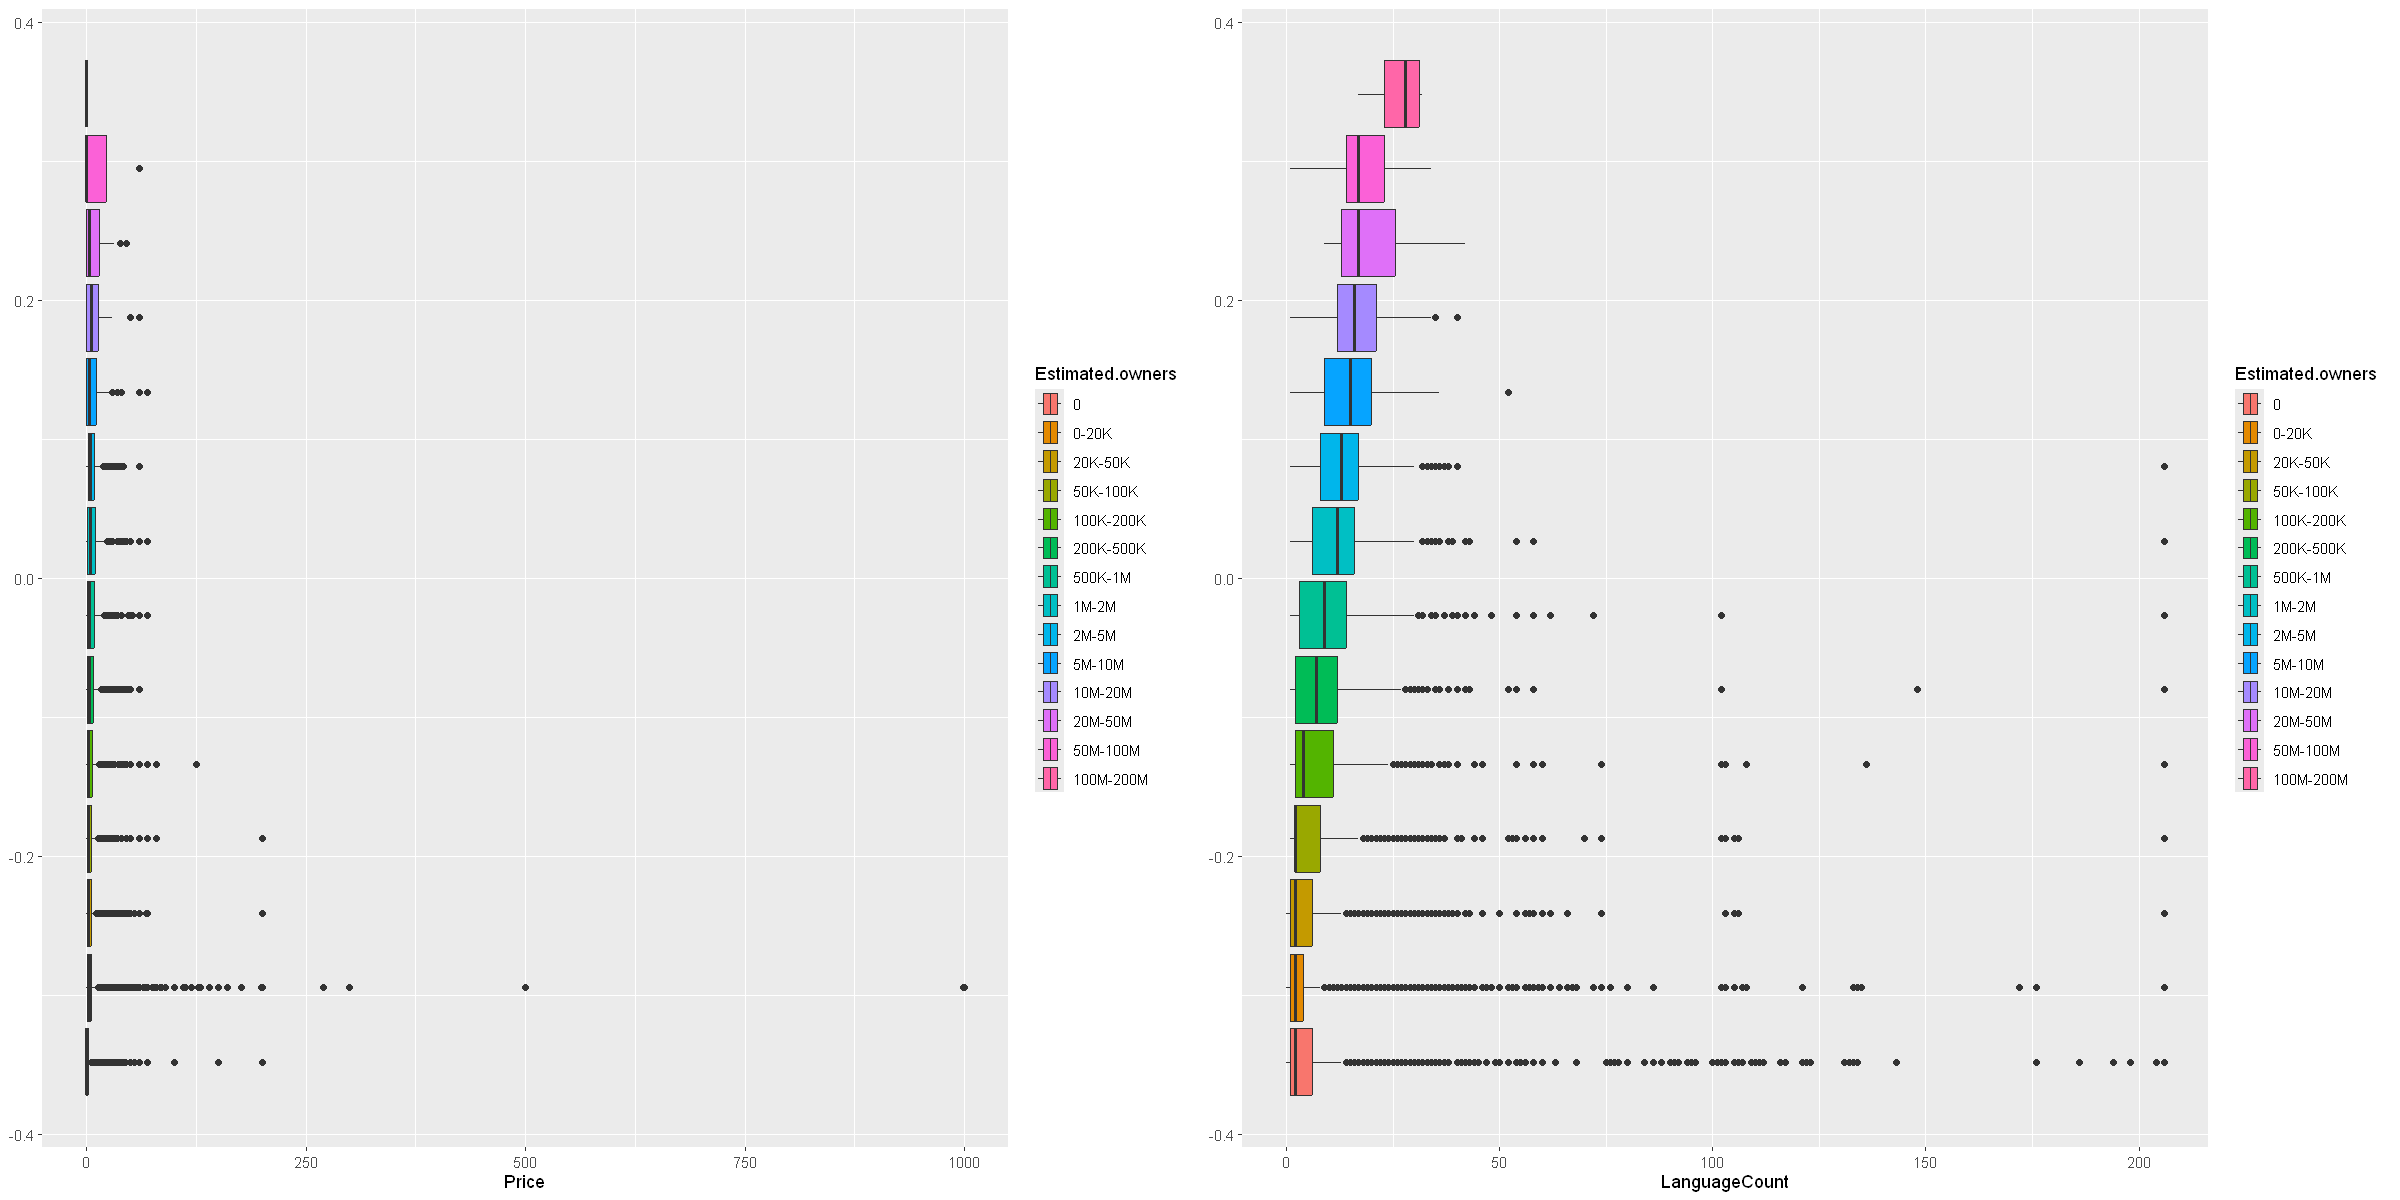

In [56]:
gg1=ggplot(data_ready, aes(x = Price, fill =Estimated.owners)) + geom_boxplot()
gg2=ggplot(data_ready, aes(x = LanguageCount, fill =Estimated.owners)) + geom_boxplot()
grid.arrange(gg1,gg2,ncol=2)

In [58]:
data_mfa <- data_ready %>%
  select(Price, LanguageCount, Estimated.owners, Genres)

Transformation des données: encodage des variables qualitatives.

In [65]:
# On encode les genres en modalités avec 0 et 1
data_mfa <- dummy_cols(data_mfa, 
                            select_columns = "Genres", 
                            split = ",", 
                            remove_selected_columns = TRUE)

ERROR: Error in dummy_cols(data_mfa, select_columns = "Genres", split = ",", : select_columns is/are not in data. Please check data and spelling.


In [70]:
head(data_mfa)

,Price,LanguageCount,Estimated.owners,Genres_Accounting,Genres_Animation & Modeling,Genres_Audio Production,Genres_Design & Illustration,Genres_Education,Genres_Photo Editing,Genres_Software Training,⋯,Genres_Movie,Genres_Documentary,Genres_Episodic,Genres_Short,Genres_Tutorial,Genres_360 Video,Genres_Gore,Genres_Nudity,Genres_Violent,Genres_Sexual Content
,<dbl>,<dbl>,<fct>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,14.99,1,0-20K,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
2,2.99,1,50K-100K,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
3,19.99,6,0-20K,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
4,1.79,13,100K-200K,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
5,0.99,1,20K-50K,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
6,1.99,2,0-20K,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


In [63]:
inf_check <- sapply(data_mfa, function(x) if(is.numeric(x)) any(is.infinite(x)) else FALSE)
if(any(inf_check)) {
  print(paste("Colonnes avec des valeurs infinies :", names(inf_check)[inf_check]))
}

In [64]:
# 3. Vérification des colonnes constantes (Zéro variance)
const_check <- sapply(data_mfa, function(x) if(is.numeric(x)) var(x, na.rm=TRUE) == 0 else FALSE)
if(any(const_check)) {
  print(paste("Colonnes sans aucune variation :", names(const_check)[const_check]))
}

MFA: **J'ai une erreur quand je ne met pas les Genres en supplémentaires**

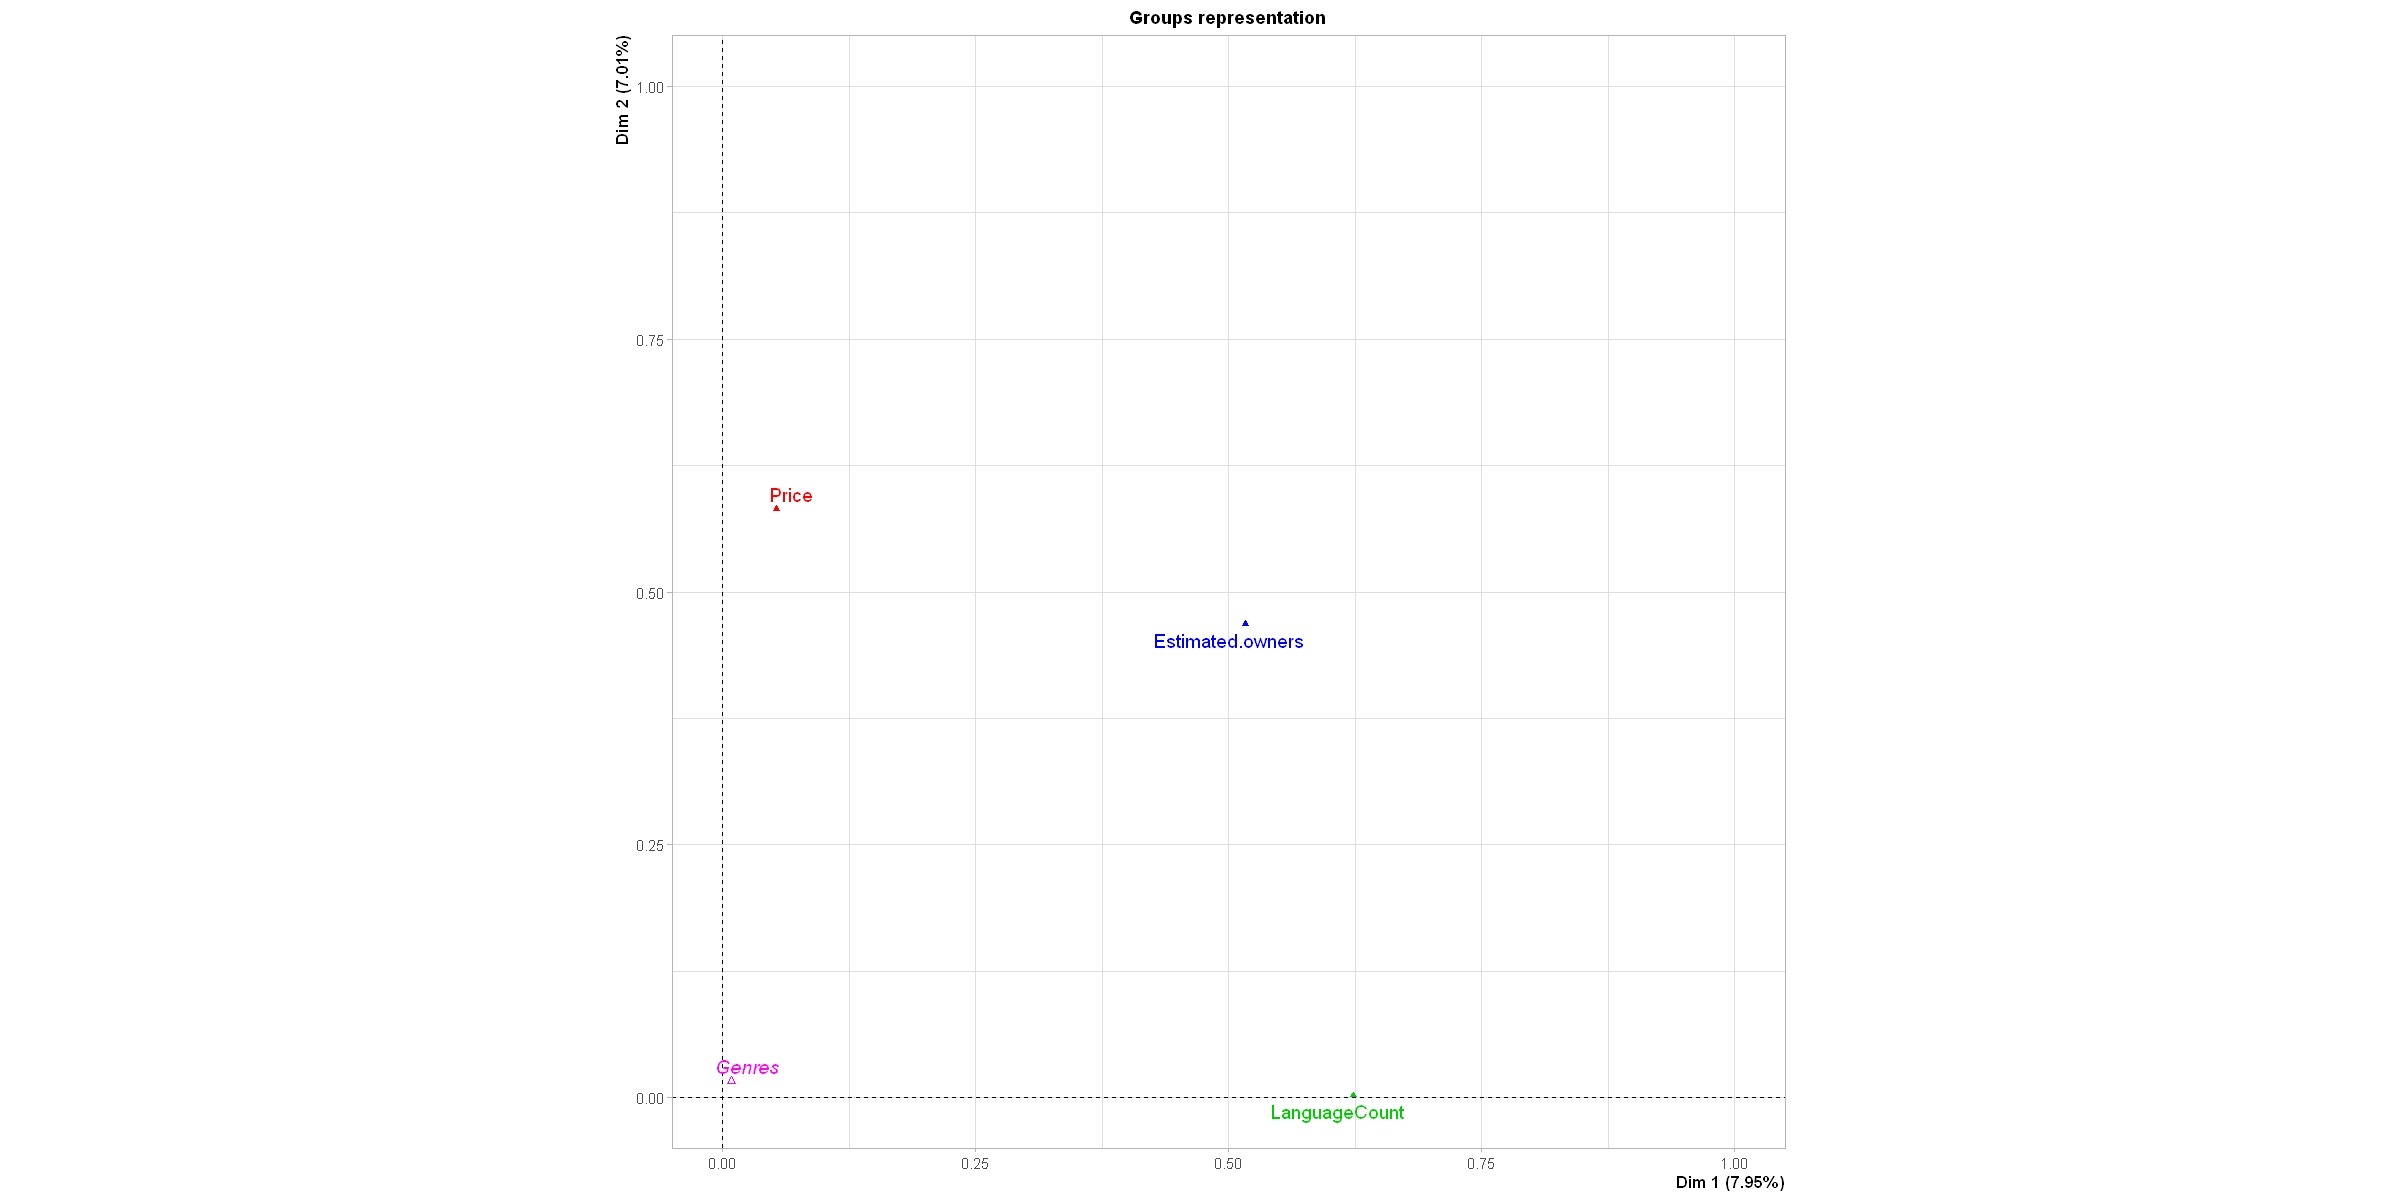

In [71]:
res.mfa <- MFA(data_mfa, 
               group = c(1, 1, 1, 33), 
               type = c("s", "s", "n", "f"), # 'n' pour la popularité, 'f' pour les dummies de genres, "s" pour centrer et reduire
               name.group = c("Price", "LanguageCount", "Estimated.owners", "Genres"),
               num.group.sup = 4,
               graph = FALSE)

# Analyse des résultats
plot(res.mfa, choix = "group") # Pour voir quel groupe influence le plus les axes

In [72]:
res.mfa$eig

,eigenvalue,percentage of variance,cumulative percentage of variance
comp 1,1.1919936,7.946624,7.946624
comp 2,1.0521531,7.014354,14.960978
comp 3,1.0000000,6.666667,21.627645
comp 4,1.0000000,6.666667,28.294311
comp 5,1.0000000,6.666667,34.960978
comp 6,1.0000000,6.666667,41.627645
comp 7,1.0000000,6.666667,48.294311
comp 8,1.0000000,6.666667,54.960978
comp 9,1.0000000,6.666667,61.627645
comp 10,1.0000000,6.666667,68.294311


Qualité de représentation des groupes:

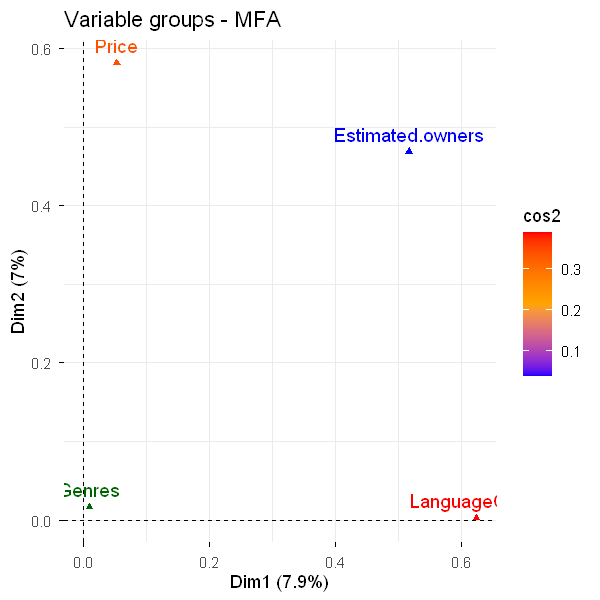

In [100]:
options(repr.plot.width = 5, repr.plot.height =5)
fviz_mfa_var(res.mfa, "group", col.var = "cos2", gradient.cols = c("blue", "orange", "red"))

Contribution aux axes des groupes: 

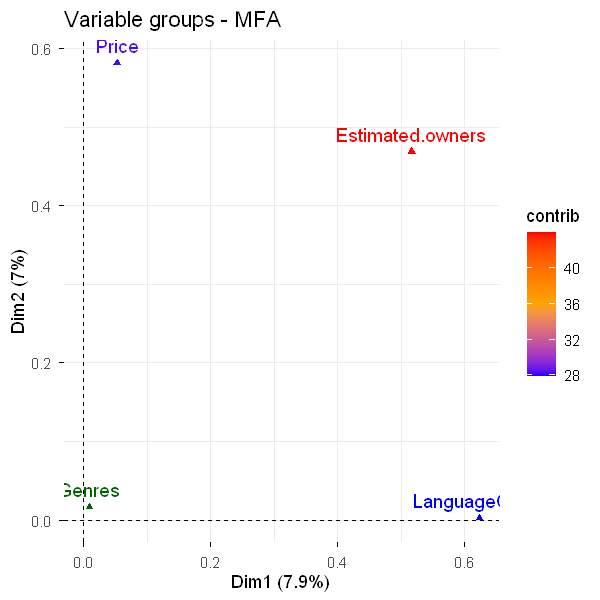

In [97]:
fviz_mfa_var(res.mfa, "group", col.var = "contrib", gradient.cols = c("blue", "orange", "red"))

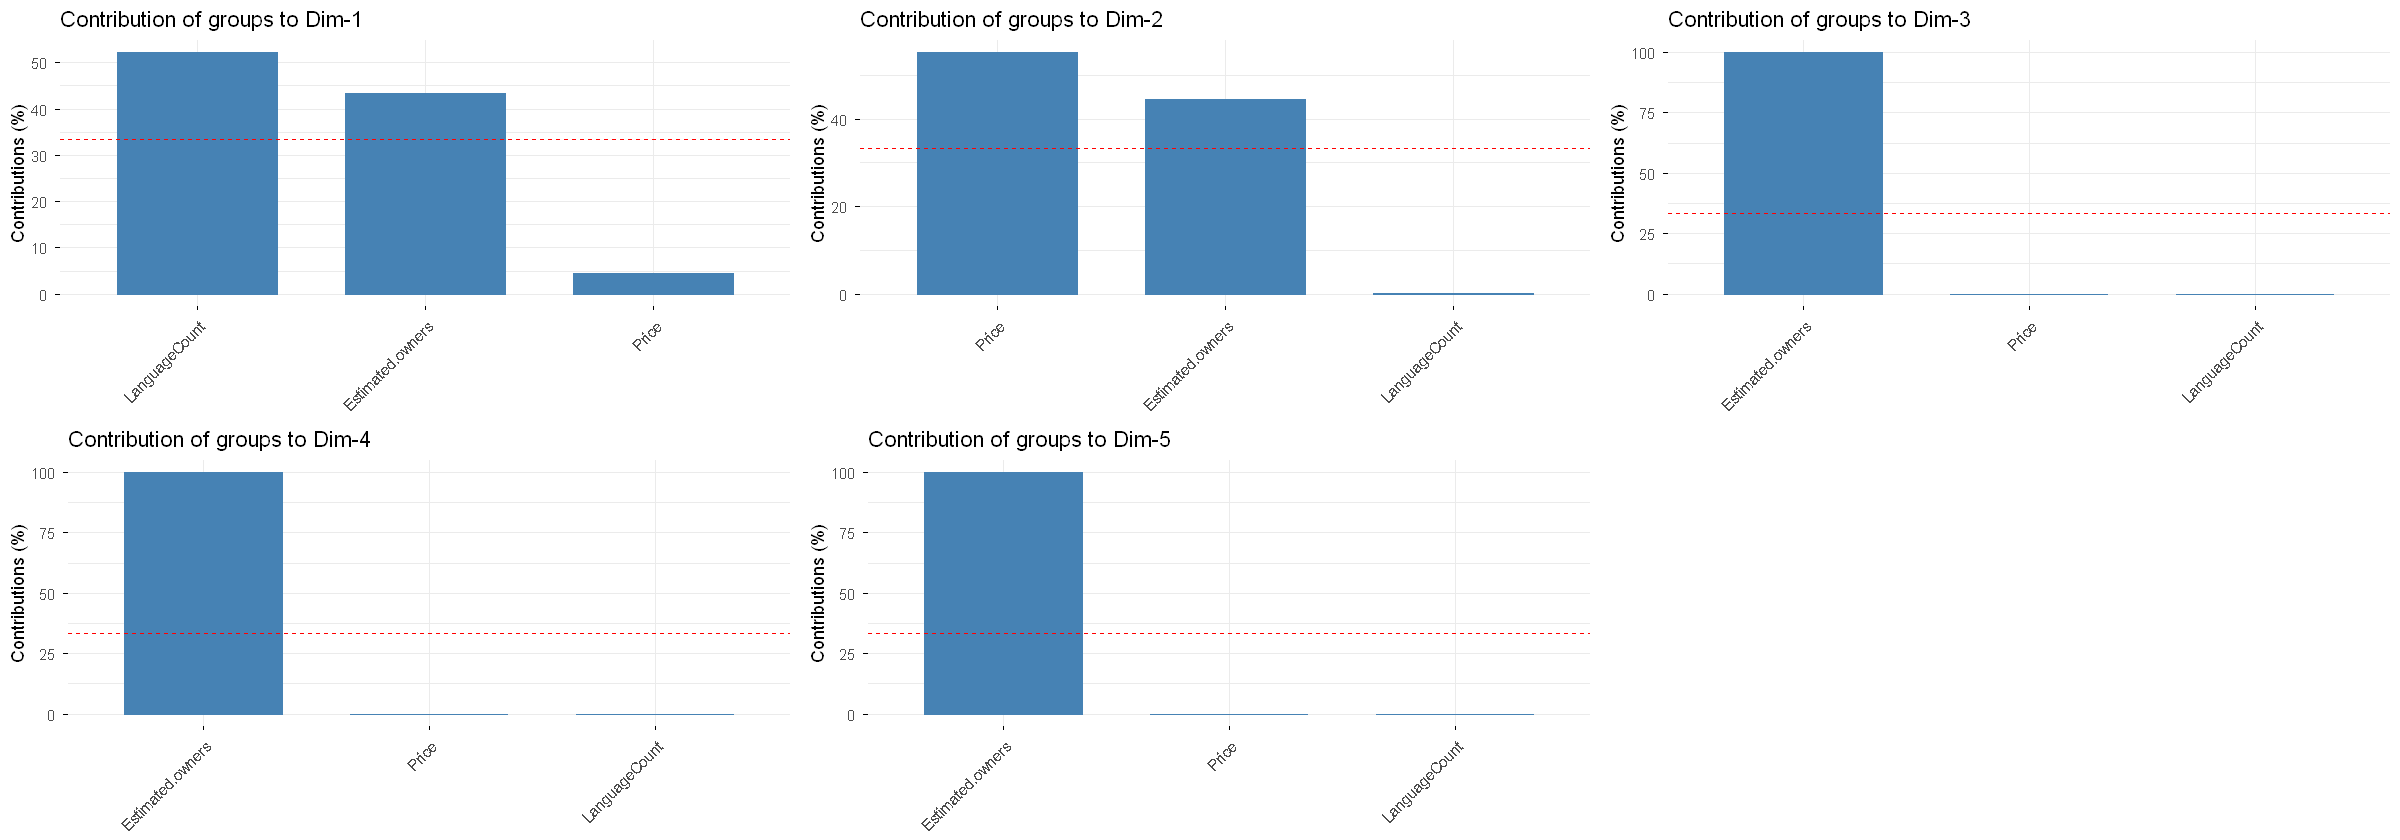

In [92]:
options(repr.plot.width = 20, repr.plot.height = 7)
p1 <- fviz_contrib(res.mfa, choice = "group", axes = 1)
p2 <- fviz_contrib(res.mfa, choice = "group", axes = 2)
p3 <- fviz_contrib(res.mfa, choice = "group", axes = 3)
p4 <- fviz_contrib(res.mfa, choice = "group", axes = 4)
p5 <- fviz_contrib(res.mfa, choice = "group", axes = 5)
grid.arrange(p1, p2, p3,p4,p5,ncol = 3)

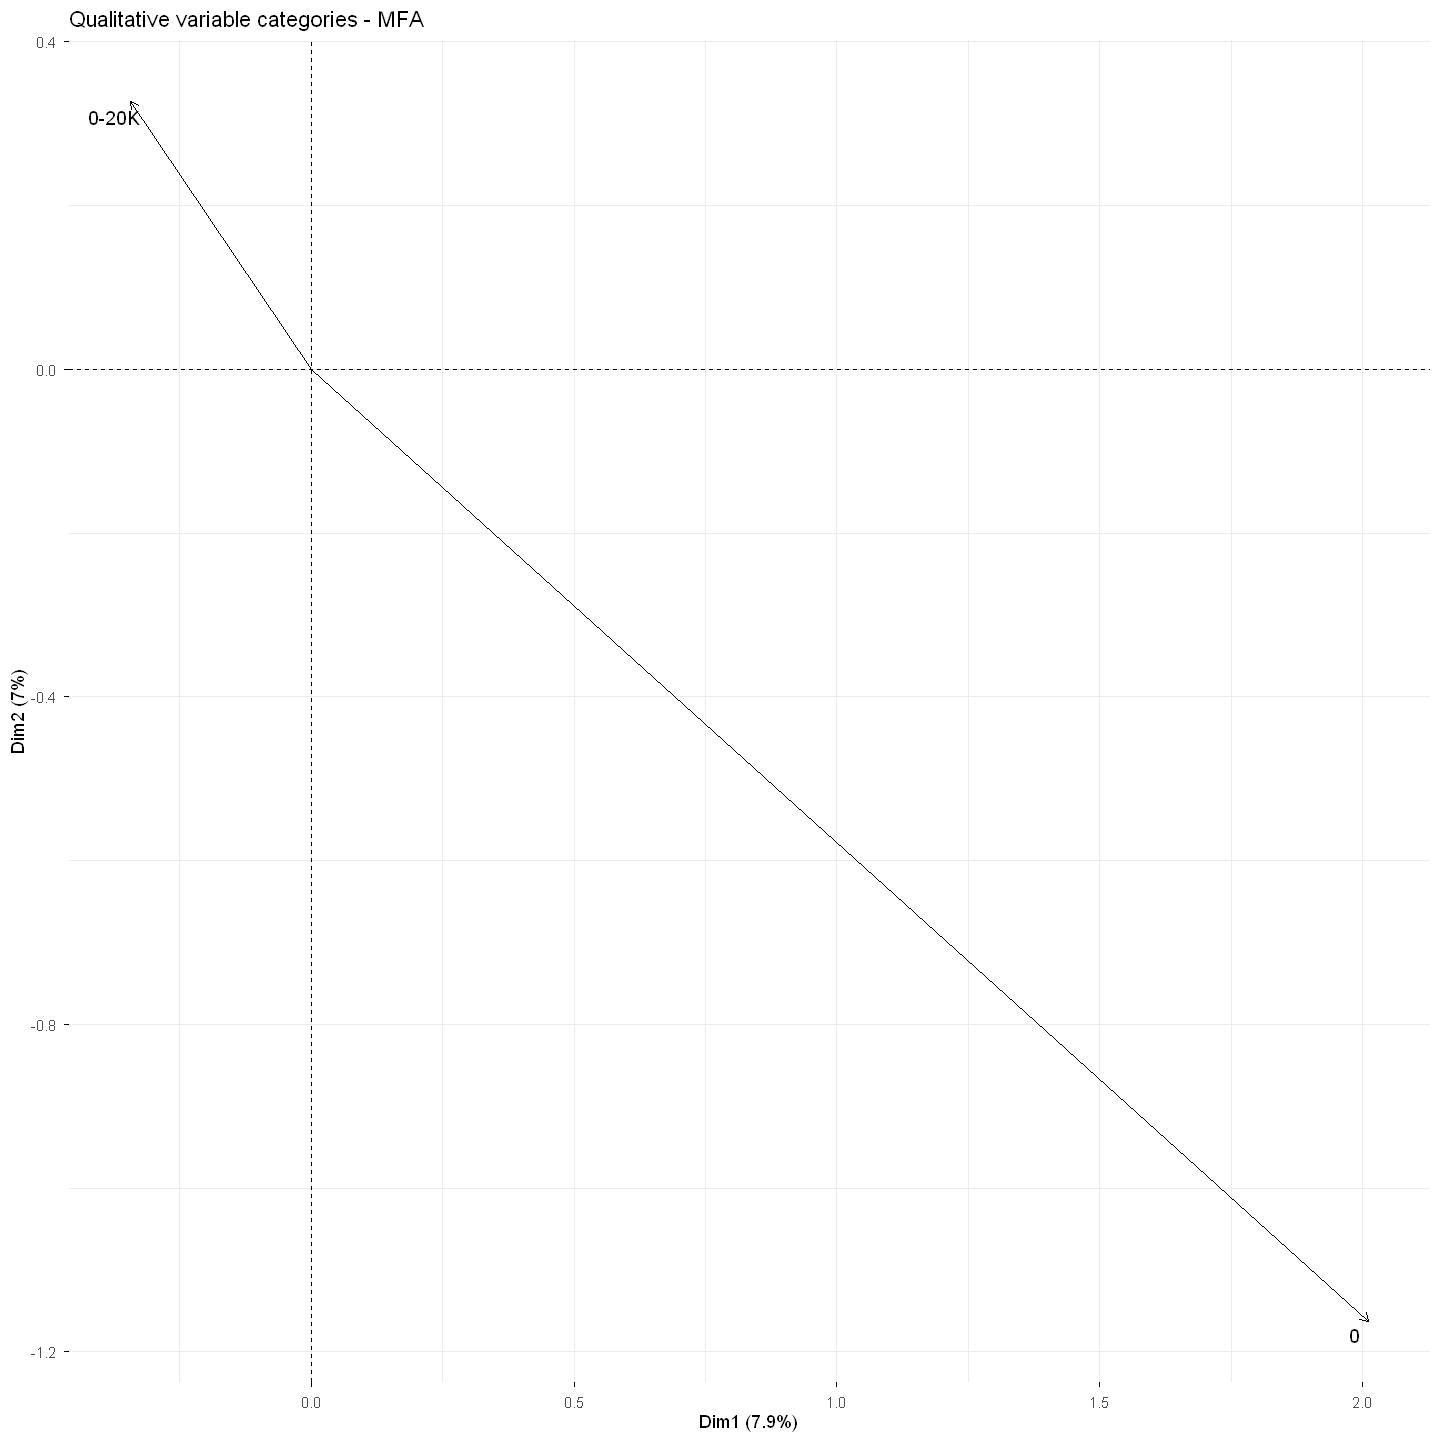

In [105]:
fviz_mfa_var(res.mfa, "quali.var", 
             geom = c("arrow", "text"),
             # On ne met pas de couleur par groupe pour tester si c'est ça qui bloque
             col.var = "black", 
             select.var = list(cos2 = 0.2),
             repel = TRUE)

Warning message:
"This manual palette can handle a maximum of 10 values. You have supplied 14"
Warning message:
"Removed 94 rows containing missing values or values outside the scale range (`geom_point()`)."
Warning message:
"Removed 4 rows containing missing values or values outside the scale range (`geom_point()`)."


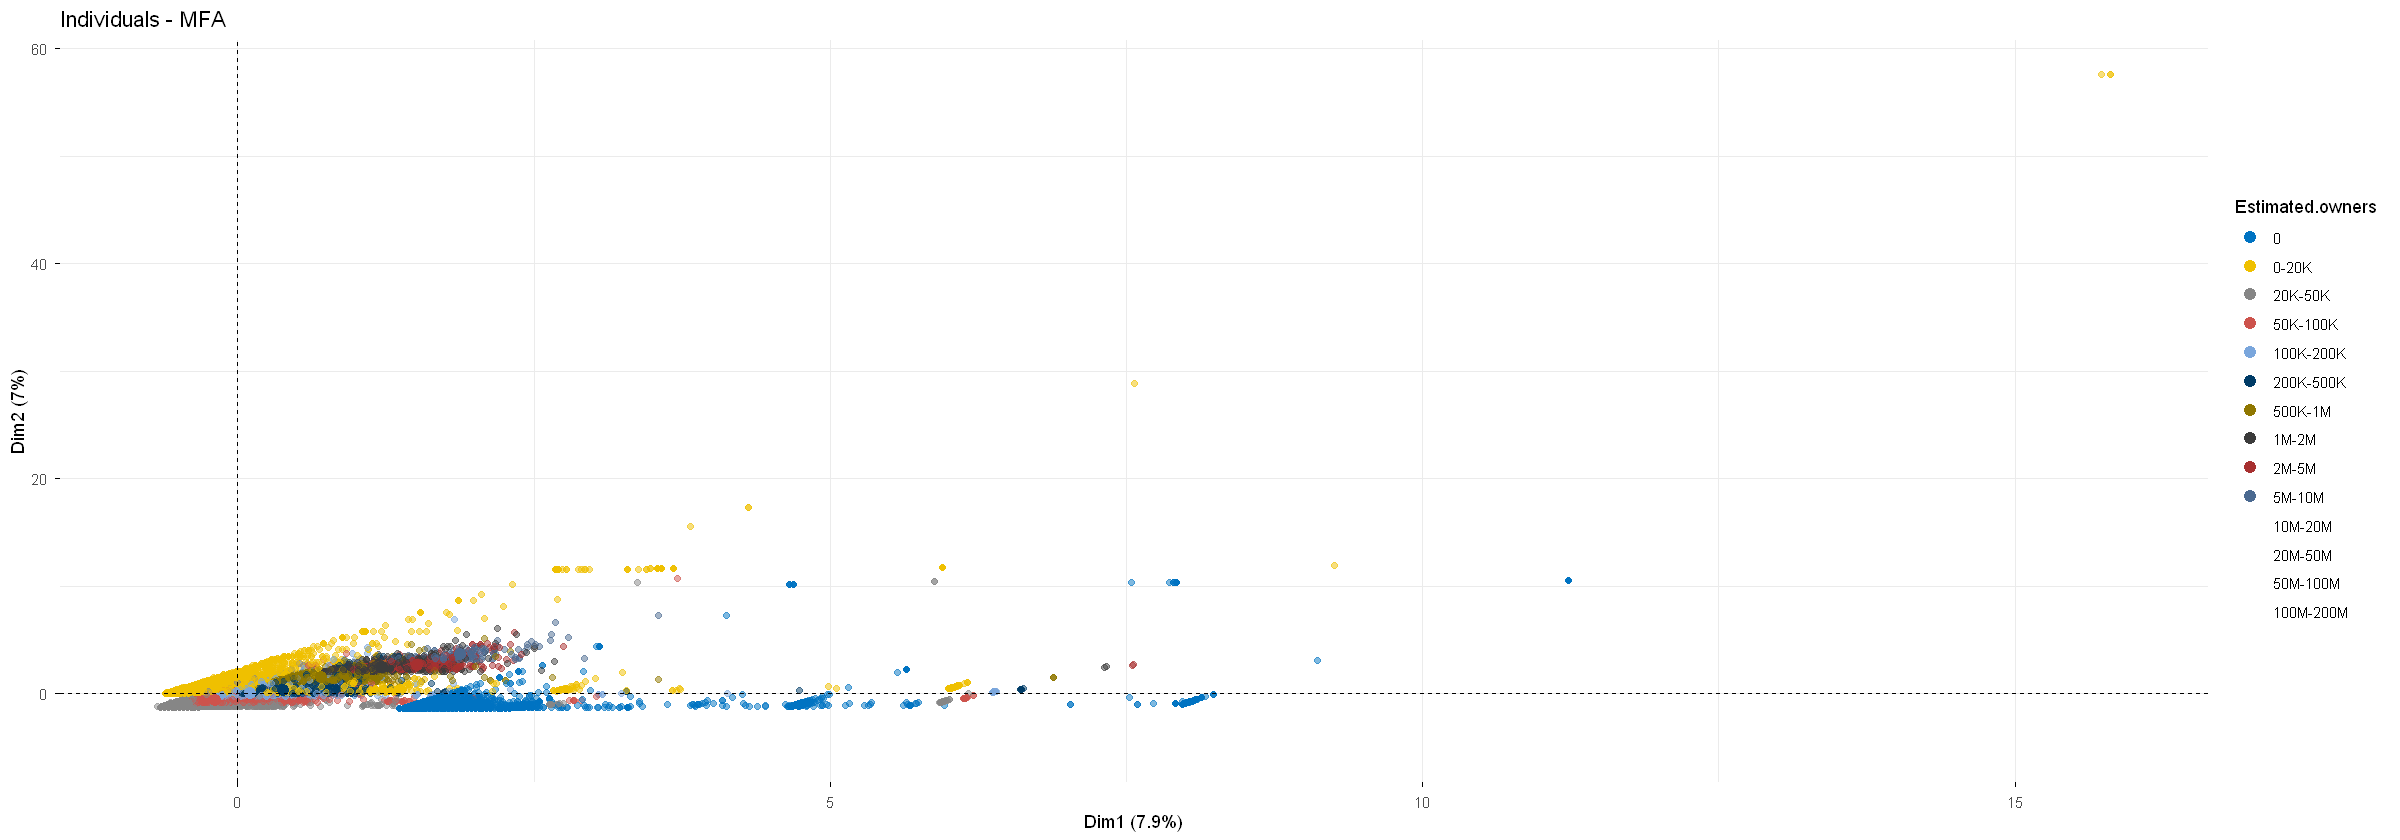

In [94]:
# Affichage simple des individus colorés par le groupe 'Succès' (Estimated.owners)
fviz_mfa_ind(res.mfa, 
             habillage = "Estimated.owners", # Nom de la variable pour colorer
             label = "none",                 # On cache les noms des 122k jeux pour y voir clair
             alpha.ind = 0.5,                # Transparence pour voir la densité
             palette = "jco")

Pour clustering peut-être que de considérere tout les individus c'est trop => on peut simplement garder les individus qui ont plus de 50K d'utilisateurs, et on s'attend a avoir des clusters de jeux qui ont moyennement marché, bien marché et puis le top des jeux

# Etude des jeux avec plus de 20K d'utilisateurs estimés

Le but va être de faire du clustering et voir si se distingue des classes correspondant aux tranches d'utilisateurs.

In [25]:
summary(data_ready$Estimated.owners)

0     0-20K   20K-50K  50K-100K 100K-200K 200K-500K   500K-1M     1M-2M 
    13649     75337     11395      5349      3450      2845      1150       720 
    2M-5M    5M-10M   10M-20M   20M-50M  50M-100M 100M-200M 
      400       124        50        31         9         4

In [158]:
data.pop <- data_ready %>% filter(!(Estimated.owners %in% c("0", "0-20K","20K-50K")))
#"20K-50K"

In [27]:
dim(data.pop)

[1] 14132    28

## Variables quantitatives

In [159]:
data.pop.quanti = data.pop %>% select(where(is.numeric))

In [160]:
summary(data.pop.quanti)

    Discount      Metacritic.score   User.score        Achievements    
 Min.   :  0.00   Min.   : 0.00    Min.   : 0.00000   Min.   :   0.00  
 1st Qu.:  0.00   1st Qu.: 0.00    1st Qu.: 0.00000   1st Qu.:   0.00  
 Median : 33.50   Median : 0.00    Median : 0.00000   Median :  18.00  
 Mean   : 35.48   Mean   :16.36    Mean   : 0.01521   Mean   :  39.92  
 3rd Qu.: 70.00   3rd Qu.: 0.00    3rd Qu.: 0.00000   3rd Qu.:  39.00  
 Max.   :100.00   Max.   :97.00    Max.   :77.00000   Max.   :9821.00  
 Average.playtime.two.weeks Median.playtime.two.weeks   LPositive     
 Min.   :    0.00           Min.   :    0             Min.   : 0.000  
 1st Qu.:    0.00           1st Qu.:    0             1st Qu.: 5.081  
 Median :    0.00           Median :    0             Median : 6.562  
 Mean   :   96.48           Mean   :  104             Mean   : 6.388  
 3rd Qu.:    0.00           3rd Qu.:    0             3rd Qu.: 7.901  
 Max.   :20088.00           Max.   :20088             Max.   :15.849  

### PCA

Warning message in geom_bar(stat = "identity", fill = barfill, color = barcolor, :
"Ignoring empty aesthetic: `width`."


,eigenvalue,percentage of variance,cumulative percentage of variance
comp 1,5.49662603,36.6441735,36.64417
comp 2,1.94036576,12.9357717,49.57995
comp 3,1.04676904,6.9784602,56.55841
comp 4,1.01495978,6.7663985,63.32480
comp 5,0.99479780,6.6319853,69.95679
comp 6,0.96289639,6.4193093,76.37610
comp 7,0.89811559,5.9874373,82.36354
comp 8,0.76048622,5.0699081,87.43344
comp 9,0.72189584,4.8126389,92.24608
comp 10,0.53214547,3.5476365,95.79372


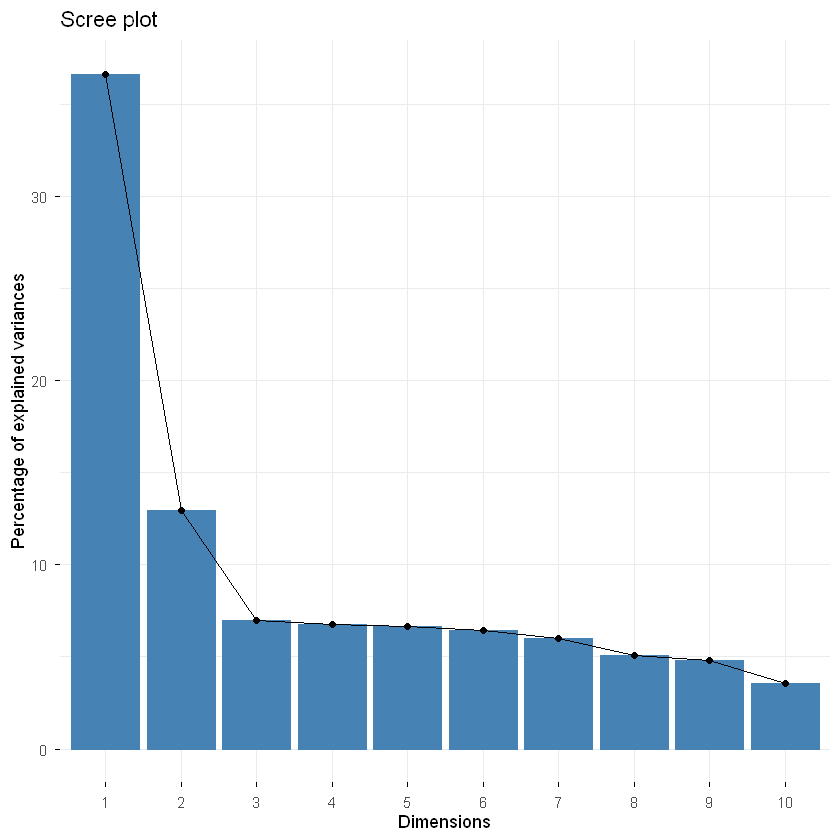

In [35]:
pca.pop <- PCA(data.pop.quanti,ncp = ncol(data.pop.quanti), scale.unit = TRUE, graph = FALSE)
fviz_eig(pca.pop)
pca.pop$eig

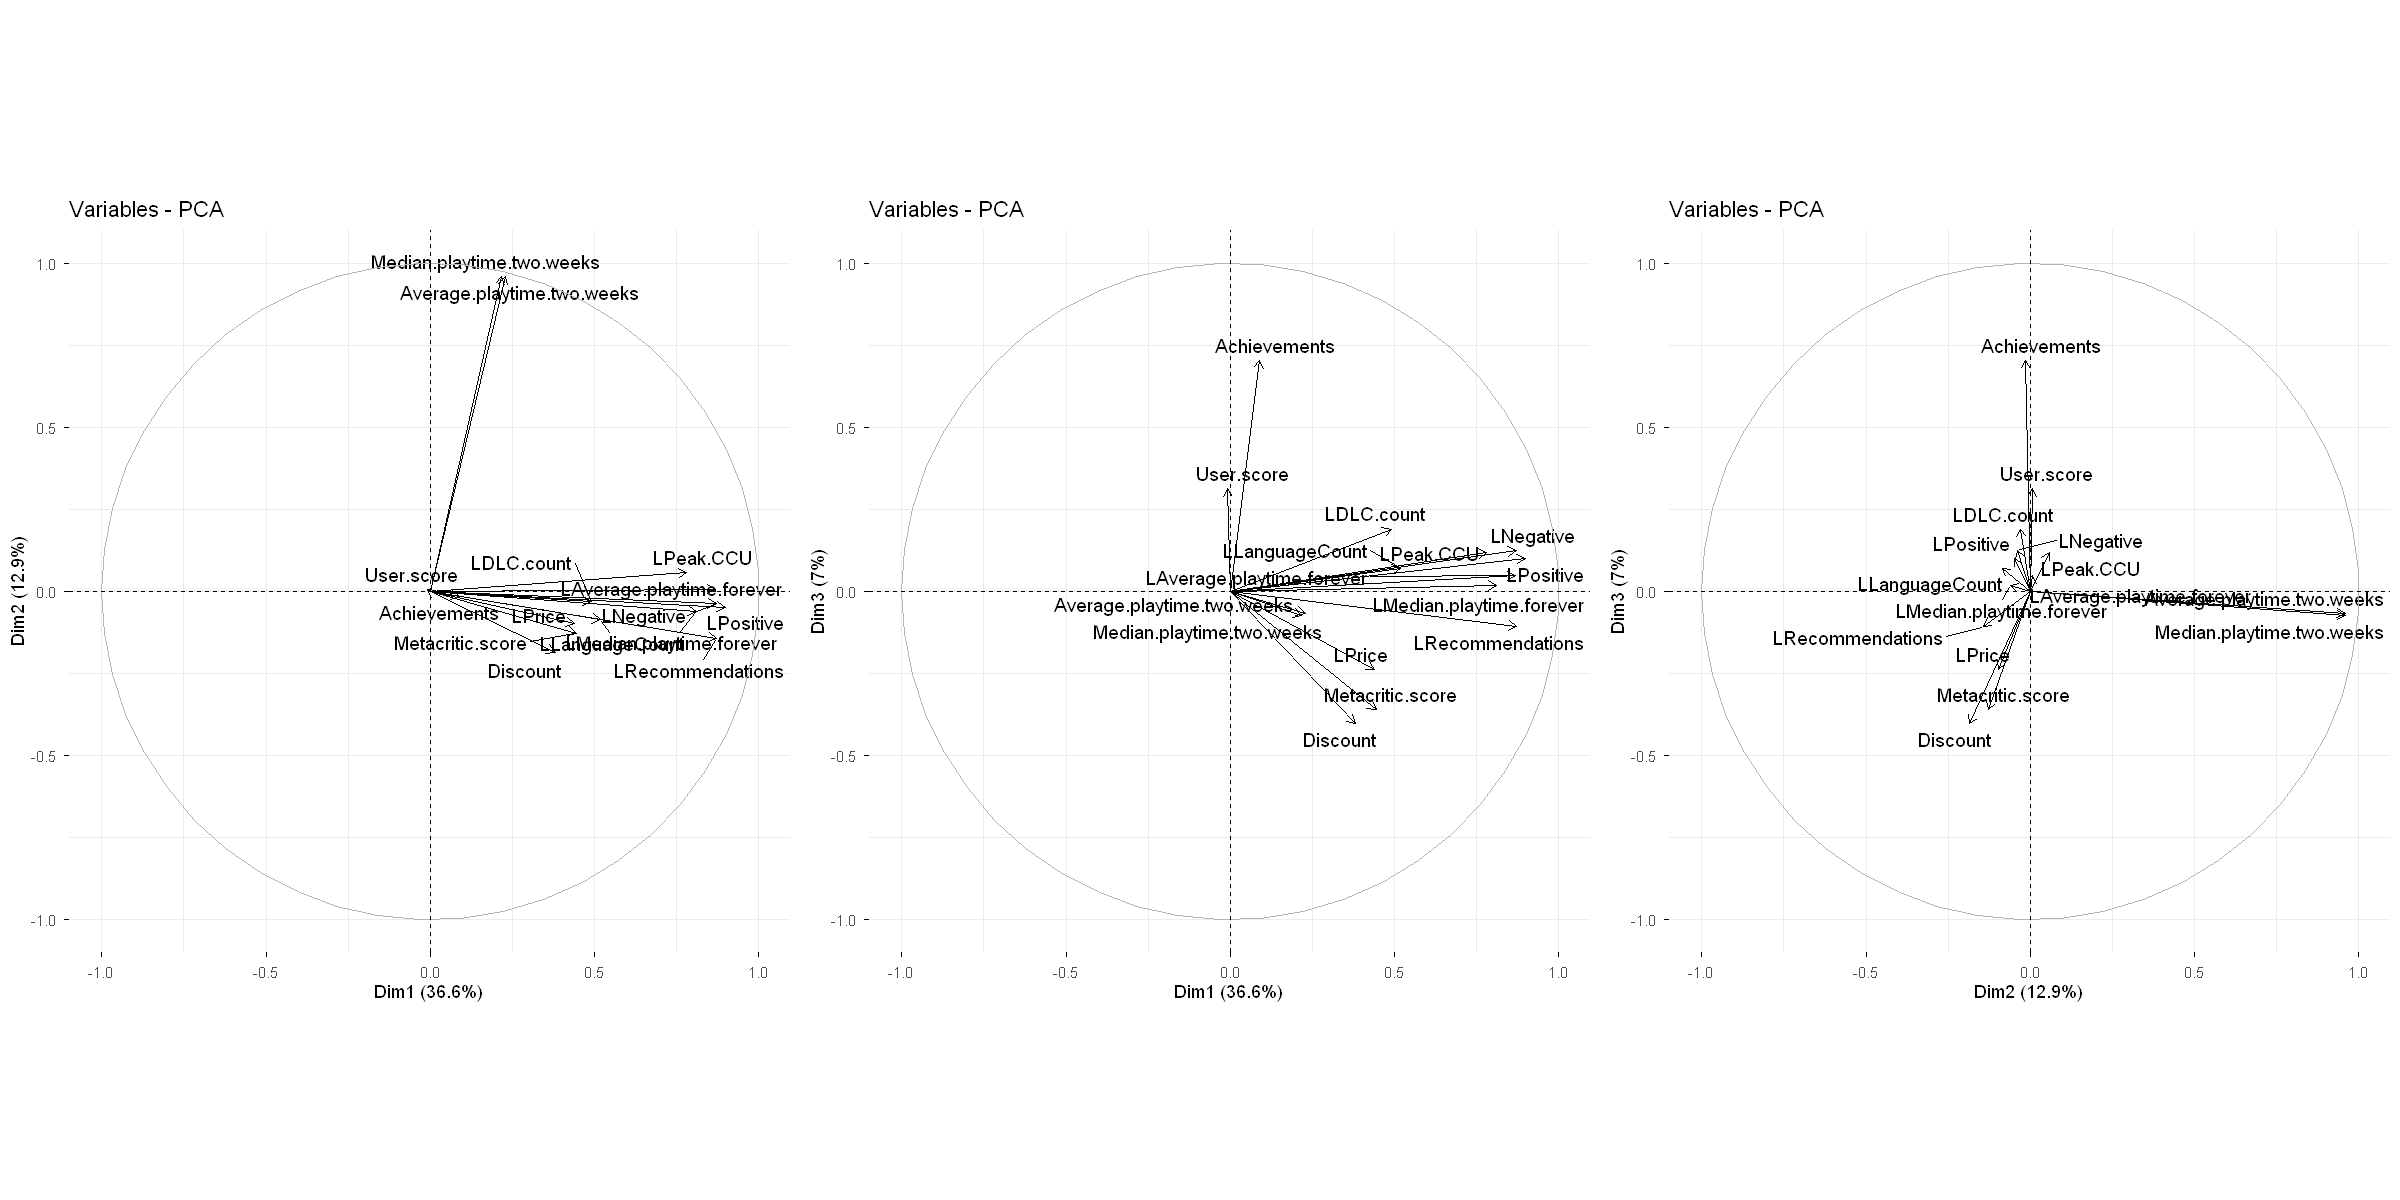

In [113]:
options(repr.plot.width = 20, repr.plot.height = 10)
g1=fviz_pca_var(pca.pop,axes = c(1,2),repel=TRUE)
g2=fviz_pca_var(pca.pop,axes = c(1,3),repel=TRUE)
g8=fviz_pca_var(pca.pop,axes = c(2,3),repel=TRUE)
grid.arrange(g1,g2,g8,ncol=3)

### K-means

In [161]:
data.pop.scale <- scale(data.pop.quanti) #Pour que chaque variable ait le même poids car elles ont des valeurs très differentes
# sans normalisation on obtient des clusters très désiquilibrés en termes d'effectif

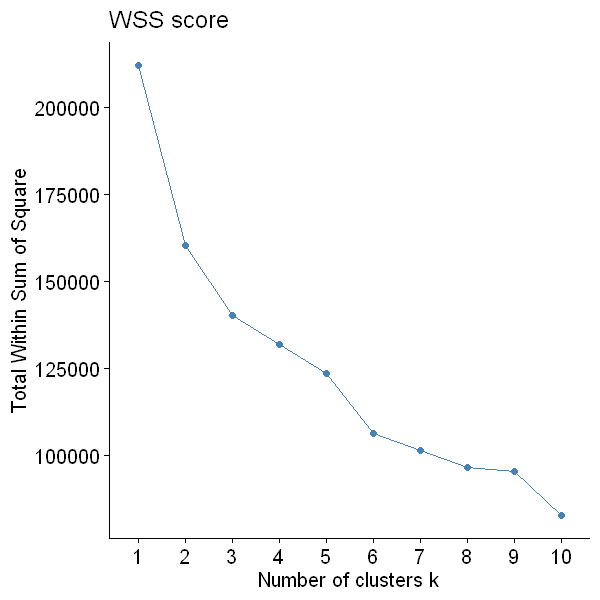

In [60]:
options(repr.plot.width = 5, repr.plot.height =5)
p1 = fviz_nbclust(data.pop.scale, FUNcluster=stats::kmeans, method="wss",k.max = 10) + ggtitle("WSS score")
p1

In [ ]:
Deux nombres de clusters plausibles avec la méthode du coude: 3 et 6. On va vérifier avec le score silhouette.

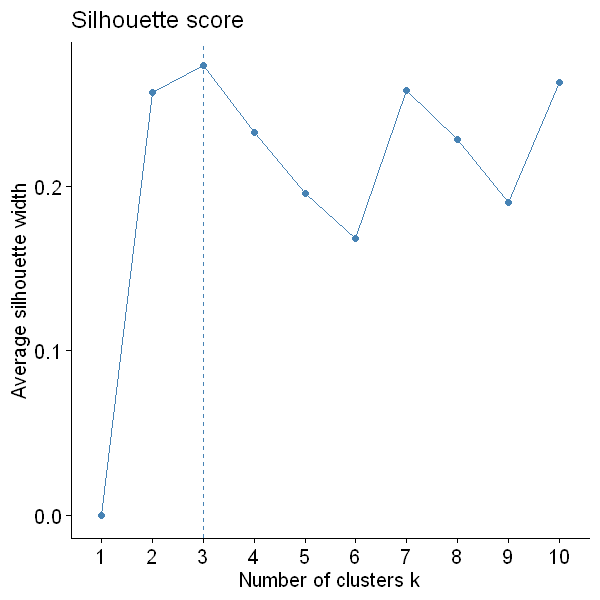

In [156]:
fviz_nbclust(data.pop.scale, FUNcluster=stats::kmeans, method="silhouette") + ggtitle("Silhouette score")

D'après ce critère on choisit donc K=3, cela signifie que les clusters sont mieux séparés.

In [162]:
kmeans3 = kmeans(data.pop.scale, centers=3)
cluster_counts_3 = data.frame(table(kmeans3$cluster))
cluster_counts_3

Var1,Freq
<fct>,<int>
1,7210
2,3039
3,3883


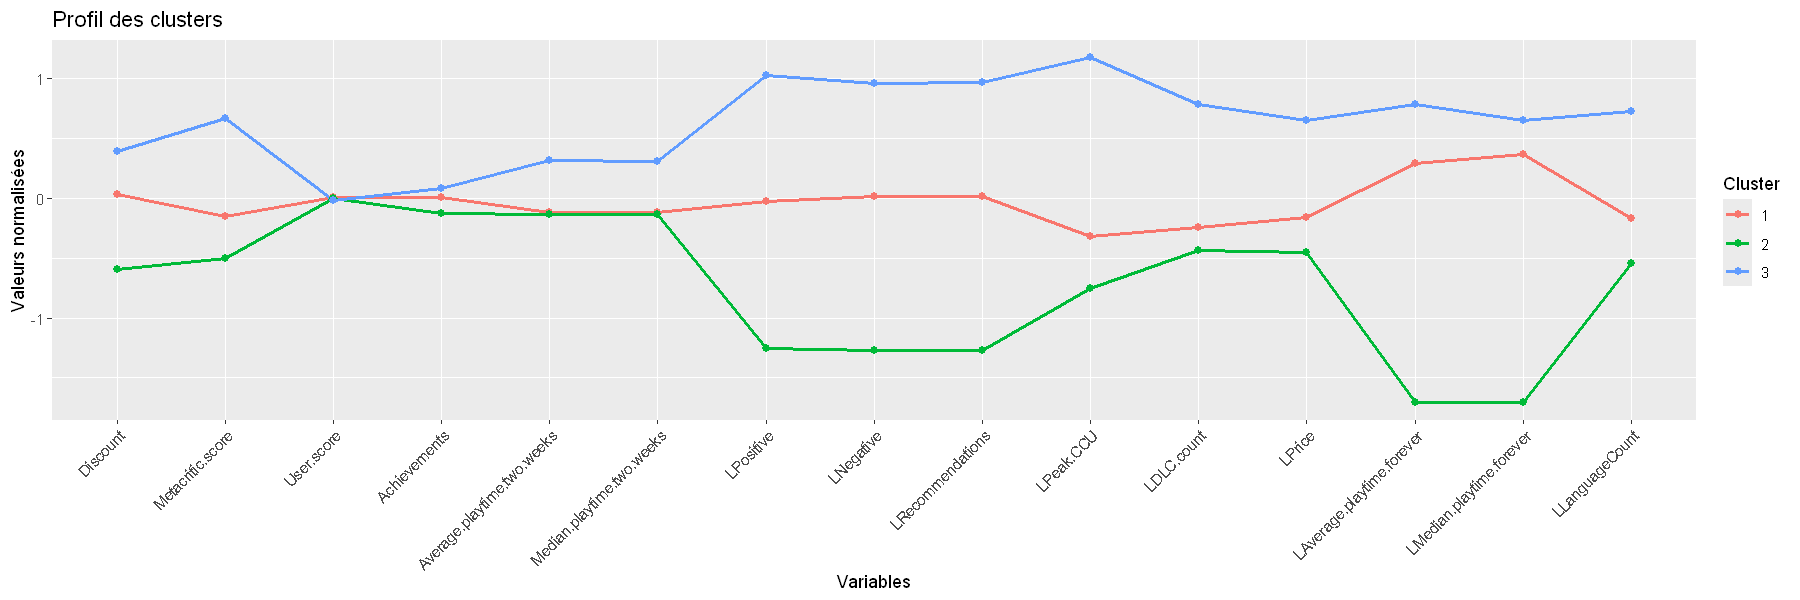

In [163]:
# mean profiles pour K=3
options(repr.plot.width = 15, repr.plot.height =5)
mean_profile = aggregate(data.pop.scale, by = list(cluster = kmeans3$cluster), FUN = mean)
plot_data <- melt(mean_profile, id.vars = "cluster")

ggplot(plot_data, aes(x = variable, y = value, color = factor(cluster), group = cluster)) +
  geom_line(linewidth = 1) +
  geom_point(size = 2) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  labs(title = "Profil des clusters",
       x = "Variables",
       y = "Valeurs normalisées",
       color = "Cluster")

Affichage sur l'espace des individus de la PCA

Ignoring unknown labels:
• linetype : "Clusters"
Ignoring unknown labels:
• linetype : "Clusters"
Ignoring unknown labels:
• linetype : "Clusters"


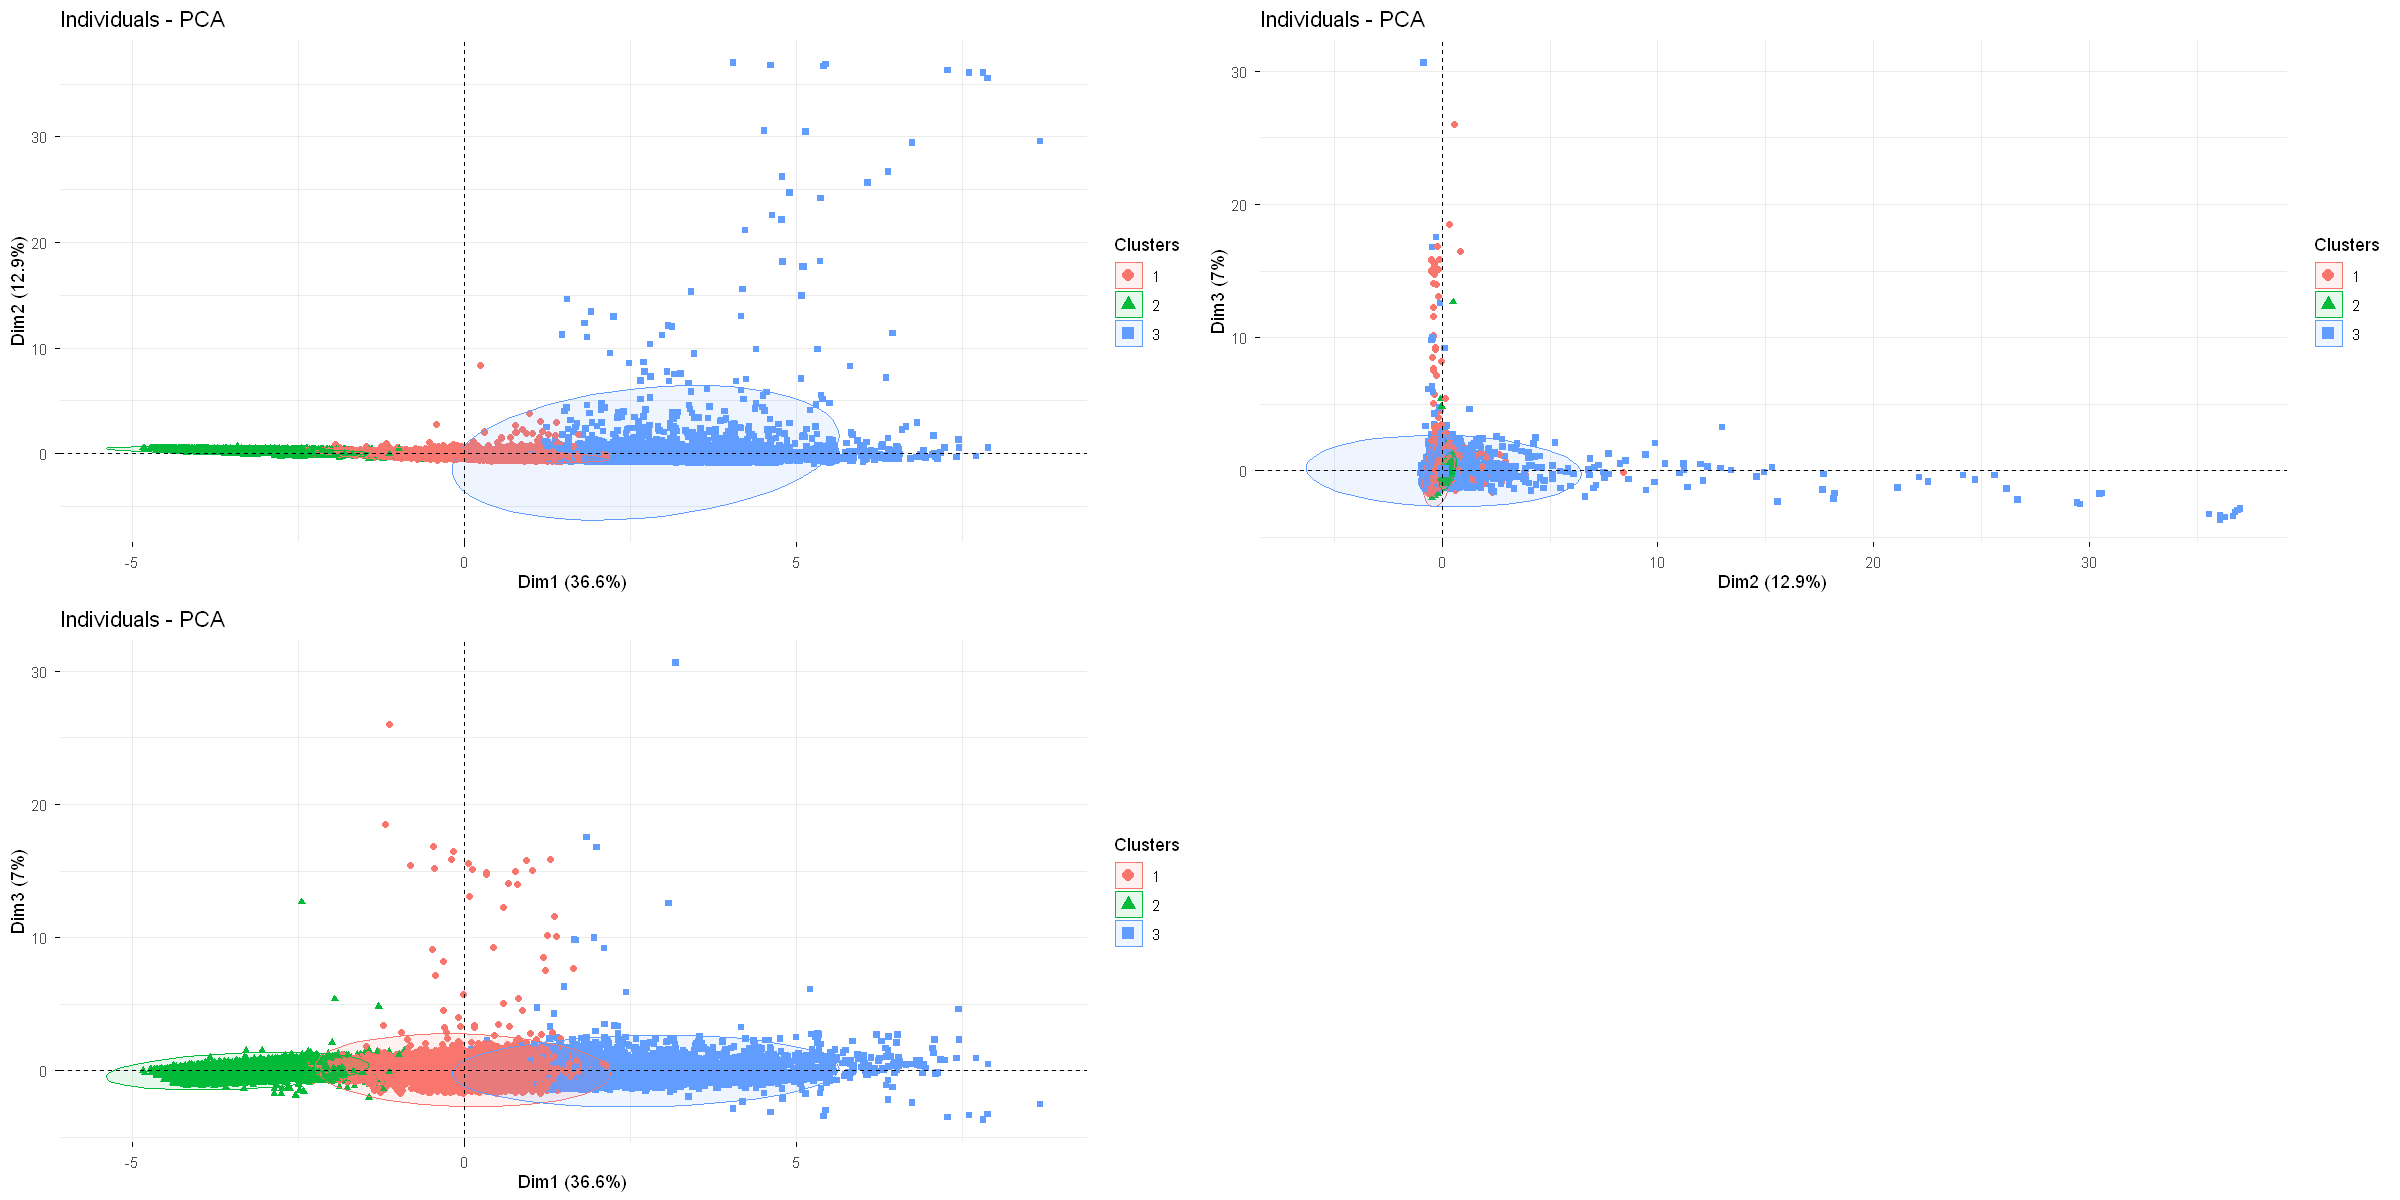

In [164]:
options(repr.plot.width = 20, repr.plot.height =10)

f1=fviz_pca_ind(pca.pop,
             geom.ind = "point",
             col.ind = factor(kmeans3$cluster),
             addEllipses = TRUE,
             legend.title = "Clusters")

f2=fviz_pca_ind(pca.pop,
             geom.ind = "point",
             col.ind = factor(kmeans3$cluster),
             addEllipses = TRUE,
             legend.title = "Clusters",
             axes=c(2,3))
f3=fviz_pca_ind(pca.pop,
             geom.ind = "point",
             col.ind = factor(kmeans3$cluster),
             addEllipses = TRUE,
             legend.title = "Clusters",
             axes=c(1,3))

grid.arrange(f1,f2,f3,ncol=2)

Avec l'ACP , on a vu en examinant le cercle des corrélations que l'axe 1 est porté par des variables de succès et d'engagement massif telles que LPositive, LNegative, LRecommendations, LPeak.CCU ainsi que LAverage.playtime.forever. La projection des individus sur ce plan confirme la pertinence du clustering : on observe une graduation très nette le long de cet axe horizontal. Le Cluster 1 (en rouge) se positionne à l'extrême droite, regroupant les titres dont les valeurs pour ces indicateurs sont les plus élevées. À l'opposé, le Cluster 3 (en bleu) se situe à gauche de l'axe, correspondant aux jeux ayant des scores inférieurs à la moyenne. Le Cluster 2 (en vert) occupe une position centrale, représentant le cœur du catalogue avec des statistiques proches de la moyenne globale. Cette structure est d'ailleurs confirmée par le graphique des profils moyens, où le Cluster 1 domine systématiquement les variables d'engagement, tandis que le Cluster 3 reste en retrait.

In [198]:
data.pop$cluster_id_3 <- kmeans3$cluster
data.pop$cluster_id_3=as.factor(data.pop$cluster_id_3)

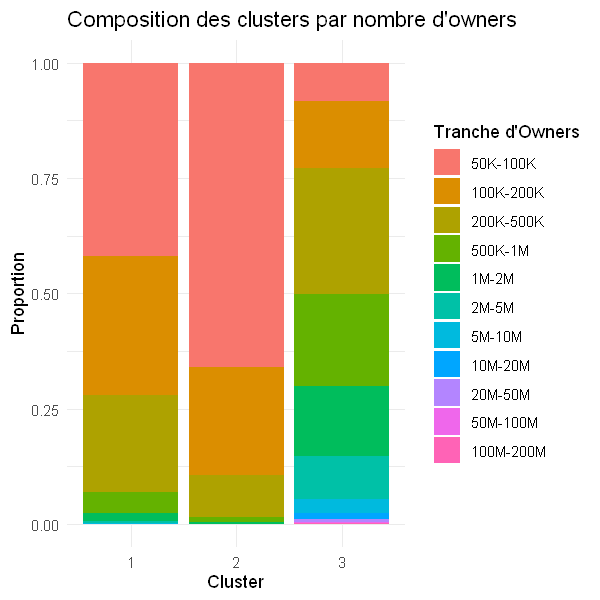

In [167]:
options(repr.plot.width = 5, repr.plot.height =5)
ggplot(data.pop, aes(x = factor(cluster_id_3), fill = Estimated.owners)) +
  geom_bar(position = "fill") +
  labs(title = "Composition des clusters par nombre d'owners",
       x = "Cluster",
       y = "Proportion",
       fill = "Tranche d'Owners") +
  theme_minimal()

On observe une hiérarchie de succès:

Cluster 1 : C'est le seul cluster qui contient des proportions significatives de jeux à plus de 1M d'owners (les couleurs bleues, violettes et roses en bas de la barre). C'est le cluster "Succès Confirmés & Blockbusters".

Cluster 2 : Il est dominé par les tranches 200K-500K et 500K-1M. Ce sont des jeux qui ont bien marché.

Cluster 3 : Il est composé à plus de 75% par les tranches 50K-100K et 100K-200K. Ce sont les jeux les "plus petits" de notre échantillon (rappelons qu'on a déja enlevé les jeux de moins de 50k).

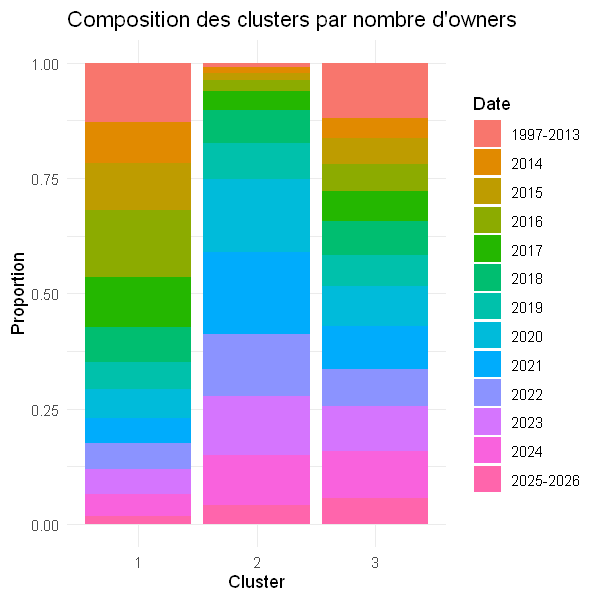

In [168]:
#Pour la date
ggplot(data.pop, aes(x = factor(cluster_id_3), fill = Release.date)) +
  geom_bar(position = "fill") +
  labs(title = "Composition des clusters par nombre d'owners",
       x = "Cluster",
       y = "Proportion",
       fill = "Date") +
  theme_minimal()

In [309]:
# Encodage du genre avec les groupes de jeux qu'on a trouvé

# On sépare les genres par la virgule
data.pop_genres <- data.pop %>%
  separate_rows(Genres, sep = ",") %>%
  mutate(presence = 1, Genres = paste0("Genres_", Genres)) %>%
  pivot_wider(names_from = Genres, values_from = presence, values_fill = 0)

data.pop_genres <- data.pop_genres %>%
  mutate(
    Genres_Mature = if_else(Genres_Gore == 1 | 
                           Genres_Nudity == 1 | 
                           `Genres_Sexual Content` == 1 | 
                           Genres_Violent == 1, 1, 0),

    #Pas besoin du Genre vidéo parce que dans data.pop il n'y avait qu'un jeu avec Movies et les autres genres de Genres_vidéo n'existait pas pour ce df
      
    Genres_Outils = if_else(`Genres_Video Production` == 1 | 
                           `Genres_Design & Illustration` == 1 | 
                           `Genres_Animation & Modeling` == 1 | 
                           `Genres_Game Development` == 1 | 
                           `Genres_Audio Production` == 1 | 
                           `Genres_Photo Editing` == 1 | 
                           `Genres_Software Training` == 1 | 
                           Genres_Education == 1 | 
                           Genres_Utilities == 1 | 
                           `Genres_Web Publishing` == 1, 1, 0)
  ) %>%
  mutate(across(starts_with("Genres_"), as.factor))

cols_to_remove <- c("Genres_Gore", "Genres_Violent", "Genres_Video Production","Genres_Sexual Content","Genres_Nudity",
                    "Genres_Design & Illustration", "Genres_Animation & Modeling","Genres_Game Development",
                    "Genres_Audio Production","Genres_Photo Editing", "Genres_Software Training",
                    "Genres_Education", "Genres_Utilities", "Genres_Web Publishing","Genres_Movie")

data.pop_genres <- data.pop_genres %>%
  select(-all_of(cols_to_remove))
summary(data.pop_genres)

     Name              Release.date   Estimated.owners  Required.age  
 Length:14132       1997-2013:1424   50K-100K :5349    0      :13369  
 Class :character   2016     :1361   100K-200K:3450    17     :  580  
 Mode  :character   2021     :1293   200K-500K:2845    13     :   95  
                    2020     :1284   500K-1M  :1150    18     :   49  
                    2017     :1149   1M-2M    : 720    16     :   21  
                    2023     :1149   2M-5M    : 400    10     :   10  
                    (Other)  :6472   (Other)  : 218    (Other):    8  
    Discount       Windows         Mac         Linux       Metacritic.score
 Min.   :  0.00   False:    2   False:9978   False:11307   Min.   : 0.00   
 1st Qu.:  0.00   True :14130   True :4154   True : 2825   1st Qu.: 0.00   
 Median : 33.50                                            Median : 0.00   
 Mean   : 35.48                                            Mean   :16.36   
 3rd Qu.: 70.00                                     

In [170]:
#affichage des genres les plus répendu dans ce df


cols_genres <- data.pop_genres[, grep("Genres_", names(data.pop_genres))]

sommes_genres <- sapply(cols_genres, function(x) sum(as.numeric(as.character(x)), na.rm = TRUE))


sort(sommes_genres, decreasing = TRUE)[1:10]

Genres_Indie                Genres_Action 
                        8970                         6513 
            Genres_Adventure                Genres_Casual 
                        5966                         3992 
                  Genres_RPG              Genres_Strategy 
                        3543                         3501 
           Genres_Simulation          Genres_Free To Play 
                        3101                         1671 
         Genres_Early Access Genres_Massively Multiplayer 
                         931                          608

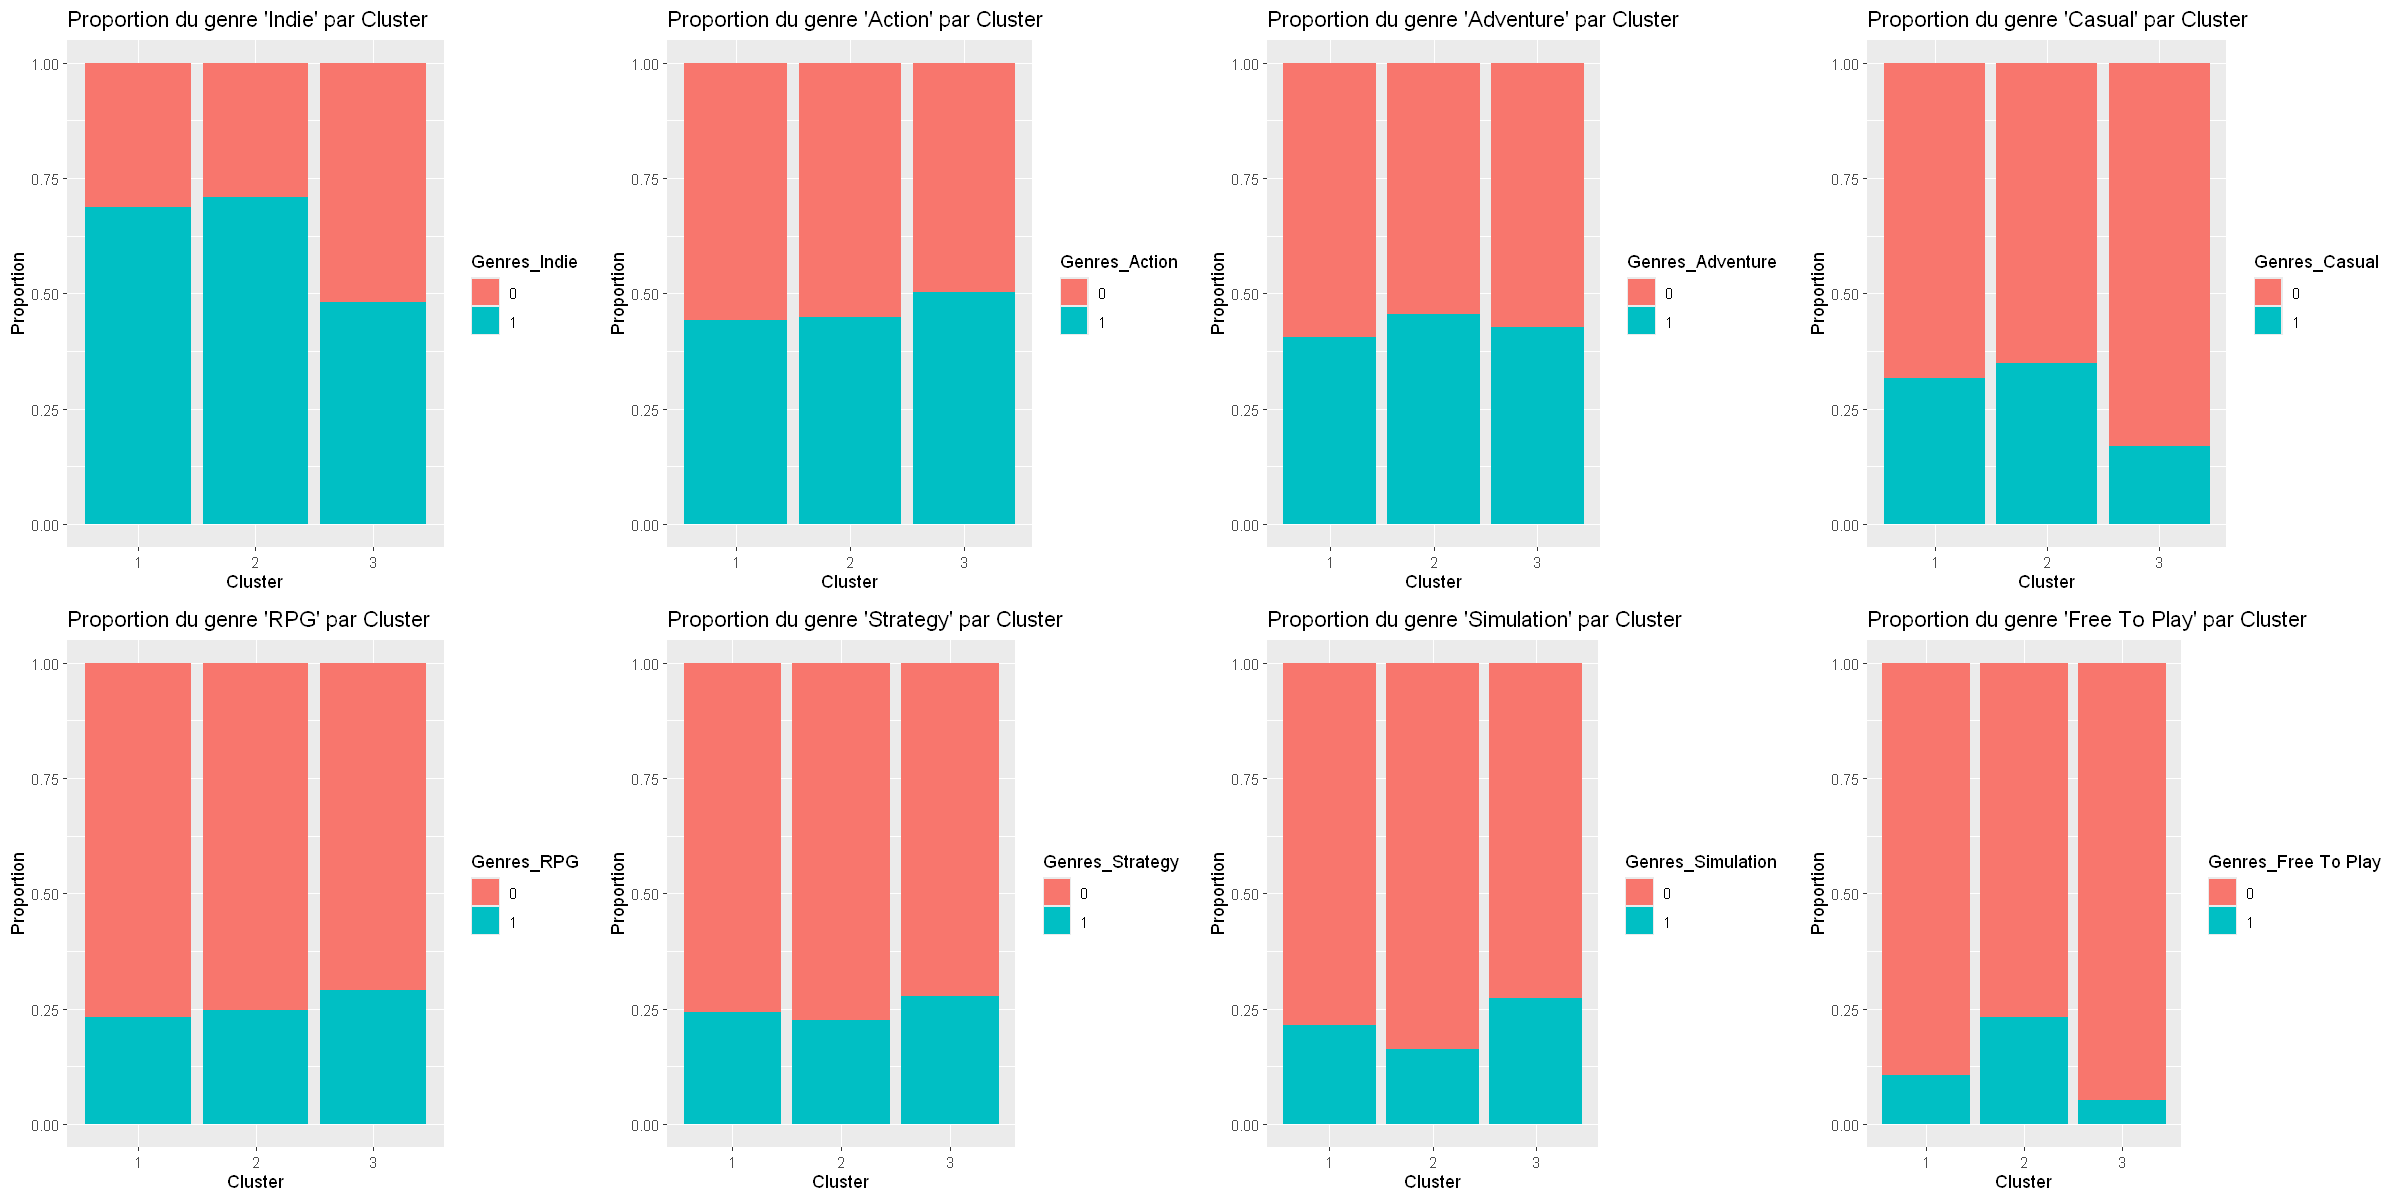

In [171]:
options(repr.plot.width = 20, repr.plot.height =10)
gg1=ggplot(data.pop_genres, aes(x = factor(cluster_id_3), fill = Genres_Indie)) +
  geom_bar(position = "fill") +
  labs(title = "Proportion du genre 'Indie' par Cluster", x = "Cluster", y = "Proportion") 
gg2 = ggplot(data.pop_genres, aes(x = factor(cluster_id_3), fill = Genres_Action)) +
  geom_bar(position = "fill") +
  labs(title = "Proportion du genre 'Action' par Cluster", x = "Cluster", y = "Proportion") 
gg3=ggplot(data.pop_genres, aes(x = factor(cluster_id_3), fill = Genres_Adventure)) +
  geom_bar(position = "fill") +
  labs(title = "Proportion du genre 'Adventure' par Cluster", x = "Cluster", y = "Proportion") 
gg4=ggplot(data.pop_genres, aes(x = factor(cluster_id_3), fill = Genres_Casual)) +
  geom_bar(position = "fill") +
  labs(title = "Proportion du genre 'Casual' par Cluster", x = "Cluster", y = "Proportion") 
gg5=ggplot(data.pop_genres, aes(x = factor(cluster_id_3), fill = Genres_RPG)) +
  geom_bar(position = "fill") +
  labs(title = "Proportion du genre 'RPG' par Cluster", x = "Cluster", y = "Proportion") 
gg6=ggplot(data.pop_genres, aes(x = factor(cluster_id_3), fill = Genres_Strategy)) +
  geom_bar(position = "fill") +
  labs(title = "Proportion du genre 'Strategy' par Cluster", x = "Cluster", y = "Proportion") 
gg7=ggplot(data.pop_genres, aes(x = factor(cluster_id_3), fill = Genres_Simulation)) +
  geom_bar(position = "fill") +
  labs(title = "Proportion du genre 'Simulation' par Cluster", x = "Cluster", y = "Proportion") 
gg8=ggplot(data.pop_genres, aes(x = factor(cluster_id_3), fill = `Genres_Free To Play`)) +
  geom_bar(position = "fill") +
  labs(title = "Proportion du genre 'Free To Play' par Cluster", x = "Cluster", y = "Proportion") 

grid.arrange(gg1,gg2,gg3,gg4,gg5,gg6,gg7,gg8,ncol=4)

Le genre Indie est beaucoup moins présent dans le Cluster 1 que dans les clusters 2 et 3. Sachant que ces jeux sont les jeux sont les jeux à succès c'est cohérent. De la même manière le genre Casual est moins présent dans le cluster 1 que les autres ("Les jeux "Casual" ont tendance à générer moins d'engagement massif (moins de playtime, moins de Peak CCU) que les jeux plus "Core", ce qui explique pourquoi ils sont sous-représentés dans l'élite du Cluster 1."). Il y a une part plus élevée de jeux gratuits dans le cluster 3 et beacoup moins dans le 1, c'est cohérent avec le profil moyen.

In [267]:
# D'après https://gamalytic.com/publisher-list , liste des publishers AAA:
publishers_aaa <- c("Valve", "Electronic Arts", "EA ", "Ubisoft", "Bandai Namco", 
                    "Capcom", "Xbox Game Studios", "Microsoft", "Bethesda", 
                    "2K", "SEGA", "Activision", "PlayStation Publishing", 
                    "Warner Bros", "Square Enix", "Rockstar Games", "KRAFTON, Inc")

data.pop$is_AAA <- ifelse(grepl(paste(publishers_aaa, collapse = "|"), 
                                data.pop$Publisher, ignore.case = TRUE), 1, 0)

data.pop$is_AAA <- as.factor(data.pop$is_AAA)

table(data.pop$is_AAA)


    0     1 
13086  1046 

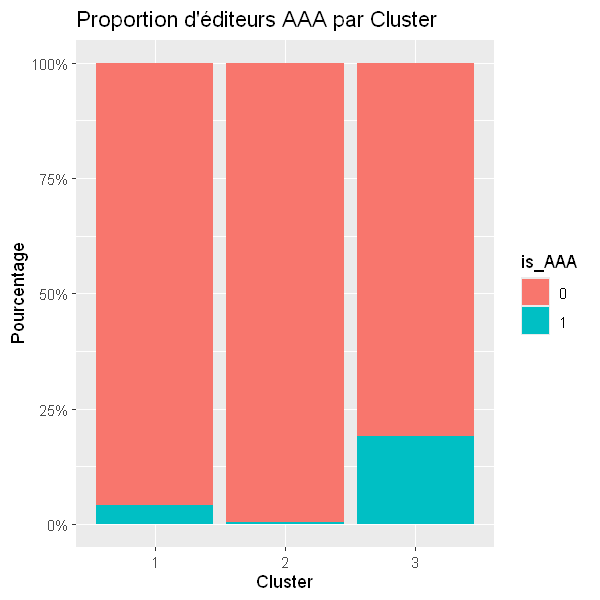

In [173]:
options(repr.plot.width = 5, repr.plot.height =5)
ggplot(data.pop, aes(x = factor(cluster_id_3), fill = is_AAA)) +
  geom_bar(position = "fill") +
  scale_y_continuous(labels = scales::percent) +
  labs(title = "Proportion d'éditeurs AAA par Cluster",
       x = "Cluster",
       y = "Pourcentage") 

### CAH

In [152]:
options(repr.plot.width = 5, repr.plot.height =5)

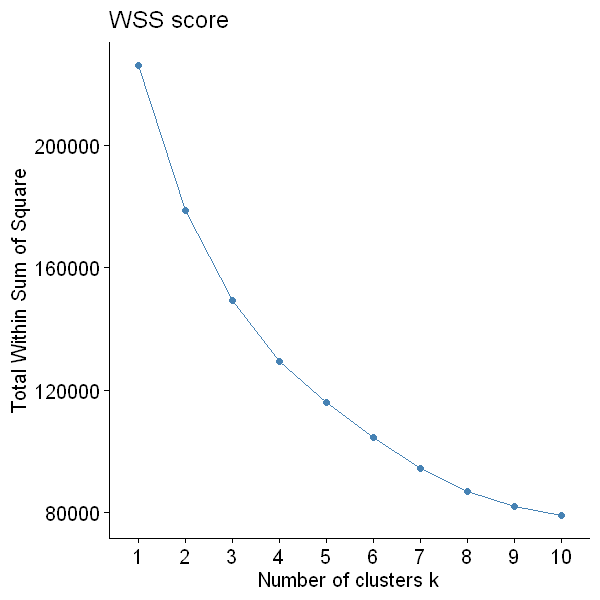

In [153]:
fviz_nbclust(data.pop.scale, FUNcluster=hcut, method="wss") + ggtitle("WSS score")

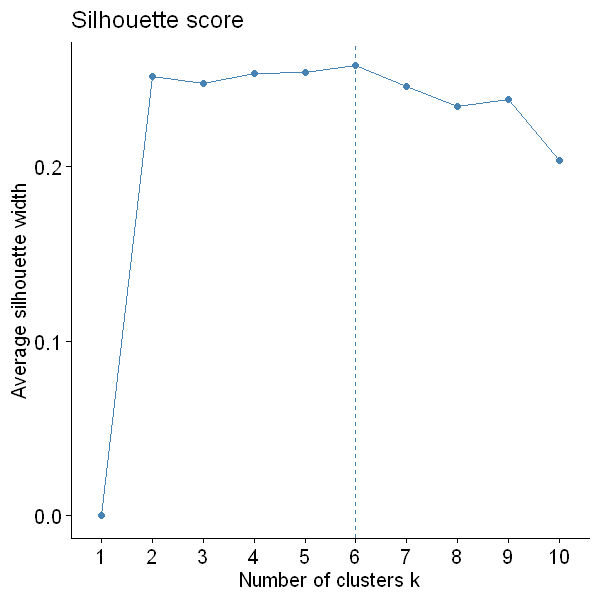

In [154]:
fviz_nbclust(data.pop.scale, FUNcluster=hcut, method="silhouette") + ggtitle("Silhouette score")

Le nb de cluster est différent qu'avec kmeans, le nb de cluster 6 maximise la silhouette mais le score reste proches des autres (4 et 5 surtout).

In [ ]:
On choisit la fonction lien Ward car elle fait des clusters de tailles égales, qui sont plutôt sphériques

In [186]:
#res.pca$ind$coord si on veut faire sur l'ACP
dist_pca <- dist(data.pop.scale, method = "euclidean")

# fonction lien Ward
hclust_ward <- hclust(dist_pca, method = "ward.D2")


In [196]:
clusters_cah3 <- cutree(hclust_ward, k = 3)
data.pop$cluster_cah3 <- factor(clusters_cah3)

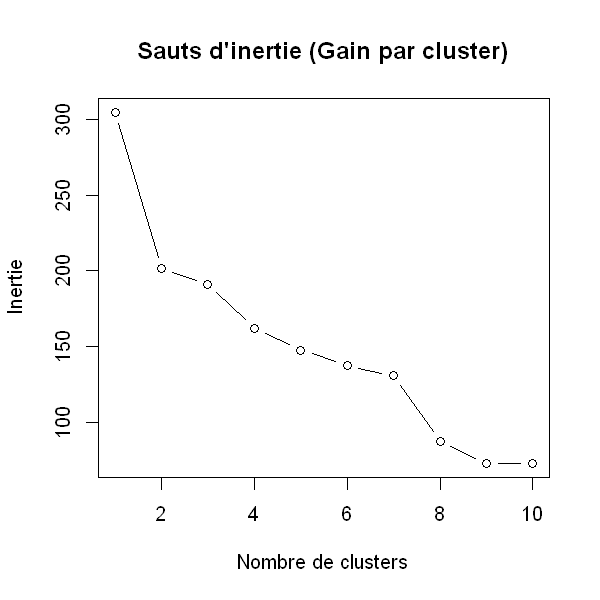

In [187]:
# Affiche les gains d'inertie (les "sauts" entre chaque palier de l'arbre)
# On regarde les 10 derniers sauts
plot(rev(hclust_ward$height)[1:10], type = "b", 
     main = "Sauts d'inertie (Gain par cluster)",
     xlab = "Nombre de clusters", ylab = "Inertie")

In [203]:
summary(data.pop$cluster_cah3)

1     2     3 
11314  2792    26

In [200]:
table(data.pop$cluster_id_3, data.pop$cluster_cah3)

   
       1    2    3
  1 7194   16    0
  2  265 2774    0
  3 3855    2   26

In [211]:
jeux_cluster3 <- data.pop[data.pop$cluster_cah3 == 3, ]
print(jeux_cluster3, )

                                          Name Release.date Estimated.owners
290                               APB Reloaded    1997-2013           5M-10M
997                                     Avem33         2017         50K-100K
1016                              Awesomenauts    1997-2013            2M-5M
1398                               Black Squad         2019          10M-20M
1400          BlackShot: Mercenary Warfare FPS         2016          500K-1M
1810  Café Stella and the Reaper's Butterflies         2022        100K-200K
2216                                   Closers         2018          500K-1M
2429                      Counter-Strike Nexon         2014           5M-10M
3708                                      Elin         2024          500K-1M
4286           Fish Idle 2: Underwater Mystery         2024        100K-200K
4392                          Forbidden Planet         2016        200K-500K
4565                                     GINKA         2023        100K-200K

**En choisissant K=6:**

In [204]:
clusters_cah6 <- cutree(hclust_ward, k = 6)
data.pop$cluster_cah6 <- factor(clusters_cah6)

In [206]:
summary(data.pop$cluster_cah6)

1    2    3    4    5    6 
7269   42 2792 3999   26    4

In [212]:
# Sélectionner le nom et les variables principales
jeux_cluster6 <- data.pop[data.pop$cluster_cah6 == 6, ]
print(jeux_cluster6, )

                                       Name Release.date Estimated.owners
538                                 Alganon         2015        100K-200K
670   Ancestors Legacy Free Peasant Edition         2018        100K-200K
1578                            Booty Calls         2018        100K-200K
13510                                 Wwbit         2018        100K-200K
      Required.age Discount Windows   Mac Linux Metacritic.score User.score
538              0        0    True False False                0         37
670             17        0    True False False                0         77
1578             0        0    True  True False                0         46
13510            0        0    True False False                0         55
      Achievements Average.playtime.two.weeks Median.playtime.two.weeks
538              0                          0                         0
670              0                          0                         0
1578            30                

### GMM

On utilise le GMM sur les composantes principales de l'ACP. On choisit de retenir 7 composantes (qui expliquent 82% de la variance).

In [214]:
#On utilise le critère BIC pour déterminer le meilleur modèle et le nombre de cluster optimal
resBIC = mclustBIC(pca.pop$ind$coord[,1:7], G=1:10)
summary(resBIC)

resBIC = Mclust(pca.pop$ind$coord[,1:7], G=1:10)

Best BIC values:
            VEV,10      VEV,9      VEV,8
BIC      -37631.04 -43886.693 -45317.913
BIC diff      0.00  -6255.651  -7686.872

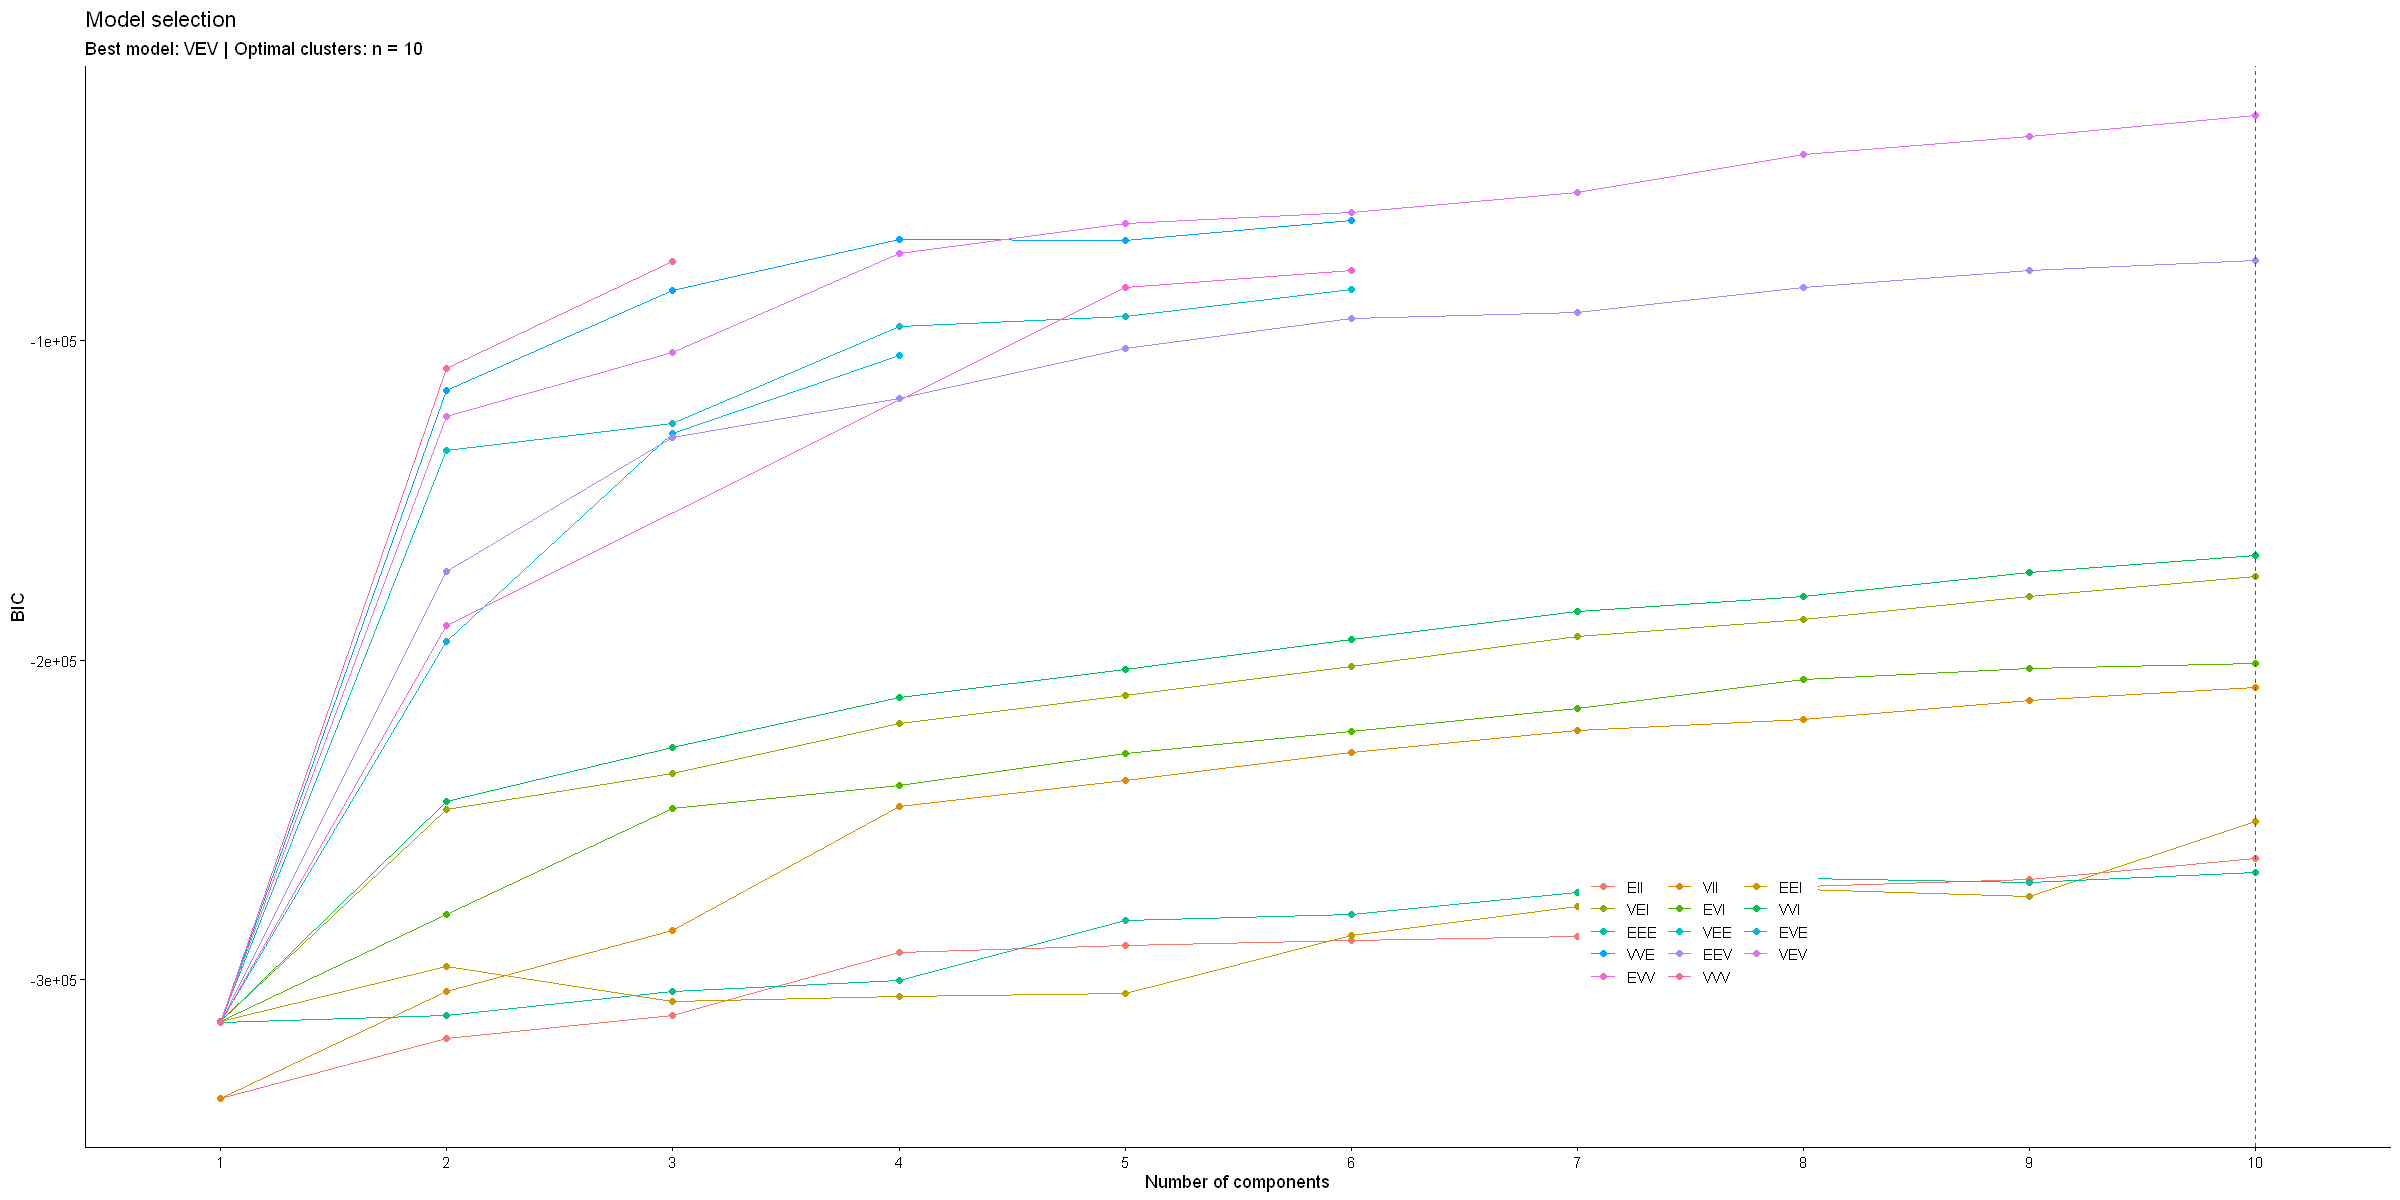

In [216]:
options(repr.plot.width = 20, repr.plot.height =10)
fviz_mclust(resBIC, what="BIC")

In [225]:
options(repr.plot.width = 15, repr.plot.height = 6)

K = 10
gmm = Mclust(pca.pop$ind$coord[,1:7], G=K, modelNames = "VEV")
p1 = fviz_cluster(gmm, data=pca.pop$ind$coord[,1:7], ellipse.type="norm", geom="point")


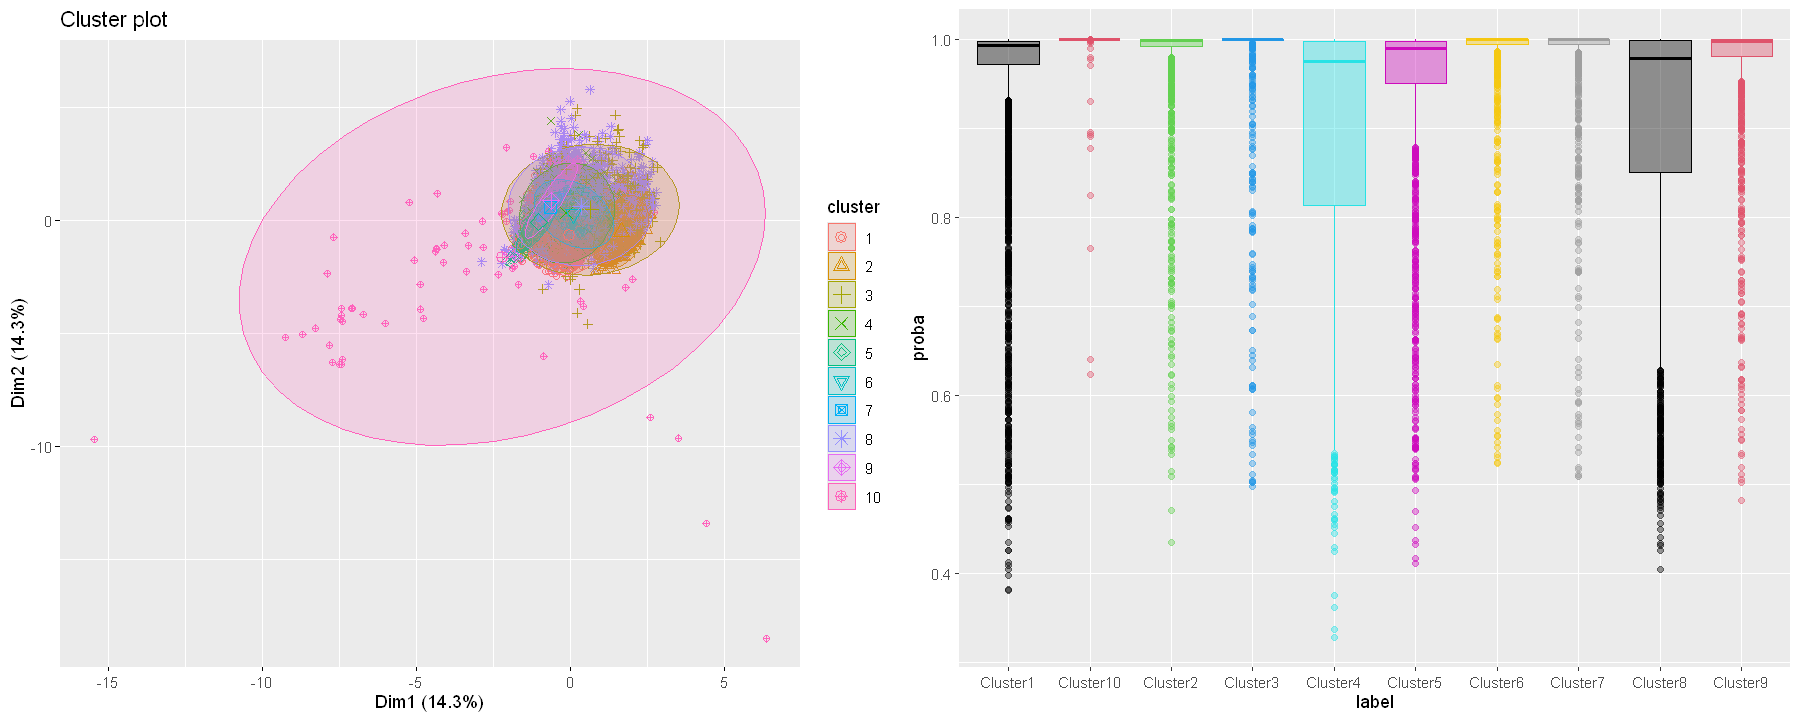

In [226]:
aux = data.frame(
    label = paste("Cluster", gmm$classification, sep=""), 
    proba = apply(gmm$z, 1, max))

p2 = ggplot(aux, aes(x=label, y=proba)) + 
    geom_boxplot(colour=1:K, fill=1:K, alpha=.4)

grid.arrange(p1,p2,ncol=2)

Le graphique des probabilités d'appartenance aux clusters valide le choix du modèle GMM à 10 classes. On observe que la majorité des clusters (notamment les clusters 1, 7 et 10) présentent des probabilités d'assignation proches de 1, témoignant d'une forte certitude du modèle. À l'inverse, les clusters 4 et 8 affichent des boîtes à moustaches plus étirées vers le bas, révélant l'existence de jeux situés aux frontières de plusieurs profils.

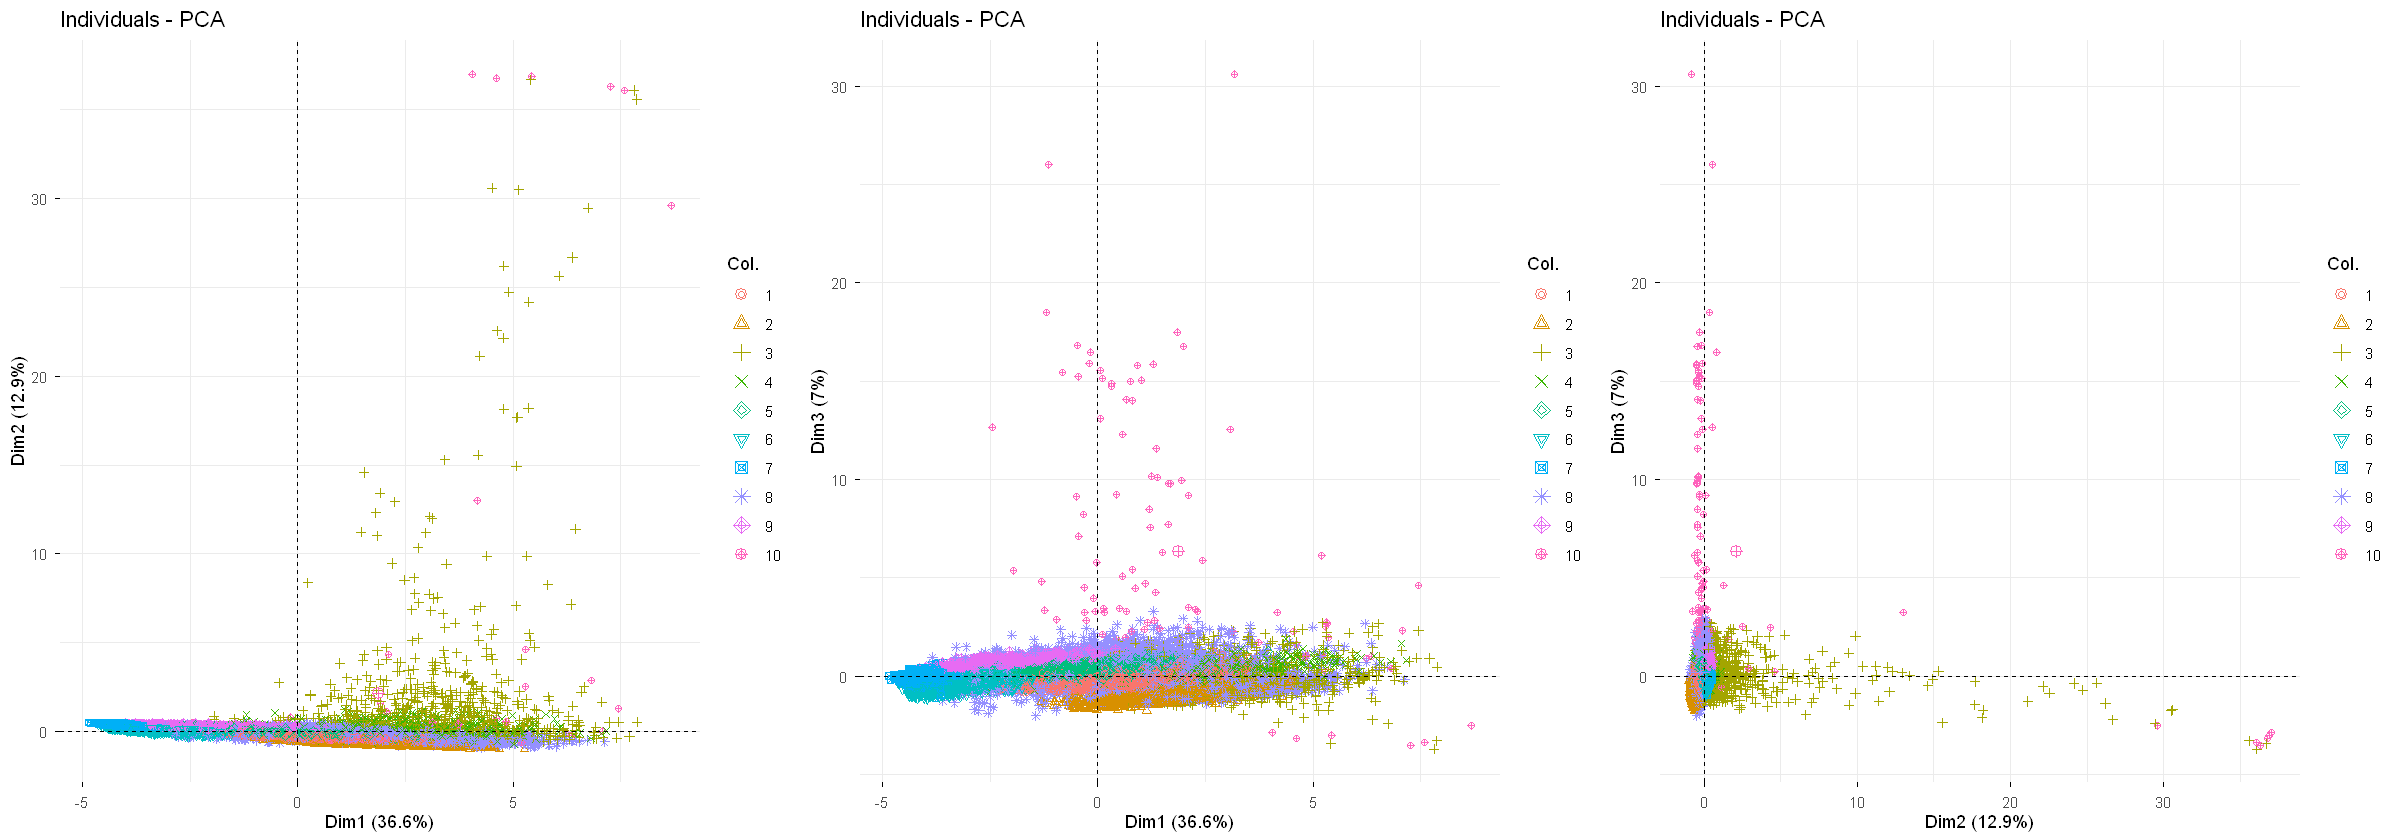

In [229]:
options(repr.plot.width = 20, repr.plot.height = 7)

grid.arrange(
    fviz_pca_ind(pca.pop, axes=c(1,2), geom = c("point"), col.ind=as.factor(gmm$classification)),
    fviz_pca_ind(pca.pop, axes=c(1,3), geom=c("point"), col.ind=as.factor(gmm$classification)),
    fviz_pca_ind(pca.pop, axes=c(2,3), geom=c("point"), col.ind=as.factor(gmm$classification)),
    ncol=3)

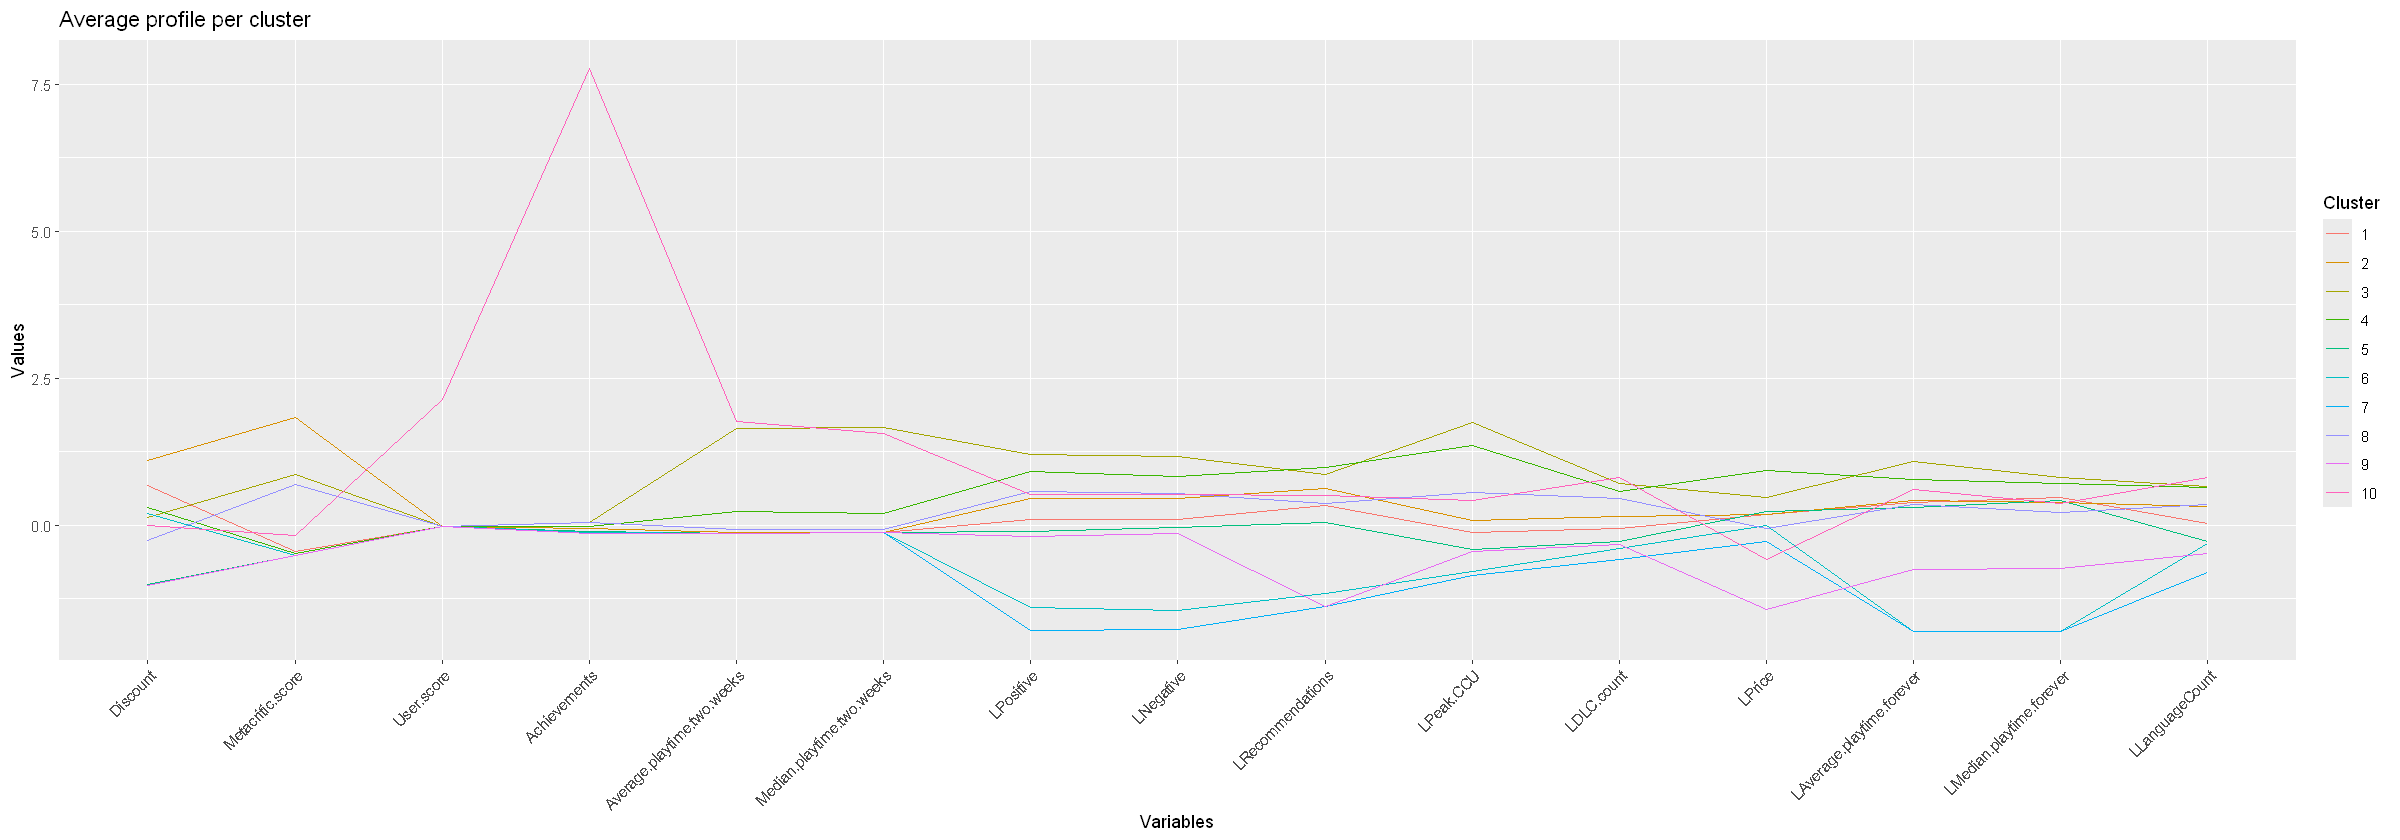

In [233]:
#Averages profiles

mean_profiles_gmm = aggregate(data.pop.scale, by = list(cluster = gmm$classification), FUN = mean)
mean_profiles_gmm = melt(mean_profiles_gmm, id.vars = "cluster")

ggplot(mean_profiles_gmm, aes(x = variable, y = value, color = factor(cluster), group = cluster)) +
  geom_line() +  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  labs(title = "Average profile per cluster", x = "Variables", y = "Values") +
  scale_color_discrete(name = "Cluster")

L'analyse des profils moyens permet d'en savoir plus sur les clusters. Le modèle isole des comportements spécifiques avec 3 clusters : le Cluster 9 se distingue uniquement par un volume massif d'achievements, tandis que les Clusters 3 et 4 regroupent sûrement les plus populaires avec des scores de popularité et d'engagement et de temps de jeux(LPeak.CCU, LPositive, LAverage.playtimr.forever,two.weeks pour cluster 3) largement supérieurs à la moyenne. Enfin, les Clusters 6 et 7 se caractérisent par un temps de jeu et des recommandations très faibles, marquant probablement les produits de niche du catalogue (public ciblé) avec aussi moins de langues disponibles que la moyenne.

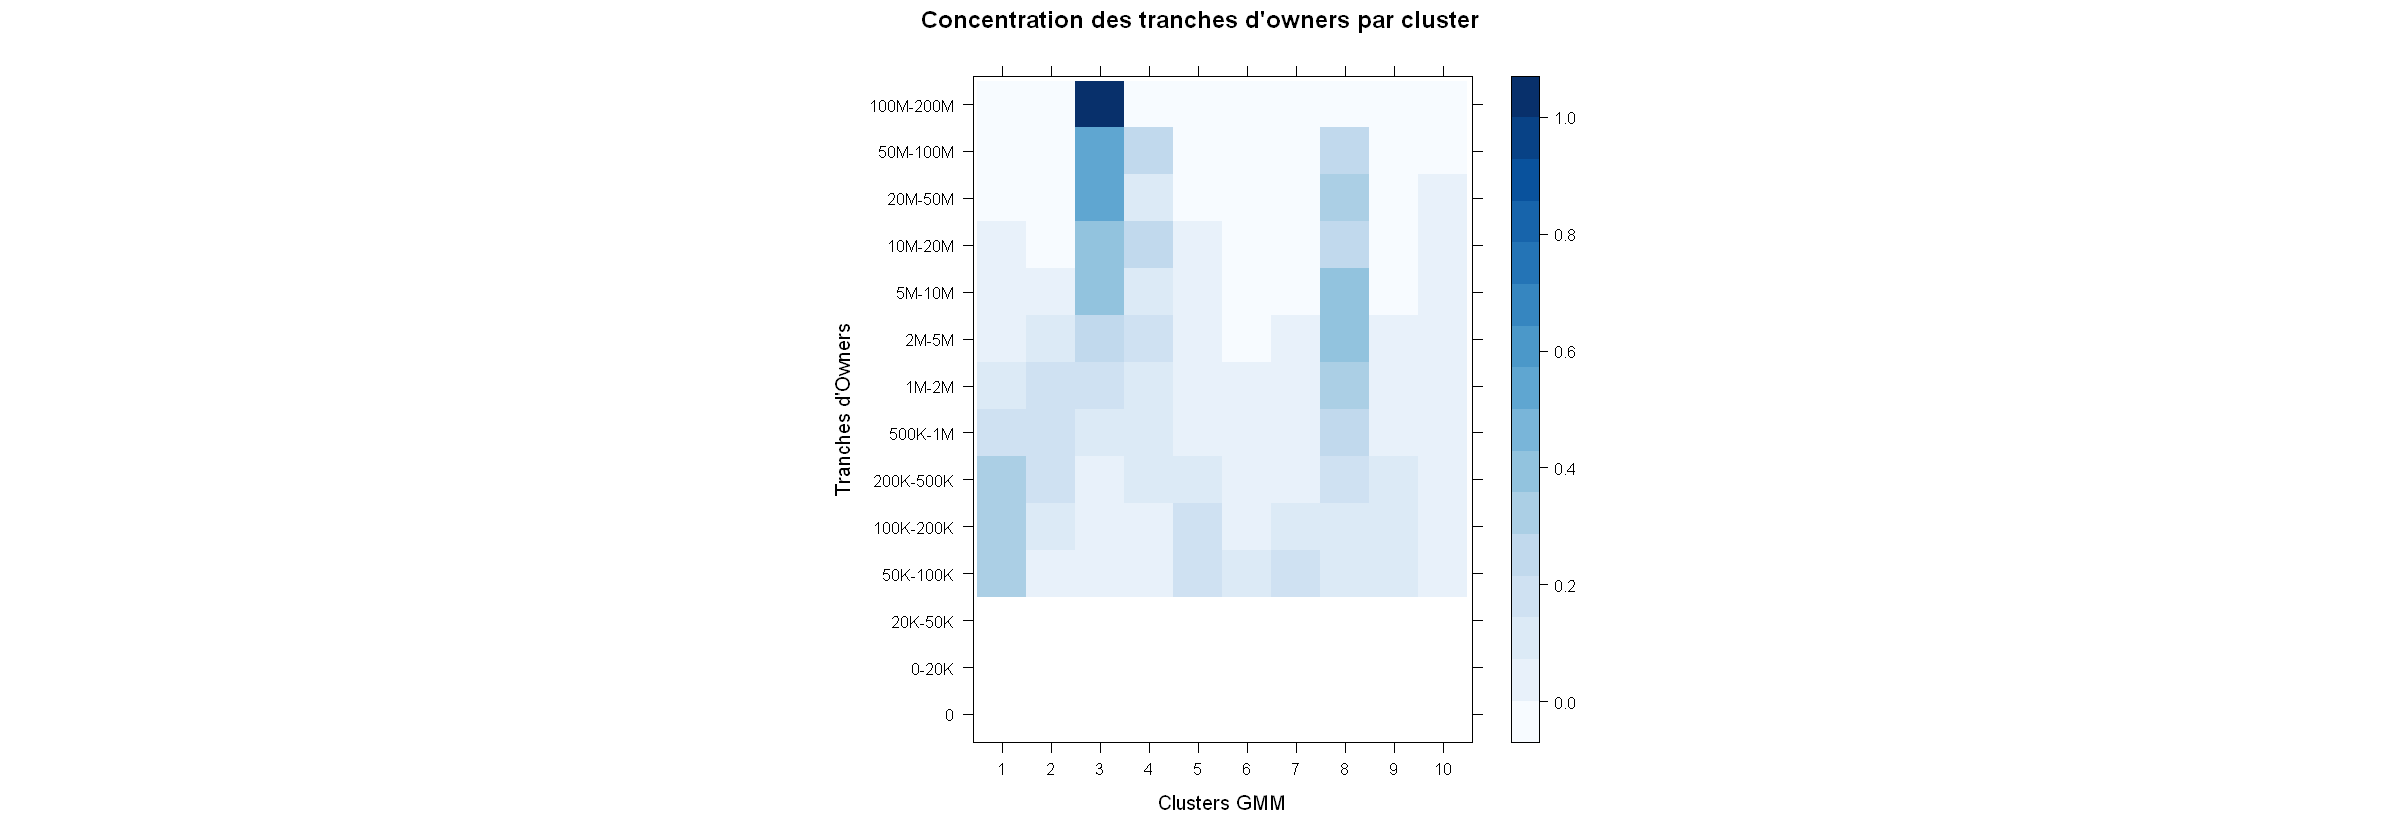

In [255]:
library(lattice)
library(RColorBrewer)

tab_prop <- prop.table(table(data.pop$cluster_gmm, data.pop$Estimated.owners),margin = 2)

coul <- colorRampPalette(brewer.pal(9, "Blues"))(100)

levelplot(tab_prop, 
          col.regions = coul, 
          main = "Concentration des tranches d'owners par cluster",
          xlab = "Clusters GMM", 
          ylab = "Tranches d'Owners")

L'analyse de la concentration des tranches d'utilisateurs par cluster confirme la pertinence de la segmentation issue du modèle GMM dans le cadre de l'étude de popularité. Le Cluster 3 capte l'intégralité des jeux au succès phénoménal (tranche 100M-200M) et la grande majorité des titres au-delà de 20 millions d'utilisateurs. Il incarne ainsi le segment des jeux à très grand succès.

À l'opposé, les Clusters 1 et 5 se concentrent sur les tranches de succès modeste (50K à 500K). Le Cluster 8 se distingue comme un segment intermédiaire solide, captant une part significative des jeux entre 2 et 10 millions d'owners. Cette visualisation prouve que les variables que le GMM utilise sont des indicateurs/conséquences du le volume de ventes (Owners) et structurent de la répartition des jeux sur la plateforme.

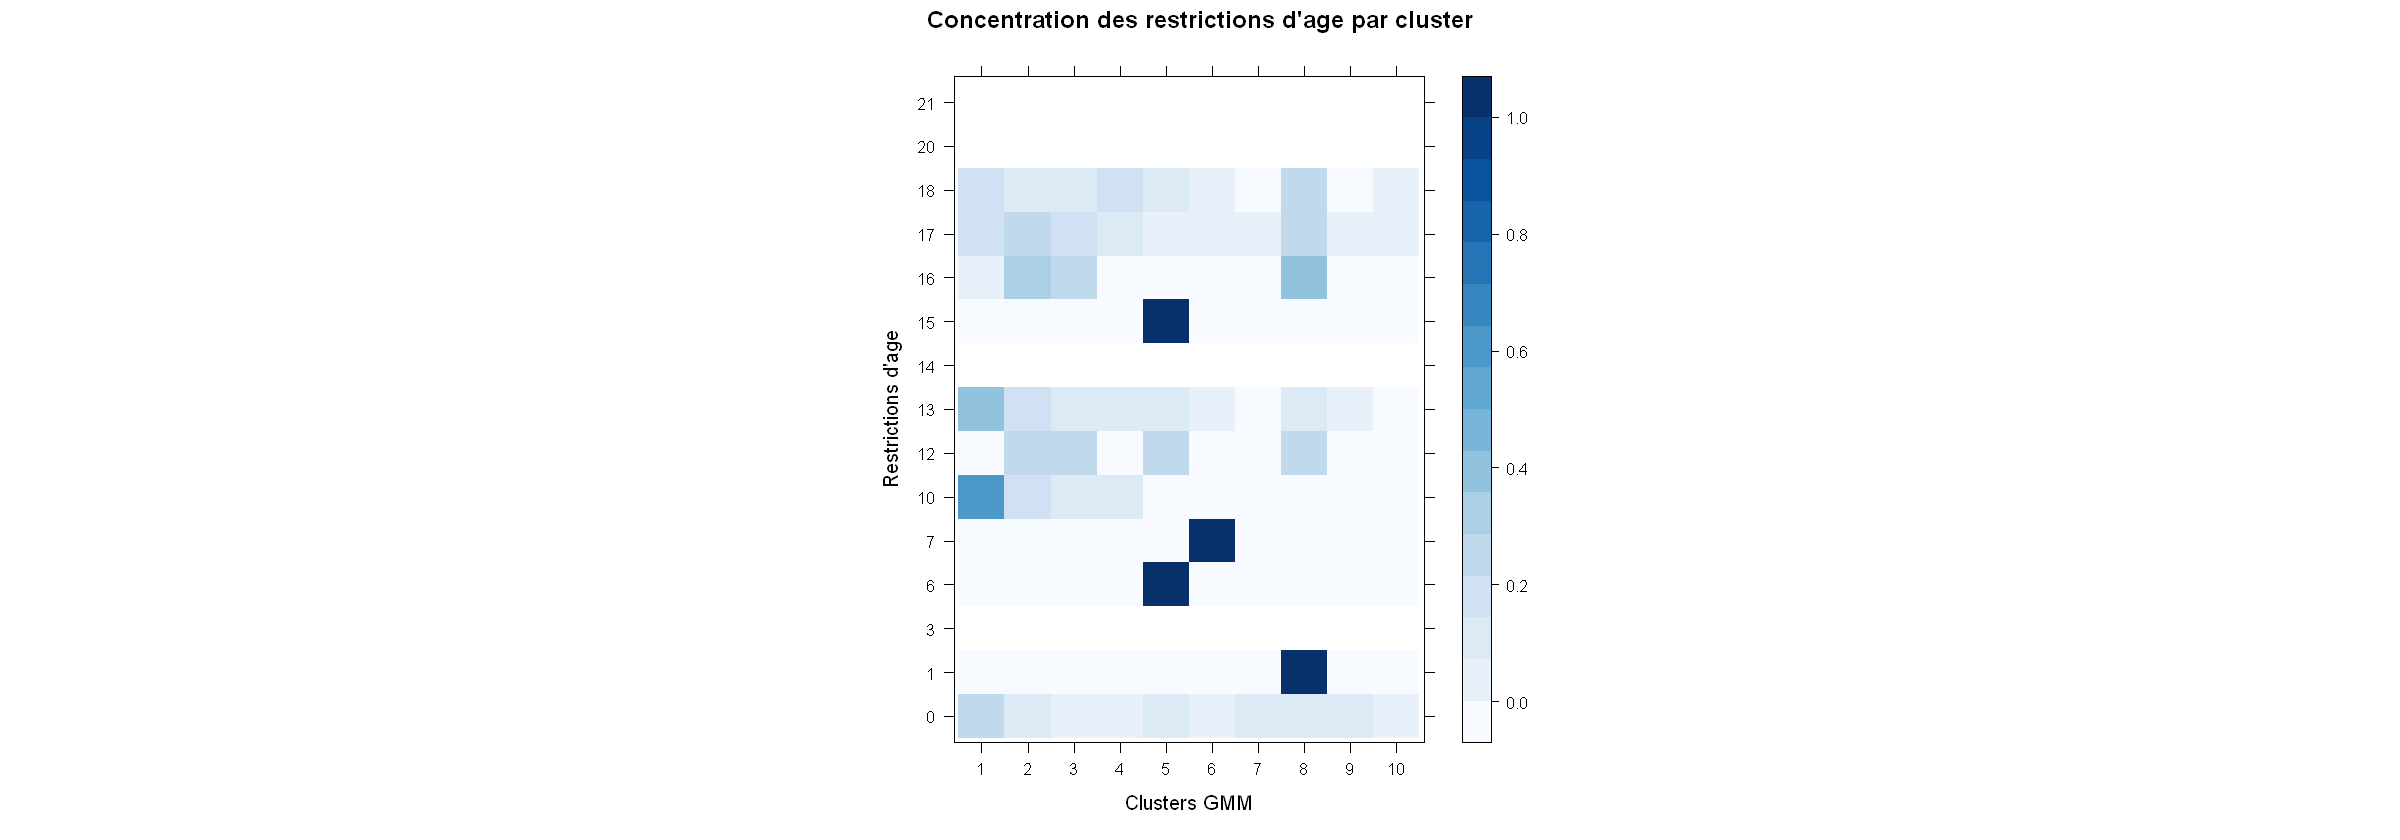

In [258]:
tab_prop_age <- prop.table(table(data.pop$cluster_gmm, data.pop$Required.age), margin = 2)

coul <- colorRampPalette(brewer.pal(9, "Blues"))(100)

levelplot(tab_prop_age, 
          col.regions = coul, 
          main = "Concentration des restrictions d'age par cluster",
          xlab = "Clusters GMM", 
          ylab = "Restrictions d'age")

Ces clusters (5, 6, 8) ne se définissent pas par leur succès (le nombre de ventes), mais par leur origine géographique ou leur public cible. Par exemple, un cluster qui ne contient que des jeux notés "15" est probablement composé de jeux qui ont dû passer par une certification spécifique (souvent des jeux japonais ou allemands).

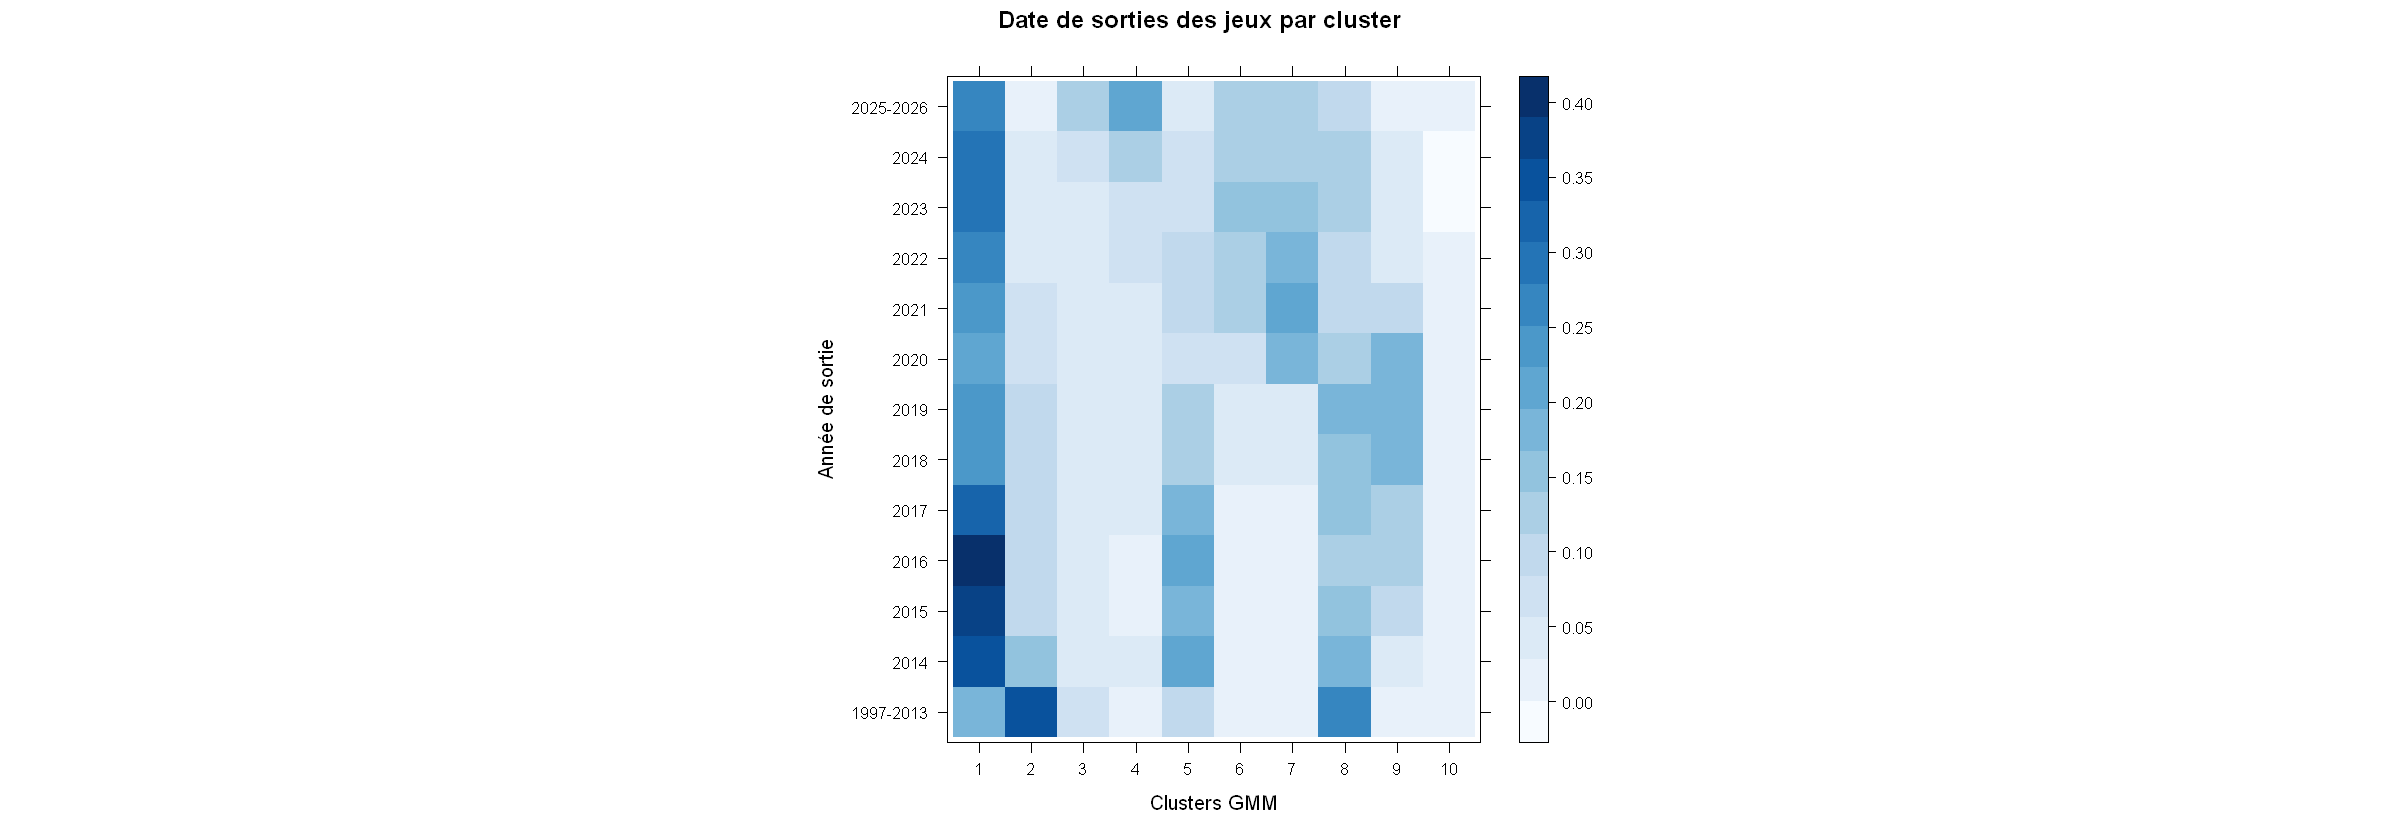

In [259]:
ma_table <- table(data.pop$cluster_gmm, data.pop$Release.date)

tab_prop_date <- prop.table(ma_table, margin = 2)

coul <- colorRampPalette(brewer.pal(9, "Blues"))(100)

levelplot(tab_prop_date, 
          col.regions = coul, 
          main = "Date de sorties des jeux par cluster",
          xlab = "Clusters GMM", 
          ylab = "Année de sortie")

L'analyse de la concentration par date de sortie montre une répartition plus hétérogène que celle des volumes de ventes. On note toutefois que le Cluster 2 possède une identité historique marquée, captant une part prépondérante des titres sortis entre 1997 et 2013. À l'inverse, la faible coloration des clusters "Elite" (3 et 10) à travers toutes les époques souligne que l'accès au succès massif reste un phénomène rare et indépendant de l'ancienneté du titre sur la plateforme.

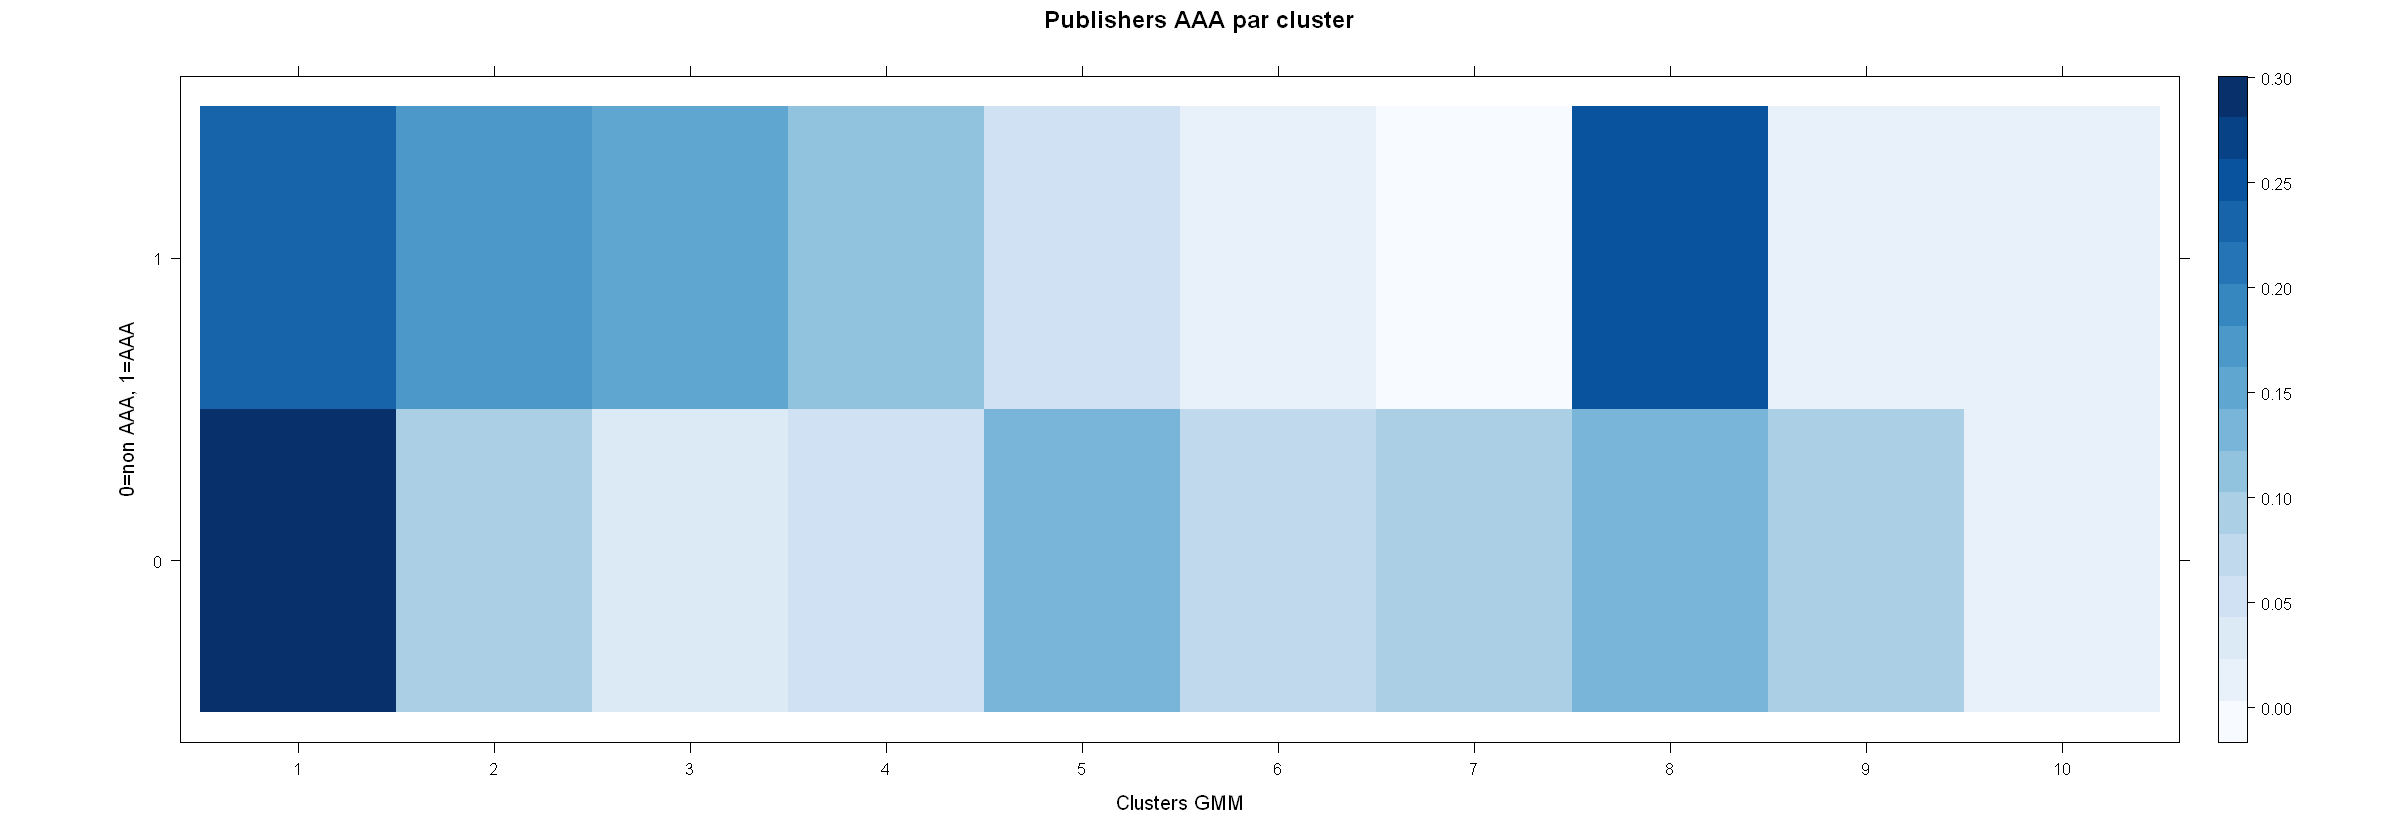

In [273]:
tab_prop_age <- prop.table(table(data.pop$cluster_gmm, data.pop$is_AAA), margin = 2)

coul <- colorRampPalette(brewer.pal(9, "Blues"))(100)

levelplot(tab_prop_age, 
          col.regions = coul, 
          main = "Publishers AAA par cluster",
          xlab = "Clusters GMM", 
          ylab = "0=non AAA, 1=AAA")

On remarque le cluster 3 avec les jeux au méga succès n'as pas la plus grosse part des jeux avec publishers AAA

## MCA

In [310]:
data.pop.quali = data.pop_genres %>% select(where(is.factor))

In [320]:
summary(data.pop.quali)

    Release.date   Estimated.owners  Required.age    Windows         Mac      
 1997-2013:1424   50K-100K :5349    0      :13369   False:    2   False:9978  
 2016     :1361   100K-200K:3450    17     :  580   True :14130   True :4154  
 2021     :1293   200K-500K:2845    13     :   95                             
 2020     :1284   500K-1M  :1150    18     :   49                             
 2017     :1149   1M-2M    : 720    16     :   21                             
 2023     :1149   2M-5M    : 400    10     :   10                             
 (Other)  :6472   (Other)  : 218    (Other):    8                             
   Linux       Genres_Action Genres_Adventure Genres_Casual Genres_Indie
 False:11307   0:7619        0:8166           0:10140       0:5162      
 True : 2825   1:6513        1:5966           1: 3992       1:8970      
                                                                        
                                                                        
   

In [318]:
data.pop.quali=data.pop.quali %>% select(-c("cluster_id_3","is_AAA","cluster_cah3","cluster_cah6","cluster_gmm"))

**Results of the Multiple Correspondence Analysis (MCA)**
The analysis was performed on 14132 individuals, described by 22 variables
*The results are available in the following objects:

   name              description                       
1  "$eig"            "eigenvalues"                     
2  "$var"            "results for the variables"       
3  "$var$coord"      "coord. of the categories"        
4  "$var$cos2"       "cos2 for the categories"         
5  "$var$contrib"    "contributions of the categories" 
6  "$var$v.test"     "v-test for the categories"       
7  "$var$eta2"       "coord. of variables"             
8  "$ind"            "results for the individuals"     
9  "$ind$coord"      "coord. for the individuals"      
10 "$ind$cos2"       "cos2 for the individuals"        
11 "$ind$contrib"    "contributions of the individuals"
12 "$call"           "intermediate results"            
13 "$call$marge.col" "weights of columns"              
14 "$call$marge.li"  "weights

Warning message in geom_bar(stat = "identity", fill = barfill, color = barcolor, :
"Ignoring empty aesthetic: `width`."


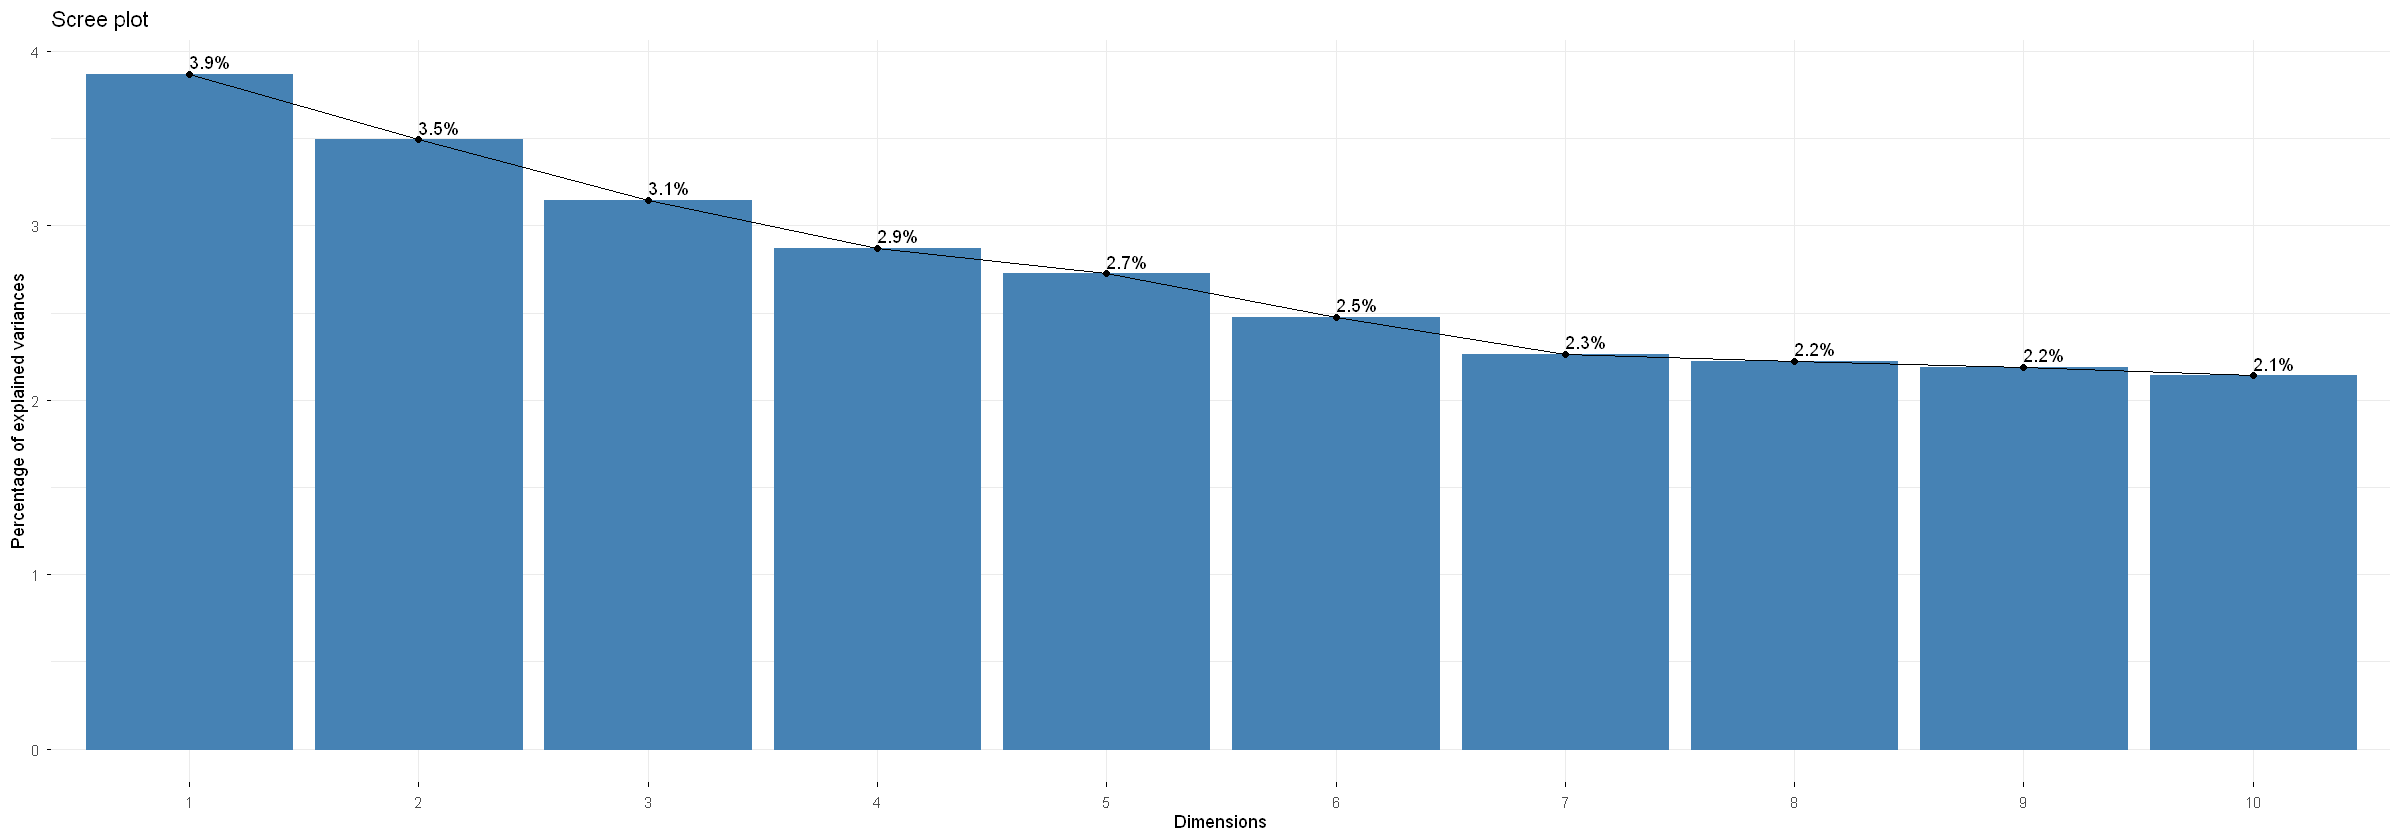

In [319]:
mca.pop=MCA(data.pop.quali, graph = FALSE)
print(mca.pop)
fviz_screeplot(mca.pop, addlabels=TRUE)